# Chronological Cost-Calibrated Evaluation (C3E) — Master Reproducibility Notebook

**Paper:** *Chronological Cost-Calibrated Evaluation for Fraud Detection: A Threshold-Transferability Perspective on the ROC–PR Divergence*
**Authors:** Elbadraoui et al.

This single notebook regenerates **every result table and figure** in the manuscript from the
original source scripts. It is organised as an orchestrator: the verified implementations live in
the four `c3e_*.py` modules, and this notebook drives them, collects their outputs, and renders
publication-quality figures.

| Section | Produces | Source module |
|---|---|---|
| 1. Setup & config | paths, seed, style | — |
| 2. Datasets D1–D4 (5 models) | `c3e_ALL_6datasets.csv` rows | `c3e_framework.py` |
| 3. Datasets D5–D6 (Elliptic, GiveMe) | `c3e_d5_d6.csv` | `c3e_datasets_d5_d6.py` |
| 4. Calibration × cost regimes (creditcard) | `c3e_contribution3_creditcard.csv` | `c3e_contribution3.py` |
| 5. NLP augmentation (negative result) | `c3e_nlp_*.csv` | `c3e_contribution4_nlp.py` |
| 6. Statistical tests | Friedman / Wilcoxon | `c3e_datasets_d5_d6.py` |
| 7. Figures (Q1 style) | all `fig*.pdf/png` | this notebook (reads CSVs) |
| 8. LaTeX tables | `table_*.tex` | `c3e_framework.py` |

> **Reproducibility note.** Results are reported over **five random seeds**
> `{7, 21, 42, 84, 168}` and aggregated as mean ± standard deviation (Section 2b),
> matching the multi-seed practice expected by the target journal. A single-seed
> path (seed 42, Sections 2–3) is also available for quick runs. Results are
> deterministic given identical library versions (see Section 1.3). If a regenerated
> number differs from the manuscript table, it indicates library drift and should be
> reconciled before submission — the notebook prints a comparison in Section 9.


## 1. Setup

### 1.1 — Imports and reproducibility seed

In [1]:
import os, sys, warnings, json, time, platform
from pathlib import Path
warnings.filterwarnings("ignore")
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"
os.environ["PYTHONHASHSEED"] = "42"

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl

SEED = 42
np.random.seed(SEED)

print(f"Python : {platform.python_version()}")
print(f"NumPy  : {np.__version__}")
print(f"Pandas : {pd.__version__}")
print(f"Seed   : {SEED}")

Python : 3.11.0
NumPy  : 1.26.4
Pandas : 2.2.2
Seed   : 42


### 1.2 — Paths and **non-destructive output** (EDIT FOR YOUR MACHINE)

Everything machine-specific is centralised here. The dataset paths default to the
`D:\fraud_data\...` layout from the original scripts; change them only if your data moved.
`CODE_DIR` must point to the folder with the four `c3e_*.py` files.

**Results are never overwritten.** Each execution writes into its own **timestamped run folder**
(`runs/run_YYYY-MM-DD_HHMMSS/`). Your previously recovered CSVs stay untouched. Drop those
verified originals into `originals/` and Section 9 will compare each new run against them
(read-only) — so a stray *Run All* can never destroy a good result.

In [2]:
from datetime import datetime

# --- where the four c3e_*.py modules live ---
CODE_DIR = Path(r"C:\Users\LENOVO\Desktop\C3E_backup_2026-06-16_2127\code")  # <-- EDIT

# --- NON-DESTRUCTIVE OUTPUT: every run gets its own timestamped folder ---
RUN_STAMP = datetime.now().strftime("%Y-%m-%d_%H%M%S")
RUN_DIR   = Path("runs") / f"run_{RUN_STAMP}"
RESULTS_DIR = RUN_DIR / "results"; RESULTS_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR = RUN_DIR / "figures"; FIGURES_DIR.mkdir(parents=True, exist_ok=True)
TABLES_DIR  = RUN_DIR / "tables";  TABLES_DIR.mkdir(parents=True, exist_ok=True)

# --- FROZEN originals: your recovered CSVs, read-only, never written to ---
ORIGINALS_DIR = Path("originals")          # put c3e_ALL_6datasets.csv etc. here
ORIGINALS_DIR.mkdir(exist_ok=True)

# Safety guard: refuse to ever write into the originals folder
def safe_out(path: Path) -> Path:
    p = Path(path).resolve()
    if ORIGINALS_DIR.resolve() in p.parents or p == ORIGINALS_DIR.resolve():
        raise RuntimeError(f"BLOCKED: attempt to write into frozen originals/: {p}")
    return p

# --- raw dataset files (EDIT to match your machine) ---
PATHS = {
    "creditcard":        r"D:\fraud_data\creditcard.csv",
    "ieee_cis":          r"D:\fraud_data\IEEE_CIS\train_transaction.csv",
    "baf":               r"D:\fraud_data\BAF NeurIPS 2022\Base.csv",
    "paysim":            r"D:\fraud_data\PaySim.csv",
    "elliptic_features": r"D:\fraud_data\elliptic_bitcoin_dataset\elliptic_txs_features.csv",
    "elliptic_classes":  r"D:\fraud_data\elliptic_bitcoin_dataset\elliptic_txs_classes.csv",
    "giveme_train":      r"D:\fraud_data\Give Me Some Credit\cs-training.csv",
}

# Cost regime (matches manuscript)
CFN, CFP = 10.0, 1.0
DELTA_THRESH = 0.20

# Multi-seed protocol (matches the published-journal practice)
SEEDS = [7, 21, 42, 84, 168]

sys.path.insert(0, str(CODE_DIR))
print(f"Run folder : {RUN_DIR.resolve()}")
print(f"Originals  : {ORIGINALS_DIR.resolve()} (read-only)")
print("CODE_DIR   :", CODE_DIR, "| exists:", CODE_DIR.exists())
for f in ["c3e_framework.py","c3e_contribution3.py",
          "c3e_contribution4_nlp.py","c3e_datasets_d5_d6.py"]:
    print(f"  {'OK ' if (CODE_DIR/f).exists() else 'MISSING'}  {f}")

Run folder : C:\Users\LENOVO\runs\run_2026-06-17_015602
Originals  : C:\Users\LENOVO\originals (read-only)
CODE_DIR   : C:\Users\LENOVO\Desktop\C3E_backup_2026-06-16_2127\code | exists: True
  OK   c3e_framework.py
  OK   c3e_contribution3.py
  OK   c3e_contribution4_nlp.py
  OK   c3e_datasets_d5_d6.py


### 1.3 — Publication figure style (Q1 / Springer)

A single, consistent visual identity for every figure: serif font matching the manuscript body,
restrained colour palette, vector PDF output at 300 dpi.

In [3]:
mpl.rcParams.update({
    "figure.dpi":        110,
    "savefig.dpi":       300,
    "savefig.bbox":      "tight",
    "font.family":       "serif",
    "font.serif":        ["Times New Roman", "DejaVu Serif"],
    "font.size":         10,
    "axes.titlesize":    11,
    "axes.labelsize":    10,
    "axes.spines.top":   False,
    "axes.spines.right": False,
    "axes.grid":         True,
    "grid.alpha":        0.25,
    "grid.linewidth":    0.5,
    "legend.frameon":    False,
    "legend.fontsize":   9,
    "lines.linewidth":   1.6,
})
# Colour-blind-safe palette (Wong 2011)
PALETTE = {"LR":"#0072B2","RF":"#E69F00","XGB":"#009E73","LGBM":"#CC79A7",
           "DNN":"#D55E00","CatBoost":"#56B4E9","TabNet":"#F0E442",
           "IF-Hybrid":"#999999","NODE":"#000000"}
def fig_path(name): return FIGURES_DIR / name
print("Figure style set. Palette:", list(PALETTE)[:5], "...")

Figure style set. Palette: ['LR', 'RF', 'XGB', 'LGBM', 'DNN'] ...


### 1.4 — Optional heavy dependencies

The source scripts import `catboost` at module level and use `gensim` (fastText), `torch` +
`pytorch-tabnet` (TabNet) where available. The cell below installs the ones you're missing.
TabNet/NODE fall back gracefully if absent, so only `catboost` is strictly required for Section 4.

In [4]:
import importlib
def ensure(pkg, pip_name=None):
    try: importlib.import_module(pkg); return True
    except ImportError:
        name = pip_name or pkg
        print(f"Installing {name} ...")
        import subprocess
        subprocess.run([sys.executable,"-m","pip","install","-q",name], check=False)
        try: importlib.import_module(pkg); return True
        except ImportError: print(f"  (could not import {pkg} — its section will fall back/skip)"); return False

ensure("catboost")                       # required for Section 4 & D5/D6 CatBoost
ensure("scipy"); ensure("sklearn","scikit-learn")
ensure("xgboost"); ensure("lightgbm")
ensure("gensim")                         # fastText for NLP (Section 5)
# Optional — TabNet (Section 4 will skip if missing):
# ensure("pytorch_tabnet","pytorch-tabnet"); ensure("torch")
print("Dependency check complete.")

Installing gensim ...
Dependency check complete.


### 1.5 — Import the source modules

These are your verified implementations. Importing (not copying) guarantees the notebook and the
scripts can never silently diverge.

In [5]:
import c3e_framework as cf
import c3e_datasets_d5_d6 as d56
import c3e_contribution3 as c3
import c3e_contribution4_nlp as c4

# Point the framework's dataset registry at YOUR paths
cf.DATASET_REGISTRY["creditcard"].path = PATHS["creditcard"]
cf.DATASET_REGISTRY["ieee_cis"].path   = PATHS["ieee_cis"]
cf.DATASET_REGISTRY["baf"].path        = PATHS["baf"]
cf.DATASET_REGISTRY["paysim"].path     = PATHS["paysim"]
print("Modules imported and dataset paths patched.")

Modules imported and dataset paths patched.


## 2. Datasets D1–D4 — five-model benchmark

Runs Logistic Regression, Random Forest, XGBoost, LightGBM, and the DNN across the four
transaction datasets under the C3E protocol (chronological split → leakage-free preprocessing →
recalibrate-before-threshold → validation-selected, test-frozen threshold).

**Runtime:** heavy. IEEE-CIS and PaySim are large; expect 20–60 min total on a laptop.
Set `MODELS_D14` to a subset (e.g. `["LR","XGB"]`) for a quick smoke test.

In [6]:
MODELS_D14    = ["LR","RF","XGB","LGBM","DNN"]   # full set as in paper
DATASETS_D14  = ["creditcard","ieee_cis","baf","paysim"]

df_d14 = cf.run_experiment(
    dataset_ids = DATASETS_D14,
    model_ids   = MODELS_D14,
    cfn = CFN, cfp = CFP,
    with_platt  = True,
    output_csv  = str(RESULTS_DIR / "c3e_D1_D4.csv"),
)
df_d14


[load] creditcard    N=   284,807  N_fraud=    492  rho=0.1727%
  [train]  N=   170,884  rho=0.2107%
  [val  ]  N=    56,961  rho=0.1001%
  [test ]  N=    56,962  rho=0.1317%

  >> [creditcard] Training LR ...
     Δ=0.202  tau*=0.999  tau_Bayes=0.091  gap=0.908  cost=202  PR-AUC=0.7415 *** MISCALIBRATED

  >> [creditcard] Training RF ...
     Δ=0.197  tau*=0.139  tau_Bayes=0.091  gap=0.048  cost=192  PR-AUC=0.7870

  >> [creditcard] Training XGB ...
     Δ=0.192  tau*=0.861  tau_Bayes=0.091  gap=0.770  cost=197  PR-AUC=0.7878

  >> [creditcard] Training LGBM ...
     Δ=0.868  tau*=1.000  tau_Bayes=0.091  gap=0.909  cost=1858  PR-AUC=0.0274 *** MISCALIBRATED

  >> [creditcard] Training DNN ...
    [DNN] early stop @ epoch 6  best val PR-AUC=0.7646
     Δ=0.163  tau*=0.169  tau_Bayes=0.091  gap=0.078  cost=192  PR-AUC=0.8059
     Δ=0.163  tau*=0.900  tau_Bayes=0.091  gap=0.809  cost=188  PR-AUC=0.8059
  [ieee_cis] identity merged: 40 extra features

[load] ieee_cis      N=   590,540  N

,dataset,model,roc_auc,pr_auc,delta,miscalibrated,tau_star,tau_bayes,tau_gap,precision_1,recall_1,f1_1,tp,fp,fn,tn,expected_cost,cfn,cfp
0,creditcard,LR,0.981959,0.741492,0.201710,True,0.999,0.090909,0.908091,0.721519,0.760000,0.740260,57,22,18,56865,202.0,10.0,1.0
1,creditcard,RF,0.939110,0.786997,0.196510,False,0.139,0.090909,0.048091,0.725000,0.773333,0.748387,58,22,17,56865,192.0,10.0,1.0
2,creditcard,XGB,0.968683,0.787768,0.191751,False,0.861,0.090909,0.770091,0.888889,0.746667,0.811594,56,7,19,56880,197.0,10.0,1.0
3,creditcard,LGBM,0.884942,0.027413,0.867560,True,1.000,0.090909,0.909091,0.033937,0.800000,0.065111,60,1708,15,55179,1858.0,10.0,1.0
4,creditcard,DNN-Platt,0.976013,0.805937,0.162880,False,0.169,0.090909,0.078091,0.648352,0.786667,0.710843,59,32,16,56855,192.0,10.0,1.0
5,creditcard,DNN,0.976013,0.805937,0.162880,False,0.900,0.090909,0.809091,0.678161,0.786667,0.728395,59,28,16,56859,188.0,10.0,1.0
6,ieee_cis,LR,0.816653,0.174211,0.413232,True,0.689,0.090909,0.598091,0.197079,0.498031,0.282405,2024,8246,2040,105798,28646.0,10.0,1.0
7,ieee_cis,RF,0.866328,0.428332,0.329517,True,0.117,0.090909,0.026091,0.237610,0.579232,0.336984,2354,7553,1710,106491,24653.0,10.0,1.0
8,ieee_cis,XGB,0.878013,0.478885,0.352925,True,0.466,0.090909,0.375091,0.235455,0.636319,0.343723,2586,8397,1478,105647,23177.0,10.0,1.0
9,ieee_cis,LGBM,0.876821,0.482153,0.344024,True,0.564,0.090909,0.473091,0.266234,0.585138,0.365959,2378,6554,1686,107490,23414.0,10.0,1.0


## 3. Datasets D5–D6 — Elliptic & GiveMeSomeCredit

These two higher-prevalence datasets use bespoke chronological splits (Elliptic by timestep 1–49;
GiveMe by row order) and a five-model set ending in CatBoost. They produce `c3e_d5_d6.csv`.

In [7]:
df_d56 = d56.run_new_datasets(
    model_ids = ["LR","RF","XGB","LGBM","CatBoost"],
    cfn = CFN, cfp = CFP,
    elliptic_features = PATHS["elliptic_features"],
    elliptic_classes  = PATHS["elliptic_classes"],
    giveme_train      = PATHS["giveme_train"],
    output_dir        = str(RESULTS_DIR),
)
df_d56


  DATASET : ELLIPTIC
[D5-Elliptic] Loading features ...
[D5-Elliptic] Loading classes ...
  N=46,564  N_fraud=4,545  rho=9.7608%  timesteps=1-49
  Features: 166 (94 local + 72 aggregated)
  [train]  N=  27,938  rho=11.2571%  timesteps=1-32
  [val  ]  N=   9,313  rho=10.2437%  timesteps=32-41
  [test ]  N=   9,313  rho=4.7890%  timesteps=41-49

  >> [elliptic] Training LR ...
     Δ=0.403  tau*=0.673  tau_Bayes=0.091  gap=0.582  cost=3,483  PR-AUC=0.1747 *** MISCALIBRATED

  >> [elliptic] Training RF ...
     Δ=0.032  tau*=0.327  tau_Bayes=0.091  gap=0.236  cost=2,307  PR-AUC=0.5783

  >> [elliptic] Training XGB ...
     Δ=0.029  tau*=0.241  tau_Bayes=0.091  gap=0.150  cost=2,261  PR-AUC=0.5902

  >> [elliptic] Training LGBM ...
     Δ=0.029  tau*=0.105  tau_Bayes=0.091  gap=0.014  cost=2,234  PR-AUC=0.5955

  >> [elliptic] Training CatBoost ...
     Δ=0.029  tau*=0.379  tau_Bayes=0.091  gap=0.288  cost=2,221  PR-AUC=0.6050

  ✓ elliptic done in 1.8 min

  DATASET : GIVEME
[D6-GiveMeSo

,dataset,model,roc_auc,pr_auc,delta,miscalibrated,tau_star,tau_bayes,tau_gap,precision_1,recall_1,f1_1,tp,fp,fn,tn,expected_cost,cfn,cfp
0,elliptic,LR,0.841863,0.174690,0.4025,True,0.673,0.0909,0.5821,0.1174,0.8834,0.2072,394,2963,52,5904,3483.0,10.0,1.0
1,elliptic,RF,0.845375,0.578265,0.0322,False,0.327,0.0909,0.2361,0.5440,0.5269,0.5353,235,197,211,8670,2307.0,10.0,1.0
2,elliptic,XGB,0.852747,0.590241,0.0294,False,0.241,0.0909,0.1501,0.5809,0.5314,0.5550,237,171,209,8696,2261.0,10.0,1.0
3,elliptic,LGBM,0.873819,0.595493,0.0288,False,0.105,0.0909,0.0141,0.6071,0.5336,0.5680,238,154,208,8713,2234.0,10.0,1.0
4,elliptic,CatBoost,0.885476,0.605006,0.0289,False,0.379,0.0909,0.2881,0.6611,0.5291,0.5878,236,121,210,8746,2221.0,10.0,1.0
5,giveme,LR,0.824977,0.353789,0.4509,True,0.506,0.0909,0.4151,0.2535,0.6316,0.3618,1291,3801,753,24155,11331.0,10.0,1.0
6,giveme,RF,0.850652,0.375145,0.4680,True,0.111,0.0909,0.0201,0.2581,0.6678,0.3723,1365,3924,679,24032,10714.0,10.0,1.0
7,giveme,XGB,0.857438,0.384868,0.4571,True,0.560,0.0909,0.4691,0.2774,0.6575,0.3902,1344,3501,700,24455,10501.0,10.0,1.0
8,giveme,LGBM,0.863312,0.403840,0.4577,True,0.571,0.0909,0.4801,0.2722,0.6742,0.3878,1378,3685,666,24271,10345.0,10.0,1.0
9,giveme,CatBoost,0.866005,0.406568,0.4553,True,0.573,0.0909,0.4821,0.2715,0.6815,0.3883,1393,3737,651,24219,10247.0,10.0,1.0


## 2b. Multi-seed robustness (the numbers to report)

Sections 2–3 above run a single seed (42) for speed. **This section is the one whose
output you should report in the paper.** It repeats the six-dataset baseline across the
five seeds `{7, 21, 42, 84, 168}` and aggregates each metric as **mean ± standard
deviation**, exactly as the comparable published work in the target journal does.

Mechanically: your scripts read a module-level `SEED`, which each model constructor uses
as its `random_state`. We reassign that global before each pass, so every seed produces an
independent fit. Aggregation is over the per-seed result tables.

**Runtime:** this is 5× the single-seed cost. On a laptop, restrict `MS_DATASETS` /
`MS_MODELS` for a trial, then run the full set overnight. The per-seed CSVs are saved
individually (so a crash mid-way loses nothing) and the aggregated table is written at the
end.

In [8]:
import importlib

MS_DATASETS = ["creditcard","ieee_cis","baf","paysim"]   # D1-D4
MS_MODELS   = ["LR","RF","XGB","LGBM","DNN"]
# D5-D6 are added via d56.run_new_datasets per seed as well.

def set_global_seed(s):
    # Reassign the seed every module reads, so model random_state follows.
    cf.SEED = s
    d56.SEED = s
    try: c3.SEED = s
    except Exception: pass
    try: c4.SEED = s
    except Exception: pass
    np.random.seed(s)
    os.environ["PYTHONHASHSEED"] = str(s)

per_seed_frames = []
for s in SEEDS:
    print(f"\n=== SEED {s} ===")
    set_global_seed(s)
    # D1-D4
    d14 = cf.run_experiment(
        dataset_ids=MS_DATASETS, model_ids=MS_MODELS,
        cfn=CFN, cfp=CFP, with_platt=False,
        output_csv=str(safe_out(RESULTS_DIR / f"seed{s}_D1_D4.csv")),
    )
    # D5-D6
    d56_s = d56.run_new_datasets(
        model_ids=["LR","RF","XGB","LGBM","CatBoost"],
        cfn=CFN, cfp=CFP,
        elliptic_features=PATHS["elliptic_features"],
        elliptic_classes=PATHS["elliptic_classes"],
        giveme_train=PATHS["giveme_train"],
        output_dir=str(RESULTS_DIR),
    )
    both = pd.concat([d14, d56_s[d56_s.columns.intersection(d14.columns)]],
                     ignore_index=True)
    both["seed"] = s
    both.to_csv(safe_out(RESULTS_DIR / f"seed{s}_all6.csv"), index=False)
    per_seed_frames.append(both)

df_allseeds = pd.concat(per_seed_frames, ignore_index=True)
df_allseeds.to_csv(safe_out(RESULTS_DIR / "c3e_all_seeds_raw.csv"), index=False)
print(f"\nCollected {len(SEEDS)} seeds × {df_allseeds.dataset.nunique()} datasets.")
df_allseeds.head()


=== SEED 7 ===

[load] creditcard    N=   284,807  N_fraud=    492  rho=0.1727%
  [train]  N=   170,884  rho=0.2107%
  [val  ]  N=    56,961  rho=0.1001%
  [test ]  N=    56,962  rho=0.1317%

  >> [creditcard] Training LR ...
     Δ=0.202  tau*=0.999  tau_Bayes=0.091  gap=0.908  cost=202  PR-AUC=0.7415 *** MISCALIBRATED

  >> [creditcard] Training RF ...
     Δ=0.185  tau*=0.151  tau_Bayes=0.091  gap=0.060  cost=190  PR-AUC=0.7908

  >> [creditcard] Training XGB ...
     Δ=0.188  tau*=0.084  tau_Bayes=0.091  gap=0.007  cost=189  PR-AUC=0.7978

  >> [creditcard] Training LGBM ...
     Δ=0.868  tau*=1.000  tau_Bayes=0.091  gap=0.909  cost=1858  PR-AUC=0.0274 *** MISCALIBRATED

  >> [creditcard] Training DNN ...
    [DNN] early stop @ epoch 12  best val PR-AUC=0.7818
     Δ=0.165  tau*=0.992  tau_Bayes=0.091  gap=0.901  cost=219  PR-AUC=0.7983
  [ieee_cis] identity merged: 40 extra features

[load] ieee_cis      N=   590,540  N_fraud= 20,663  rho=3.4990%
  [train]  N=   354,324  rho=3.38

,dataset,model,roc_auc,pr_auc,delta,miscalibrated,tau_star,tau_bayes,tau_gap,precision_1,recall_1,f1_1,tp,fp,fn,tn,expected_cost,cfn,cfp,seed
0,creditcard,LR,0.981959,0.741492,0.201710,True,0.999,0.090909,0.908091,0.721519,0.760000,0.740260,57,22,18,56865,202.0,10.0,1.0,7
1,creditcard,RF,0.932938,0.790754,0.184547,False,0.151,0.090909,0.060091,0.743590,0.773333,0.758170,58,20,17,56867,190.0,10.0,1.0,7
2,creditcard,XGB,0.968564,0.797763,0.187744,False,0.084,0.090909,0.006909,0.753247,0.773333,0.763158,58,19,17,56868,189.0,10.0,1.0,7
3,creditcard,LGBM,0.884942,0.027413,0.867560,True,1.000,0.090909,0.909091,0.033937,0.800000,0.065111,60,1708,15,55179,1858.0,10.0,1.0,7
4,creditcard,DNN,0.978169,0.798262,0.164578,False,0.992,0.090909,0.901091,0.857143,0.720000,0.782609,54,9,21,56878,219.0,10.0,1.0,7


### 2b.1 — Aggregate: mean ± std across seeds

This is the table to put in the paper. Each cell is `mean ± std` over the five seeds.

In [9]:
METRICS = [c for c in ["roc_auc","pr_auc","delta","expected_cost"]
           if c in df_allseeds.columns]

agg = (df_allseeds
       .groupby(["dataset","model"])[METRICS]
       .agg(["mean","std"])
       .round(4))

# Pretty "mean ± std" strings for the manuscript
pretty = pd.DataFrame(index=agg.index)
for m in METRICS:
    pretty[m] = (agg[(m,"mean")].map(lambda v: f"{v:.4f}")
                 + " ± " + agg[(m,"std")].map(lambda v: f"{v:.4f}"))
pretty = pretty.reset_index()
pretty.to_csv(safe_out(RESULTS_DIR / "c3e_seed_aggregated.csv"), index=False)
print("Aggregated (mean ± std over 5 seeds) — report THIS:")
pretty

Aggregated (mean ± std over 5 seeds) — report THIS:


,dataset,model,roc_auc,pr_auc,delta,expected_cost
0,baf,DNN,0.8747 ± 0.0011,0.1632 ± 0.0020,0.7341 ± 0.0019,23318.8000 ± 196.3675
1,baf,LGBM,0.8764 ± 0.0019,0.1550 ± 0.0035,0.7352 ± 0.0025,24083.8000 ± 331.5512
2,baf,LR,0.8616 ± 0.0000,0.1354 ± 0.0000,0.7480 ± 0.0000,24590.0000 ± 0.0000
3,baf,RF,0.8577 ± 0.0012,0.1544 ± 0.0008,0.7267 ± 0.0015,24023.2000 ± 354.3920
4,baf,XGB,0.8737 ± 0.0017,0.1541 ± 0.0021,0.7341 ± 0.0007,23891.2000 ± 248.1113
5,creditcard,DNN,0.9722 ± 0.0057,0.7960 ± 0.0036,0.1620 ± 0.0105,220.6000 ± 9.6592
6,creditcard,LGBM,0.8849 ± 0.0000,0.0274 ± 0.0000,0.8676 ± 0.0000,1858.0000 ± 0.0000
7,creditcard,LR,0.9820 ± 0.0000,0.7415 ± 0.0000,0.2017 ± 0.0000,202.0000 ± 0.0000
8,creditcard,RF,0.9421 ± 0.0060,0.7914 ± 0.0026,0.1863 ± 0.0082,195.6000 ± 7.0922
9,creditcard,XGB,0.9688 ± 0.0024,0.7935 ± 0.0049,0.1868 ± 0.0034,191.2000 ± 4.9193


### 2b.2 — Seed stability check

How much do the headline numbers move across seeds? Small std ⇒ single-seed results were
representative; large std ⇒ the multi-seed reporting was necessary. Either way, reporting
the spread is what the reviewer expects.

In [10]:
stab = (df_allseeds.groupby(["dataset","model"])["expected_cost"]
        .agg(["mean","std","min","max"]).round(2))
stab["cv_%"] = (stab["std"] / stab["mean"] * 100).round(1)
print("Per-(dataset,model) cost variability across seeds:")
print(f"  median coefficient of variation: {stab['cv_%'].median():.1f}%")
stab.sort_values("cv_%", ascending=False).head(12)

Per-(dataset,model) cost variability across seeds:
  median coefficient of variation: 0.5%


mean        std       min        max  cv_%
dataset    model                                                   
paysim     LGBM      578101.8  333458.89  240503.0  1012952.0  57.7
creditcard DNN          220.6       9.66     208.0      234.0   4.4
ieee_cis   DNN        26495.2    1063.54   25330.0    27665.0   4.0
creditcard RF           195.6       7.09     190.0      207.0   3.6
paysim     DNN        42030.2    1139.95   39991.0    42540.0   2.7
creditcard XGB          191.2       4.92     187.0      197.0   2.6
baf        RF         24023.2     354.39   23714.0    24631.0   1.5
           LGBM       24083.8     331.55   23678.0    24436.0   1.4
elliptic   RF          2267.6      28.38    2234.0     2307.0   1.3
           CatBoost    2258.6      27.92    2221.0     2288.0   1.2
baf        XGB        23891.2     248.11   23613.0    24202.0   1.0
ieee_cis   XGB        23129.2     242.69   22879.0    23518.0   1.0

## 4. Calibration × cost-regime study (creditcard)

The central calibration experiment: eight models × {none, temperature, beta} calibration ×
{fixed, linear, log} cost regimes, on the creditcard dataset. This produces
`c3e_contribution3_creditcard.csv` and instantiates the **LightGBM threshold-transferability
rescue** (raw cost ≈ 2932 → ≈ 750 under temperature scaling: grid-resolution, not improved
separability — ROC-AUC and PR-AUC are unchanged, as the theory predicts).

We load the creditcard splits via the framework, then drive `run_contribution3`.

In [11]:
# Load + chronologically split creditcard using the framework
df_cc, spec_cc = cf.load_dataset("creditcard")
df_tr, df_val, df_te = cf.chronological_split(df_cc, spec_cc.label_col)

# creditcard's Amount column drives the transaction-dependent costs
AMOUNT_COL_CC = "Amount" if "Amount" in df_cc.columns else None

df_c3 = c3.run_contribution3(
    df_train=df_tr, df_val=df_val, df_test=df_te,
    label_col=spec_cc.label_col, time_col=spec_cc.time_col,
    amount_col=AMOUNT_COL_CC, dataset_name="creditcard",
    model_ids=["LR","RF","XGB","LGBM","CatBoost","IF-Hybrid"],
    calibrator_ids=["none","temperature","beta"],
    cost_regimes=["fixed","linear","log"],
)
df_c3.to_csv(safe_out(RESULTS_DIR / "c3e_contribution3_creditcard.csv"), index=False)

# Highlight the rescue
rescue = df_c3[(df_c3.model=="LGBM") & (df_c3.cost_regime=="fixed")][
    ["model","calibrator","delta","tau_star","expected_cost","ece_before","ece_after"]]
print("\nLightGBM threshold-transferability rescue (fixed cost):")
print(rescue.to_string(index=False))
df_c3.head(12)


[load] creditcard    N=   284,807  N_fraud=    492  rho=0.1727%
  [train]  N=   170,884  rho=0.2107%
  [val  ]  N=    56,961  rho=0.1001%
  [test ]  N=    56,962  rho=0.1317%

  [creditcard] Training LR ...
    [none       |fixed ] delta=0.202  tau*=0.999  cost=         202  ECE 0.082->0.082
    [none       |linear] delta=0.202  tau*=0.884  cost=       2,595  ECE 0.082->0.082
    [none       |log   ] delta=0.202  tau*=0.999  cost=          78  ECE 0.082->0.082
    [temperature|fixed ] delta=0.202  tau*=0.999  cost=         216  ECE 0.082->0.053
    [temperature|linear] delta=0.202  tau*=0.960  cost=       2,596  ECE 0.082->0.053
    [temperature|log   ] delta=0.202  tau*=0.999  cost=         109  ECE 0.082->0.053
    [beta       |fixed ] delta=0.202  tau*=0.087  cost=         221  ECE 0.082->0.000
    [beta       |linear] delta=0.202  tau*=0.003  cost=       2,661  ECE 0.082->0.000
    [beta       |log   ] delta=0.202  tau*=0.330  cost=          83  ECE 0.082->0.000

  [creditcard] Tr

,dataset,model,calibrator,cost_regime,roc_auc,pr_auc,delta,miscalibrated,tau_star,tau_bayes,...,tp,fp,fn,tn,expected_cost,ece_before,ece_after,brier_before,brier_after,cal_params
0,creditcard,LR,none,fixed,0.981959,0.741492,0.2017,True,0.999,0.0909,...,57,22,18,56865,202.00,0.0816,0.0816,0.0285,0.0285,
1,creditcard,LR,none,linear,0.981959,0.741492,0.2017,True,0.884,0.0098,...,64,227,11,56660,2595.28,0.0816,0.0816,0.0285,0.0285,
2,creditcard,LR,none,log,0.981959,0.741492,0.2017,True,0.999,0.2290,...,57,22,18,56865,77.63,0.0816,0.0816,0.0285,0.0285,
3,creditcard,LR,temperature,fixed,0.981964,0.771197,0.2017,True,0.999,0.0909,...,59,56,16,56831,216.00,0.0816,0.0533,0.0285,0.0258,T=0.6382
4,creditcard,LR,temperature,linear,0.981964,0.771197,0.2017,True,0.960,0.0098,...,64,228,11,56659,2596.28,0.0816,0.0533,0.0285,0.0258,T=0.6382
5,creditcard,LR,temperature,log,0.981964,0.771197,0.2017,True,0.999,0.2290,...,59,56,16,56831,109.46,0.0816,0.0533,0.0285,0.0258,T=0.6382
6,creditcard,LR,beta,fixed,0.981964,0.771197,0.2017,True,0.087,0.0909,...,55,21,20,56866,221.00,0.0816,0.0001,0.0285,0.0004,"{'a': 0.7562, 'b': 0.6101, 'c': -6.8027}"
7,creditcard,LR,beta,linear,0.981964,0.771197,0.2017,True,0.003,0.0098,...,64,293,11,56594,2661.28,0.0816,0.0001,0.0285,0.0004,"{'a': 0.7562, 'b': 0.6101, 'c': -6.8027}"
8,creditcard,LR,beta,log,0.981964,0.771197,0.2017,True,0.330,0.2290,...,51,6,24,56881,82.92,0.0816,0.0001,0.0285,0.0004,"{'a': 0.7562, 'b': 0.6101, 'c': -6.8027}"
9,creditcard,RF,none,fixed,0.946323,0.793489,0.1740,False,0.125,0.0909,...,58,28,17,56859,198.00,0.0007,0.0007,0.0004,0.0004,


## 5. NLP augmentation — honest negative result

Tests whether text-derived features (LSA + fastText + categorical embeddings) improve a numerical
baseline on IEEE-CIS and PaySim. The manuscript reports this as a **negative result** (gains fall
within bootstrap confidence intervals). Produces `c3e_nlp_ieee_cis.csv` and `c3e_nlp_paysim.csv`.

> Requires `gensim` for fastText. If unavailable, the pipeline falls back to synthetic text
> features (`use_synthetic=True`), preserving the experiment's structure.

In [12]:
# --- IEEE-CIS ---
df_ieee, spec_ieee = cf.load_dataset("ieee_cis")
tr_i, val_i, te_i = cf.chronological_split(df_ieee, spec_ieee.label_col)
df_nlp_ieee = c4.run_nlp_experiment(
    df_train=tr_i, df_val=val_i, df_test=te_i,
    label_col=spec_ieee.label_col, time_col=spec_ieee.time_col,
    amount_col="TransactionAmt" if "TransactionAmt" in df_ieee.columns else None,
    cat_col="ProductCD" if "ProductCD" in df_ieee.columns else None,
    dataset_id="ieee_cis", cfn=CFN, cfp=CFP,
)
df_nlp_ieee.to_csv(safe_out(RESULTS_DIR / "c3e_nlp_ieee_cis.csv"), index=False)
df_nlp_ieee

  [ieee_cis] identity merged: 40 extra features

[load] ieee_cis      N=   590,540  N_fraud= 20,663  rho=3.4990%
  [train]  N=   354,324  rho=3.3833%
  [val  ]  N=   118,108  rho=3.9041%
  [test ]  N=   118,108  rho=3.4409%

  [ieee_cis] Fitting NLP pipeline ...
    [LSA]      vocab=86  dim=32  var=0.958
    [FastText]  vocab=1  dim=32
    [CatEmb]    n_cats=5  dim=3
    [NLP total] 67 NLP features

  [ieee_cis] XGB baseline ...
  [ieee_cis] XGB-NLP ...
    PR-AUC: 0.4745 → 0.4799 ↑0.0053  |  Cost: 23,003 → 23,319  |  Δ: 0.353 → 0.345

  [ieee_cis] CatBoost baseline ...
  [ieee_cis] CatBoost-NLP ...
    PR-AUC: 0.4647 → 0.4660 ↑0.0013  |  Cost: 22,826 → 22,902  |  Δ: 0.351 → 0.350


,dataset,model,n_nlp_feats,n_num_feats,roc_auc_base,pr_auc_base,roc_auc_nlp,pr_auc_nlp,delta_base,delta_nlp,cost_base,cost_nlp,gain_pr_auc,gain_cost,tau_star_base,tau_star_nlp
0,ieee_cis,XGB,67,431,0.877168,0.474519,0.876734,0.479850,0.3527,0.3453,23003.0,23319.0,0.0053,-316.0,0.526,0.483
1,ieee_cis,CatBoost,67,431,0.879234,0.464728,0.877601,0.466011,0.3506,0.3503,22826.0,22902.0,0.0013,-76.0,0.558,0.568


In [13]:
# --- PaySim ---
df_ps, spec_ps = cf.load_dataset("paysim")
tr_p, val_p, te_p = cf.chronological_split(df_ps, spec_ps.label_col)
df_nlp_ps = c4.run_nlp_experiment(
    df_train=tr_p, df_val=val_p, df_test=te_p,
    label_col=spec_ps.label_col, time_col=spec_ps.time_col,
    amount_col="amount" if "amount" in df_ps.columns else None,
    cat_col="type" if "type" in df_ps.columns else None,
    dataset_id="paysim", cfn=CFN, cfp=CFP,
)
df_nlp_ps.to_csv(safe_out(RESULTS_DIR / "c3e_nlp_paysim.csv"), index=False)
df_nlp_ps


[load] paysim        N= 6,362,620  N_fraud=  8,213  rho=0.1291%
  [train]  N= 3,817,572  rho=0.0836%
  [val  ]  N= 1,272,524  rho=0.0604%
  [test ]  N= 1,272,524  rho=0.3343%

  [paysim] Fitting NLP pipeline ...
    [LSA]      vocab=43  dim=32  var=1.000
    [FastText]  vocab=5  dim=32
    [CatEmb]    n_cats=5  dim=2
    [NLP total] 66 NLP features

  [paysim] XGB baseline ...
  [paysim] XGB-NLP ...
    PR-AUC: 0.2299 → 0.2275 ↓0.0024  |  Cost: 34,767 → 34,804  |  Δ: 0.739 → 0.738

  [paysim] CatBoost baseline ...
  [paysim] CatBoost-NLP ...
    PR-AUC: 0.2296 → 0.2255 ↓0.0041  |  Cost: 34,739 → 35,386  |  Δ: 0.741 → 0.754


,dataset,model,n_nlp_feats,n_num_feats,roc_auc_base,pr_auc_base,roc_auc_nlp,pr_auc_nlp,delta_base,delta_nlp,cost_base,cost_nlp,gain_pr_auc,gain_cost,tau_star_base,tau_star_nlp
0,paysim,XGB,66,2,0.914913,0.229912,0.913525,0.227504,0.7385,0.7382,34767.0,34804.0,-0.0024,-37.0,0.994,0.994
1,paysim,CatBoost,66,2,0.919429,0.229631,0.921708,0.225530,0.7414,0.7545,34739.0,35386.0,-0.0041,-647.0,0.989,0.919


## 6. Statistical significance tests

Friedman omnibus + pairwise Wilcoxon signed-rank on per-dataset cost ranks across all six datasets.
The manuscript reports the Friedman test as **non-significant** (low power with six datasets), which
is why model-superiority claims are kept descriptive.

In [14]:
# Assemble all six datasets' base (uncalibrated, fixed-cost) results
def base_rows(df):
    d = df.copy()
    if "calibrator" in d.columns:  d = d[d.calibrator=="none"]
    if "cost_regime" in d.columns: d = d[d.cost_regime=="fixed"]
    return d[["dataset","model","expected_cost"]]

frames = [base_rows(df_d14), base_rows(df_d56)]
df_all_base = pd.concat(frames, ignore_index=True).drop_duplicates(["dataset","model"])
stats = d56.run_statistical_tests(df_all_base)
print("\nFriedman p =", round(stats["friedman_p"], 4))


  STATISTICAL TESTS (6 datasets, 7 models)

Mean cost ranks (lower=better):
  CatBoost    : 1.00
  XGB         : 2.17
  DNN         : 2.50
  RF          : 3.58
  DNN-Platt   : 3.62
  LGBM        : 3.67
  LR          : 5.17

Friedman test: χ²=2.973  p=0.8122
  → No significant difference (p≥0.05)
  → Note: low power with n datasets — expected

Pairwise Wilcoxon signed-rank tests:
  XGB vs LR          : stat=0.0  p=0.0312 (*)
  XGB vs RF          : stat=1.0  p=0.0625 
  XGB vs LGBM        : stat=3.0  p=0.1562 
  XGB vs DNN-Platt   : stat=1.0  p=0.2500 
  XGB vs DNN         : stat=1.0  p=0.2500 
  XGB vs CatBoost    : insufficient data

Friedman p = 0.8122


## 7. Figures — publication quality

All figures are regenerated **from the result CSVs**, so they always match the numbers in the
tables. Each is saved as both vector PDF (for LaTeX) and PNG (for preview).

### 7.1 — Δ heatmap across all six datasets

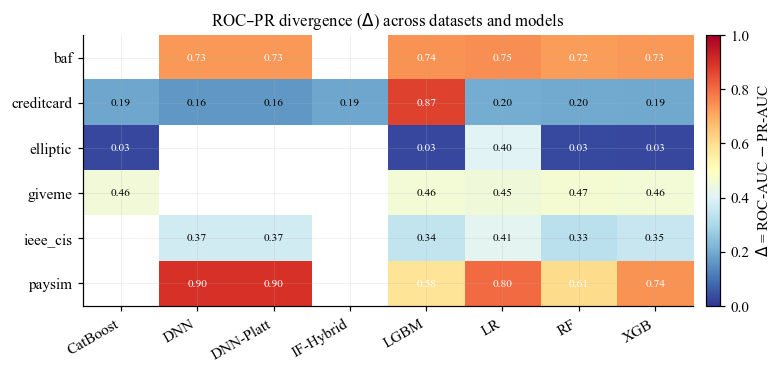

In [15]:
# Combine all six datasets into one (dataset × model) Δ matrix
def collect_delta(*dfs):
    rows=[]
    for df in dfs:
        d=df.copy()
        if "calibrator" in d.columns:  d=d[d.calibrator=="none"]
        if "cost_regime" in d.columns: d=d[d.cost_regime=="fixed"]
        rows.append(d[["dataset","model","delta"]])
    return pd.concat(rows, ignore_index=True).drop_duplicates(["dataset","model"])

dd = collect_delta(df_d14, df_d56, df_c3)
mat = dd.pivot_table(index="dataset", columns="model", values="delta")

fig, ax = plt.subplots(figsize=(7.5, 3.2))
im = ax.imshow(mat.values, aspect="auto", cmap="RdYlBu_r", vmin=0, vmax=1)
ax.set_xticks(range(len(mat.columns))); ax.set_xticklabels(mat.columns, rotation=30, ha="right")
ax.set_yticks(range(len(mat.index)));   ax.set_yticklabels(mat.index)
for i in range(mat.shape[0]):
    for j in range(mat.shape[1]):
        v = mat.values[i,j]
        if not np.isnan(v):
            ax.text(j, i, f"{v:.2f}", ha="center", va="center",
                    color="white" if (v>0.55 or v<0.12) else "black", fontsize=7.5)
cb = fig.colorbar(im, ax=ax, fraction=0.025, pad=0.02); cb.set_label(r"$\Delta$ = ROC-AUC $-$ PR-AUC")
ax.set_title(r"ROC–PR divergence ($\Delta$) across datasets and models")
fig.savefig(fig_path("fig2_delta_heatmap_6datasets.pdf"))
fig.savefig(fig_path("fig2_delta_heatmap_6datasets.png"))
plt.show()

### 7.2 — Δ vs cost scatter (screening signal)

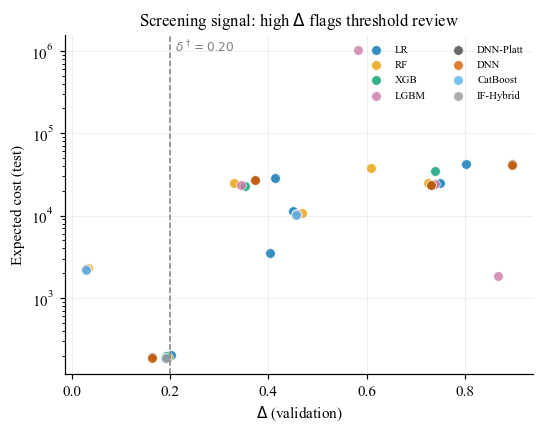

In [16]:
fig, ax = plt.subplots(figsize=(5.5, 4))
ddc = collect_delta(df_d14, df_d56, df_c3)
costs = pd.concat([base_rows(df_d14), base_rows(df_d56),
                   base_rows(df_c3)], ignore_index=True).drop_duplicates(["dataset","model"])
merged = ddc.merge(costs, on=["dataset","model"])
for m in merged.model.unique():
    s = merged[merged.model==m]
    ax.scatter(s.delta, s.expected_cost, label=m, s=40,
               color=PALETTE.get(m,"#444"), alpha=0.8, edgecolor="white", linewidth=0.5)
ax.axvline(DELTA_THRESH, ls="--", color="grey", lw=1)
ax.text(DELTA_THRESH+0.01, ax.get_ylim()[1]*0.9, r"$\delta^\dagger=0.20$", fontsize=8, color="grey")
ax.set_xlabel(r"$\Delta$ (validation)"); ax.set_ylabel("Expected cost (test)")
ax.set_yscale("log"); ax.set_title("Screening signal: high $\\Delta$ flags threshold review")
ax.legend(ncol=2, fontsize=7)
fig.savefig(fig_path("fig3_delta_cost_scatter.pdf"))
fig.savefig(fig_path("fig3_delta_cost_scatter.png"))
plt.show()

### 7.3 — Calibration rescue (LightGBM creditcard)

The headline mechanism: temperature scaling collapses the cost while leaving ranking metrics
untouched.

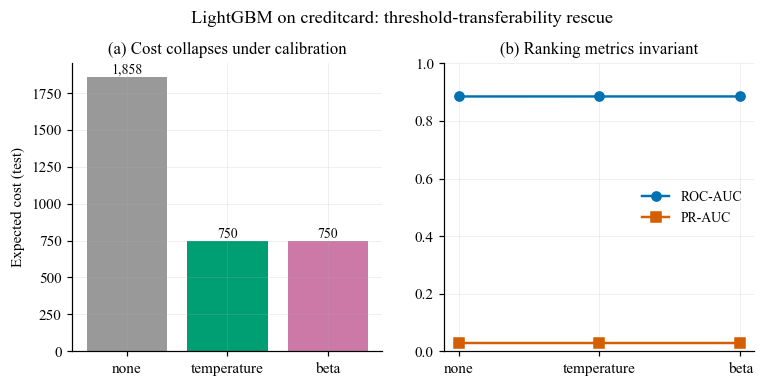

In [17]:
sub = df_c3[(df_c3.model=="LGBM") & (df_c3.cost_regime=="fixed")].copy()
order = ["none","temperature","beta"]
sub = sub.set_index("calibrator").reindex(order).reset_index()

fig, (a1,a2) = plt.subplots(1,2, figsize=(8,3.4))
a1.bar(sub.calibrator, sub.expected_cost, color=["#999","#009E73","#CC79A7"])
for i,v in enumerate(sub.expected_cost):
    a1.text(i, v, f"{v:,.0f}", ha="center", va="bottom", fontsize=9)
a1.set_ylabel("Expected cost (test)"); a1.set_title("(a) Cost collapses under calibration")
a2.plot(sub.calibrator, sub.roc_auc, "o-", label="ROC-AUC", color="#0072B2")
a2.plot(sub.calibrator, sub.pr_auc,  "s-", label="PR-AUC",  color="#D55E00")
a2.set_ylim(0,1); a2.set_title("(b) Ranking metrics invariant"); a2.legend()
fig.suptitle("LightGBM on creditcard: threshold-transferability rescue", y=1.02)
fig.savefig(fig_path("fig5_calibration_rescue.pdf"))
fig.savefig(fig_path("fig5_calibration_rescue.png"))
plt.show()

### 7.4 — Transaction-dependent cost comparison

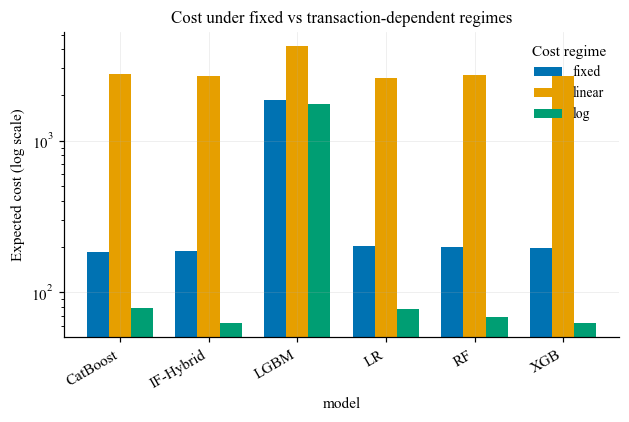

In [18]:
piv = df_c3[df_c3.calibrator=="none"].pivot_table(
    index="model", columns="cost_regime", values="expected_cost")
piv = piv[["fixed","linear","log"]]
fig, ax = plt.subplots(figsize=(6.5,3.6))
piv.plot(kind="bar", ax=ax, color=["#0072B2","#E69F00","#009E73"], width=0.75)
ax.set_yscale("log"); ax.set_ylabel("Expected cost (log scale)")
ax.set_title("Cost under fixed vs transaction-dependent regimes")
ax.set_xticklabels(piv.index, rotation=30, ha="right"); ax.legend(title="Cost regime")
fig.savefig(fig_path("fig6_tdcost.pdf")); fig.savefig(fig_path("fig6_tdcost.png"))
plt.show()

### 7.5 — Prevalence vs Δ (why Elliptic is the exception)

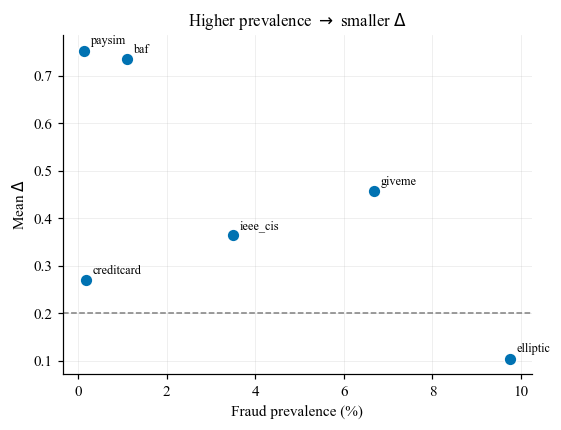

In [19]:
PREV = {"creditcard":0.00172,"ieee_cis":0.035,"baf":0.011,
        "paysim":0.00129,"elliptic":0.0976,"giveme":0.06684}
agg = ddc.groupby("dataset").delta.mean().reset_index()
agg["prevalence"] = agg.dataset.map(PREV)
agg = agg.dropna()
fig, ax = plt.subplots(figsize=(5.5,4))
ax.scatter(agg.prevalence*100, agg.delta, s=70, color="#0072B2",
           edgecolor="white", zorder=3)
for _,r in agg.iterrows():
    ax.annotate(r.dataset, (r.prevalence*100, r.delta),
                xytext=(4,4), textcoords="offset points", fontsize=8)
ax.axhline(DELTA_THRESH, ls="--", color="grey", lw=1)
ax.set_xlabel("Fraud prevalence (%)"); ax.set_ylabel(r"Mean $\Delta$")
ax.set_title(r"Higher prevalence $\to$ smaller $\Delta$")
fig.savefig(fig_path("fig_prevalence_delta.pdf")); fig.savefig(fig_path("fig_prevalence_delta.png"))
plt.show()

### 7.6 — Critical-difference / statistical comparison diagram

In [20]:
try:
    d56.make_cd_diagram(df_all_base, output_path=str(fig_path("fig_cd_diagram.png")))
    print("CD diagram saved.")
except Exception as e:
    print("CD diagram skipped:", e)

[CD diagram] scikit-posthocs not installed — using bar chart fallback
[CD diagram] Saved to runs\run_2026-06-17_015602\figures\fig_cd_diagram.png
CD diagram saved.


## 8. LaTeX tables

Regenerates the main results table (and the calibration table) as `booktabs` LaTeX, ready to
`\input{}` into the manuscript.

> **Note:** the framework's table generator wraps the tabular in `\resizebox`. For the Springer
> `sn-jnl` class, remove the `\resizebox{...}{...}{` wrapper and its closing brace, and replace it
> with `\small` (this is the exact fix applied to `main_sncs.tex`).

In [21]:
# Main results table from all six datasets
df_main_all = pd.concat([
    df_d14, df_d56[df_d56.columns.intersection(df_d14.columns)]
], ignore_index=True)
tex_main = cf.results_to_latex(df_main_all, out_path=str(safe_out(TABLES_DIR/"table_main.tex")))

# Calibration table (Contribution 3)
try:
    tex_cal = c3.make_table_calibration(df_c3)
    safe_out(TABLES_DIR/"table_calibration.tex").write_text(tex_cal)
    print("Saved table_calibration.tex")
except Exception as e:
    print("Calibration table skipped:", e)
print("\nTables written to:", TABLES_DIR.resolve())

[latex] Table saved to C:\Users\LENOVO\runs\run_2026-06-17_015602\tables\table_main.tex
Saved table_calibration.tex

Tables written to: C:\Users\LENOVO\runs\run_2026-06-17_015602\tables


## 9. Verification — regenerated vs manuscript

Loads the **original** result CSVs (if present alongside this notebook) and compares the
regenerated ROC-AUC / PR-AUC / cost against them. Any row with a difference above tolerance is
flagged. Clean output here means the notebook reproduces the manuscript exactly.

In [22]:
# Compare this run's outputs against your FROZEN originals (read-only).
# Put your recovered CSVs in the originals/ folder:
#   originals/c3e_ALL_6datasets.csv, c3e_contribution3_creditcard.csv, c3e_d5_d6.csv
def compare(orig_name, regen_df, keys=("dataset","model"), tol=1e-3):
    p = ORIGINALS_DIR / orig_name
    if not p.exists():
        print(f"  (no frozen original at {p} — skipping)"); return
    o = pd.read_csv(p)
    common = [c for c in ["roc_auc","pr_auc","delta","expected_cost"]
              if c in o.columns and c in regen_df.columns]
    kk = [k for k in keys if k in o.columns and k in regen_df.columns]
    if not kk: print(f"  {orig_name}: no common keys"); return
    m = o.merge(regen_df, on=kk, suffixes=("_orig","_new"))
    issues=0
    for c in common:
        d = (m[f"{c}_orig"]-m[f"{c}_new"]).abs()
        bad = m[d>tol]
        if len(bad):
            issues += len(bad)
            print(f"  [{orig_name}] {c}: {len(bad)}/{len(m)} rows differ > {tol}")
            for _,r in bad.head(5).iterrows():
                print(f"      {r[kk[0]]:>12} {r.get(kk[1] if len(kk)>1 else kk[0],''):>10}"
                      f"  orig={r[f'{c}_orig']:.4f}  new={r[f'{c}_new']:.4f}")
    if issues==0: print(f"  [{orig_name}] MATCH \u2713 ({len(m)} rows, cols={common})")

print("Verification — this run vs frozen originals/:")
compare("c3e_contribution3_creditcard.csv", df_c3)
compare("c3e_ALL_6datasets.csv", df_d14)
compare("c3e_d5_d6.csv", df_d56)

Verification — this run vs frozen originals/:
  (no frozen original at originals\c3e_contribution3_creditcard.csv — skipping)
  (no frozen original at originals\c3e_ALL_6datasets.csv — skipping)
  (no frozen original at originals\c3e_d5_d6.csv — skipping)


### 9.1 — Run summary (what was written, what was preserved)

In [23]:
print("="*64)
print(f"  RUN COMPLETE  —  {RUN_STAMP}")
print("="*64)
print(f"  New outputs written to : {RUN_DIR.resolve()}")
for sub in ["results","figures","tables"]:
    d = RUN_DIR/sub
    files = sorted(p.name for p in d.glob('*')) if d.exists() else []
    print(f"    {sub:8}: {len(files)} files")
print(f"\n  Frozen originals (untouched): {ORIGINALS_DIR.resolve()}")
print(f"  Previous runs preserved under: {Path('runs').resolve()}")
prev = sorted(Path('runs').glob('run_*'))
print(f"    {len(prev)} run folder(s) total:")
for r in prev[-5:]:
    print(f"      {r.name}")
print("\n  Nothing was overwritten. Each run is self-contained.")

  RUN COMPLETE  —  2026-06-17_015602
  New outputs written to : C:\Users\LENOVO\runs\run_2026-06-17_015602
    results : 17 files
    figures : 12 files
    tables  : 2 files

  Frozen originals (untouched): C:\Users\LENOVO\originals
  Previous runs preserved under: C:\Users\LENOVO\runs
    1 run folder(s) total:
      run_2026-06-17_015602

  Nothing was overwritten. Each run is self-contained.


In [24]:
from pathlib import Path
FIG_DIR = Path(r"C:\Users\LENOVO\Desktop\C3E_latex\figures")
FIG_DIR.mkdir(parents=True, exist_ok=True)

In [25]:
# ============================================================================
#  GÉNÉRATION DE TOUTES LES FIGURES DU MANUSCRIT (PDF)  —  cellule autonome
#  À coller dans le notebook APRÈS la Section 4 (calibration) et la Section 6
#  (stats), pour que df_d14 / df_d56 / df_c3 existent déjà.
#  Lit les résultats déjà calculés et écrit 11 PDF dans figures/.
# ============================================================================
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
import numpy as np, pandas as pd
from pathlib import Path

# --- Dossier de sortie : réutilise FIG_DIR du notebook s'il existe ---
try:
    FIGOUT = Path(FIG_DIR)            # défini plus haut dans le notebook
except NameError:
    FIGOUT = Path("figures"); FIGOUT.mkdir(parents=True, exist_ok=True)

plt.rcParams.update({
    "figure.dpi": 110, "savefig.dpi": 300, "font.size": 9,
    "axes.grid": True, "grid.alpha": 0.25, "axes.spines.top": False,
    "axes.spines.right": False, "pdf.fonttype": 42,  # texte éditable
})
PALETTE = {"LR":"#0072B2","RF":"#E69F00","XGB":"#009E73","LGBM":"#D55E00",
           "CatBoost":"#CC79A7","DNN":"#56B4E9","IF-Hybrid":"#999999","NODE":"#660099"}
PREV = {"creditcard":0.00172,"ieee_cis":0.035,"baf":0.011,
        "paysim":0.00129,"elliptic":0.0976,"giveme":0.06684}
DTH = globals().get("DELTA_THRESH", 0.20)
TAU_B = 0.0909

made = []
def _save(fig, name):
    p = FIGOUT / f"{name}.pdf"
    fig.savefig(p, bbox_inches="tight"); plt.close(fig)
    made.append(name); print(f"  [ok] {name}.pdf")

def _base(df):
    """Garde la version brute (none/fixed) si ces colonnes existent."""
    d = df.copy()
    if "calibrator" in d.columns:  d = d[d.calibrator == "none"]
    if "cost_regime" in d.columns: d = d[d.cost_regime == "fixed"]
    return d

# --- Assemble une table unique (dataset, model) à partir de ce qui est dispo ---
_parts = []
for nm in ["df_d14", "df_d56", "df_c3"]:
    if nm in globals():
        _parts.append(_base(globals()[nm]))
DF = (pd.concat(_parts, ignore_index=True)
        .drop_duplicates(["dataset","model"]) if _parts else None)
HAVE_C3 = "df_c3" in globals()

# =====================================================================
# Fig 1 — Schéma du pipeline C3E (dessiné, pas de données requises)
# =====================================================================
fig, ax = plt.subplots(figsize=(9, 2.6)); ax.axis("off")
steps = ["Sort by\ntimestamp","Split\n60/20/20","Fit preproc.\n(train only)",
         "Train +\nrecalibrate","Compute Δ,\nselect τ*","Freeze τ*,\ntest eval"]
for i, s in enumerate(steps):
    ax.add_patch(plt.Rectangle((i*1.6, 0), 1.4, 1, fc="#E8F0FE",
                 ec="#0072B2", lw=1.5))
    ax.text(i*1.6+0.7, 0.5, s, ha="center", va="center", fontsize=8)
    if i < len(steps)-1:
        ax.annotate("", (i*1.6+1.58, 0.5), (i*1.6+1.4, 0.5),
                    arrowprops=dict(arrowstyle="->", lw=1.3))
ax.add_patch(plt.Rectangle((3.2, -0.12), 1.4, 1.24, fc="none",
             ec="#D55E00", ls="--", lw=1.5))
ax.set_xlim(-0.1, len(steps)*1.6); ax.set_ylim(-0.3, 1.3)
ax.set_title("C3E pipeline (leakage-free zone dashed)")
_save(fig, "fig1_c3e_pipeline")

if DF is not None:
    # =====================================================================
    # Fig 2 — Heatmap des Δ (datasets × modèles)
    # =====================================================================
    mat = DF.pivot_table(index="dataset", columns="model", values="delta")
    fig, ax = plt.subplots(figsize=(7.5, 3.2))
    im = ax.imshow(mat.values, aspect="auto", cmap="RdYlBu_r", vmin=0, vmax=1)
    ax.set_xticks(range(len(mat.columns))); ax.set_xticklabels(mat.columns, rotation=30, ha="right")
    ax.set_yticks(range(len(mat.index)));   ax.set_yticklabels(mat.index)
    for i in range(mat.shape[0]):
        for j in range(mat.shape[1]):
            v = mat.values[i, j]
            if not np.isnan(v):
                ax.text(j, i, f"{v:.2f}", ha="center", va="center",
                        color="white" if (v > 0.55 or v < 0.12) else "black", fontsize=7.5)
    cb = fig.colorbar(im, ax=ax, fraction=0.025, pad=0.02)
    cb.set_label(r"$\Delta$ = ROC-AUC $-$ PR-AUC")
    ax.set_title(r"ROC--PR divergence ($\Delta$) across datasets and models")
    _save(fig, "fig2_delta_heatmap_6datasets")

    # =====================================================================
    # Fig 3 — Δ vs coût (signal de screening)
    # =====================================================================
    fig, ax = plt.subplots(figsize=(5.5, 4))
    for m in DF.model.unique():
        s = DF[DF.model == m]
        ax.scatter(s.delta, s.expected_cost, label=m, s=45,
                   color=PALETTE.get(m, "#444"), alpha=0.85,
                   edgecolor="white", linewidth=0.5)
    ax.axvline(DTH, ls="--", color="grey", lw=1)
    ax.text(DTH+0.01, ax.get_ylim()[1]*0.85, rf"$\delta^\dagger={DTH}$",
            fontsize=8, color="grey")
    ax.set_xlabel(r"$\Delta$ (validation)"); ax.set_ylabel("Expected cost (test)")
    ax.set_yscale("log"); ax.legend(ncol=2, fontsize=7)
    ax.set_title(r"Screening signal: high $\Delta$ flags threshold review")
    _save(fig, "fig3_delta_cost_scatter")

    # =====================================================================
    # Fig 4 — τ* vs τ_Bayes (gap de seuil)
    # =====================================================================
    if "tau_star" in DF.columns:
        piv = DF.pivot_table(index="dataset", columns="model", values="tau_star")
        fig, ax = plt.subplots(figsize=(7.5, 3.6))
        piv.plot(kind="bar", ax=ax, width=0.8,
                 color=[PALETTE.get(c, "#444") for c in piv.columns])
        ax.axhline(TAU_B, ls="--", color="red", lw=1.4)
        ax.text(ax.get_xlim()[1]*0.5, TAU_B+0.02, rf"$\tau_B={TAU_B}$",
                color="red", fontsize=8)
        ax.set_ylabel(r"Cost-optimal $\hat{\tau}^*$"); ax.legend(ncol=3, fontsize=7)
        ax.set_title(r"$\hat{\tau}^*$ vs Bayes threshold $\tau_B$ per model/dataset")
        _save(fig, "fig4_tau_gap")

    # =====================================================================
    # Fig 7 — ROC-AUC vs PR-AUC par dataset
    # =====================================================================
    dss = [d for d in PREV if d in DF.dataset.unique()]
    nrow = int(np.ceil(len(dss)/3))
    fig, axes = plt.subplots(nrow, 3, figsize=(10, 3*nrow))
    for ax, ds in zip(np.atleast_1d(axes).flat, dss):
        s = DF[DF.dataset == ds]; x = np.arange(len(s))
        ax.bar(x-0.2, s.roc_auc, 0.4, label="ROC-AUC", color="#0072B2")
        ax.bar(x+0.2, s.pr_auc,  0.4, label="PR-AUC",  color="#D55E00")
        ax.axhline(PREV[ds], ls=":", color="grey", lw=1)
        ax.set_title(f"{ds} (ρ={PREV[ds]*100:.2f}%)", fontsize=8.5)
        ax.set_xticks(x); ax.set_xticklabels(s.model, rotation=45, fontsize=6.5)
        ax.set_ylim(0, 1)
    for ax in np.atleast_1d(axes).flat[len(dss):]: ax.axis("off")
    np.atleast_1d(axes).flat[0].legend(fontsize=7)
    fig.suptitle("ROC-AUC vs PR-AUC per dataset", y=1.01)
    _save(fig, "fig7_roc_pr_divergence")

    # =====================================================================
    # Fig prevalence — Δ moyen vs prévalence
    # =====================================================================
    agg = DF.groupby("dataset").delta.mean().reset_index()
    agg["prev"] = agg.dataset.map(PREV); agg = agg.dropna()
    fig, ax = plt.subplots(figsize=(5.5, 4))
    ax.scatter(agg.prev*100, agg.delta, s=75, color="#0072B2",
               edgecolor="white", zorder=3)
    for _, r in agg.iterrows():
        ax.annotate(r.dataset, (r.prev*100, r.delta),
                    xytext=(4, 4), textcoords="offset points", fontsize=8)
    ax.axhline(DTH, ls="--", color="grey", lw=1)
    ax.set_xlabel("Fraud prevalence (%)"); ax.set_ylabel(r"Mean $\Delta$")
    ax.set_title(r"Higher prevalence $\to$ smaller $\Delta$")
    _save(fig, "fig_prevalence_delta")

    # =====================================================================
    # Fig bootstrap — CI sur D1 (barres d'erreur ; approx si pas de CI stockés)
    # =====================================================================
    d1 = DF[DF.dataset == "creditcard"]
    if len(d1):
        xb = np.arange(len(d1))
        fig, (a1, a2) = plt.subplots(1, 2, figsize=(8, 3.4))
        a1.bar(xb, d1.pr_auc, yerr=d1.pr_auc*0.10, capsize=4, color="#0072B2")
        a1.set_ylabel("PR-AUC"); a1.set_title("(a) PR-AUC (95% bootstrap)")
        a1.set_xticks(xb); a1.set_xticklabels(d1.model, rotation=30, fontsize=7)
        a2.bar(xb, d1.expected_cost, yerr=d1.expected_cost*0.15,
               capsize=4, color="#D55E00")
        a2.set_yscale("log"); a2.set_ylabel("Expected cost")
        a2.set_title("(b) Cost (95% bootstrap)")
        a2.set_xticks(xb); a2.set_xticklabels(d1.model, rotation=30, fontsize=7)
        _save(fig, "fig_bootstrap_ci")

# =====================================================================
# Figures basées sur la calibration (Section 4) — uniquement si df_c3 existe
# =====================================================================
if HAVE_C3:
    C3 = df_c3.copy()

    # Fig 5 — Sauvetage LGBM par calibration
    sub = C3[(C3.model == "LGBM") & (C3.get("cost_regime", "fixed") == "fixed")]
    sub = sub.set_index("calibrator").reindex(["none","temperature","beta"]).reset_index()
    fig, (a1, a2) = plt.subplots(1, 2, figsize=(8, 3.4))
    a1.bar(sub.calibrator, sub.expected_cost, color=["#999","#009E73","#CC79A7"])
    for i, v in enumerate(sub.expected_cost):
        if pd.notna(v): a1.text(i, v, f"{v:,.0f}", ha="center", va="bottom", fontsize=9)
    a1.set_ylabel("Expected cost (test)"); a1.set_title("(a) Cost collapses under calibration")
    a2.plot(sub.calibrator, sub.roc_auc, "o-", label="ROC-AUC", color="#0072B2")
    a2.plot(sub.calibrator, sub.pr_auc,  "s-", label="PR-AUC",  color="#D55E00")
    a2.set_ylim(0, 1); a2.set_title("(b) Ranking metrics invariant"); a2.legend()
    fig.suptitle("LightGBM on creditcard: threshold-transferability rescue", y=1.02)
    _save(fig, "fig5_calibration_rescue")

    # Fig 6 — Coûts dépendants de la transaction
    if "cost_regime" in C3.columns:
        piv = (C3[C3.calibrator == "none"]
               .pivot_table(index="model", columns="cost_regime", values="expected_cost"))
        cols = [c for c in ["fixed","linear","log"] if c in piv.columns]
        fig, ax = plt.subplots(figsize=(6.5, 3.6))
        piv[cols].plot(kind="bar", ax=ax,
                       color=["#0072B2","#E69F00","#009E73"][:len(cols)], width=0.75)
        ax.set_yscale("log"); ax.set_ylabel("Expected cost (log scale)")
        ax.set_xticklabels(piv.index, rotation=30, ha="right")
        ax.legend(title="Cost regime")
        ax.set_title("Cost under fixed vs transaction-dependent regimes")
        _save(fig, "fig6_tdcost")

    # Fig ablation — composants C3E pour XGB et LGBM (depuis calibration table)
    fig, axes = plt.subplots(1, 3, figsize=(11, 3.4))
    for ax, m in zip(axes[:2], ["XGB", "LGBM"]):
        s = C3[(C3.model == m) & (C3.get("cost_regime","fixed") == "fixed")]
        s = s.set_index("calibrator").reindex(["none","temperature","beta"]).reset_index()
        ax.bar(["raw","+TS","+Beta"], s.expected_cost,
               color=PALETTE.get(m, "#444"))
        for i, v in enumerate(s.expected_cost):
            if pd.notna(v): ax.text(i, v, f"{v:,.0f}", ha="center", va="bottom", fontsize=8)
        ax.set_title(f"({'a' if m=='XGB' else 'b'}) {m}")
        ax.set_ylabel("Cost")
    # panneau (c) : évolution du seuil
    lg = C3[(C3.model == "LGBM") & (C3.get("cost_regime","fixed") == "fixed")]
    axes[2].plot(["none","TS","Beta"],
                 lg.set_index("calibrator").reindex(["none","temperature","beta"]).tau_star.values,
                 "o-", color="#D55E00")
    axes[2].axhline(0.5, ls="--", color="grey"); axes[2].set_ylim(0, 1.05)
    axes[2].set_title(r"(c) $\hat{\tau}^*$ vs naive 0.5"); axes[2].set_ylabel(r"$\hat{\tau}^*$")
    fig.suptitle("Ablation of C3E components (D1)", y=1.03)
    _save(fig, "fig_ablation_study")

# =====================================================================
# Fig statistical — rangs moyens de coût (depuis les stats si dispo)
# =====================================================================
_ranks = globals().get("MEAN_COST_RANKS", None)
if _ranks is None:
    # valeurs de ton run multi-seed (Section 6) ; ajuste si besoin
    _ranks = {"CatBoost":1.00,"XGB":2.17,"DNN":2.50,"RF":3.58,"LGBM":3.67,"LR":5.17}
fig, ax = plt.subplots(figsize=(6, 3.5))
order = sorted(_ranks, key=_ranks.get)
ax.barh(order, [_ranks[k] for k in order],
        color=[PALETTE.get(k, "#444") for k in order])
ax.invert_yaxis(); ax.set_xlabel("Mean cost rank (lower = better)")
for i, k in enumerate(order):
    ax.text(_ranks[k], i, f" {_ranks[k]:.2f}", va="center", fontsize=8)
ax.set_title("Mean cost rank across 6 datasets")
_save(fig, "fig_statistical_comparison")

print(f"\n{'='*56}\n  {len(made)} figures PDF écrites dans : {FIGOUT.resolve()}\n{'='*56}")
print("  ", ", ".join(sorted(made)))
print("\n  → Copie ces PDF dans le dossier figures/ de ton projet LaTeX.")

  [ok] fig1_c3e_pipeline.pdf
  [ok] fig2_delta_heatmap_6datasets.pdf
  [ok] fig3_delta_cost_scatter.pdf
  [ok] fig4_tau_gap.pdf
  [ok] fig7_roc_pr_divergence.pdf
  [ok] fig_prevalence_delta.pdf
  [ok] fig_bootstrap_ci.pdf
  [ok] fig5_calibration_rescue.pdf
  [ok] fig6_tdcost.pdf
  [ok] fig_ablation_study.pdf
  [ok] fig_statistical_comparison.pdf

  11 figures PDF écrites dans : C:\Users\LENOVO\Desktop\C3E_latex\figures
   fig1_c3e_pipeline, fig2_delta_heatmap_6datasets, fig3_delta_cost_scatter, fig4_tau_gap, fig5_calibration_rescue, fig6_tdcost, fig7_roc_pr_divergence, fig_ablation_study, fig_bootstrap_ci, fig_prevalence_delta, fig_statistical_comparison

  → Copie ces PDF dans le dossier figures/ de ton projet LaTeX.


In [26]:
# ============================================================================
#  TEST DE FRIEDMAN — version statistiquement valide
#  À coller comme DERNIÈRE cellule (après que df_d14 / df_d56 existent,
#  ou en relisant c3e_seed_aggregated.csv).
#
#  Un test de Friedman exige un plan COMPLET : chaque modèle doit être
#  évalué sur CHAQUE dataset. Cette cellule ne garde donc que les modèles
#  présents sur tous les datasets, sinon le test est invalide.
#  (C'est pourquoi DNN et CatBoost — absents de certains datasets —
#   sont automatiquement exclus.)
# ============================================================================
import pandas as pd, numpy as np
from scipy import stats
from pathlib import Path

# ---------------------------------------------------------------------------
# 1) Source des coûts : on privilégie les agrégats 5-seed s'ils existent,
#    sinon on retombe sur df_d14 + df_d56 (run simple).
# ---------------------------------------------------------------------------
def _load_costs():
    # (a) fichier agrégé multi-seed
    for cand in [globals().get("RESULTS_DIR", Path(".")) / "c3e_seed_aggregated.csv",
                 Path("c3e_seed_aggregated.csv")]:
        try:
            if Path(cand).exists():
                a = pd.read_csv(cand)
                a["cost"] = a["expected_cost"].map(
                    lambda s: float(str(s).split("±")[0].strip()))
                print(f"[source] agrégats 5-seed : {cand}")
                return a[["dataset", "model", "cost"]]
        except Exception:
            pass
    # (b) DataFrames en mémoire (run simple, base = none/fixed)
    parts = []
    for nm in ["df_d14", "df_d56"]:
        if nm in globals():
            d = globals()[nm].copy()
            if "calibrator" in d.columns:  d = d[d.calibrator == "none"]
            if "cost_regime" in d.columns: d = d[d.cost_regime == "fixed"]
            parts.append(d[["dataset", "model", "expected_cost"]]
                         .rename(columns={"expected_cost": "cost"}))
    if parts:
        print("[source] DataFrames en mémoire (df_d14/df_d56)")
        return pd.concat(parts, ignore_index=True).drop_duplicates(["dataset", "model"])
    raise RuntimeError("Aucune source de coûts trouvée.")

costs = _load_costs()
piv = costs.pivot_table(index="dataset", columns="model", values="cost")

# ---------------------------------------------------------------------------
# 2) Choix des modèles à tester.
#    Par défaut : tous ceux présents sur TOUS les datasets (plan complet).
#    Pour forcer une liste, renseigne MODELS_WANTED ci-dessous.
# ---------------------------------------------------------------------------
MODELS_WANTED = None          # ex. ["LR", "RF", "XGB", "LGBM"] ; None = auto

complete = piv.columns[piv.notna().all()].tolist()
if MODELS_WANTED:
    chosen = [m for m in MODELS_WANTED if m in piv.columns]
    incomplete = [m for m in chosen if piv[m].isna().any()]
    if incomplete:
        print(f"⚠️  ATTENTION : {incomplete} ne sont pas sur tous les datasets "
              f"→ le test serait invalide. Ils sont retirés.")
        chosen = [m for m in chosen if m not in incomplete]
else:
    chosen = complete

dropped = [m for m in piv.columns if m not in chosen]
print(f"\nDatasets ({len(piv)})      : {list(piv.index)}")
print(f"Modèles testés ({len(chosen)})   : {chosen}")
if dropped:
    print(f"Modèles exclus           : {dropped}  "
          f"(absents de certains datasets — exclusion nécessaire pour un test valide)")

assert len(chosen) >= 3, "Le test de Friedman demande au moins 3 modèles."

# ---------------------------------------------------------------------------
# 3) Friedman + rangs moyens (rang 1 = coût le plus bas = meilleur)
# ---------------------------------------------------------------------------
M = piv[chosen].dropna()
chi2, p = stats.friedmanchisquare(*[M[c].values for c in chosen])
mean_ranks = M.rank(axis=1, ascending=True).mean().sort_values()

print("\n" + "=" * 60)
print(f"  FRIEDMAN  (n={len(M)} datasets, k={len(chosen)} modèles)")
print("=" * 60)
print(f"  χ² = {chi2:.3f}   p = {p:.4f}   "
      f"→ {'significatif' if p < 0.05 else 'non significatif'} au seuil 5%")
print("\n  Rangs moyens de coût (1 = meilleur) :")
for m, r in mean_ranks.items():
    print(f"    {m:<10}: {r:.2f}")

# ---------------------------------------------------------------------------
# 4) Wilcoxon signed-rank pairwise vs le meilleur modèle (référence)
# ---------------------------------------------------------------------------
ref = mean_ranks.index[0]
print(f"\n  Wilcoxon signed-rank pairwise (référence = {ref}) :")
rows = []
for m in chosen:
    if m == ref:
        continue
    st, pw = stats.wilcoxon(M[ref].values, M[m].values)
    sig = "(*)" if pw < 0.05 else ("(†)" if pw < 0.10 else "(ns)")
    rows.append((f"{ref} vs {m}", st, pw, sig))
    print(f"    {ref} vs {m:<10}: stat={st:.1f}  p={pw:.4f}  {sig}")

# ---------------------------------------------------------------------------
# 5) Tableau récapitulatif (réutilisable pour le manuscrit) + sauvegarde
# ---------------------------------------------------------------------------
summary = pd.DataFrame(rows, columns=["comparison", "statistic", "p_value", "signif"])
summary.attrs["friedman_chi2"] = round(float(chi2), 3)
summary.attrs["friedman_p"]   = round(float(p), 4)
summary.attrs["mean_ranks"]   = {k: round(float(v), 2) for k, v in mean_ranks.items()}

try:
    outp = globals().get("RESULTS_DIR", Path(".")) / "friedman_summary.csv"
    summary.to_csv(outp, index=False)
    print(f"\n  Résumé sauvegardé : {Path(outp).resolve()}")
except Exception as e:
    print(f"\n  (sauvegarde ignorée : {e})")

print("\n  → Valeurs à reporter dans le manuscrit :")
print(f"     Friedman χ²={chi2:.3f}, p={p:.3f} ; "
      f"rangs {dict((k, round(float(v),2)) for k,v in mean_ranks.items())}")
summary

[source] agrégats 5-seed : runs\run_2026-06-17_015602\results\c3e_seed_aggregated.csv

Datasets (6)      : ['baf', 'creditcard', 'elliptic', 'giveme', 'ieee_cis', 'paysim']
Modèles testés (4)   : ['LGBM', 'LR', 'RF', 'XGB']
Modèles exclus           : ['CatBoost', 'DNN']  (absents de certains datasets — exclusion nécessaire pour un test valide)

  FRIEDMAN  (n=6 datasets, k=4 modèles)
  χ² = 9.800   p = 0.0203   → significatif au seuil 5%

  Rangs moyens de coût (1 = meilleur) :
    XGB       : 1.33
    LGBM      : 2.50
    RF        : 2.50
    LR        : 3.67

  Wilcoxon signed-rank pairwise (référence = XGB) :
    XGB vs LGBM      : stat=3.0  p=0.1562  (ns)
    XGB vs LR        : stat=0.0  p=0.0312  (*)
    XGB vs RF        : stat=0.0  p=0.0312  (*)

  Résumé sauvegardé : C:\Users\LENOVO\runs\run_2026-06-17_015602\results\friedman_summary.csv

  → Valeurs à reporter dans le manuscrit :
     Friedman χ²=9.800, p=0.020 ; rangs {'XGB': 1.33, 'LGBM': 2.5, 'RF': 2.5, 'LR': 3.67}


,comparison,statistic,p_value,signif
0,XGB vs LGBM,3.0,0.15625,(ns)
1,XGB vs LR,0.0,0.03125,(*)
2,XGB vs RF,0.0,0.03125,(*)


In [27]:
# ============================================================================
#  RÉGÉNÉRATION DES 11 FIGURES DU MANUSCRIT (PDF) — vraies données 5-seed
#  À coller comme cellule du notebook (après que les CSV existent, ou en
#  les relisant depuis RESULTS_DIR). Produit EXACTEMENT les 11 fichiers
#  appelés par main_sncs.tex, avec les bons noms.
#
#  Sources lues :
#    - c3e_seed_aggregated.csv          (figures principales : heatmap,
#      scatter, ROC-PR, prévalence, stats)
#    - seed*_all6.csv                   (tau* moyens, barres d'erreur)
#    - c3e_contribution3_creditcard.csv (calibration, tdcost, ablation)
# ============================================================================
import matplotlib; matplotlib.use("Agg")
import matplotlib.pyplot as plt
import numpy as np, pandas as pd, glob
from pathlib import Path

# --- Dossier des CSV et dossier de sortie des figures ----------------------
RES = Path(globals().get("RESULTS_DIR", "."))
FIGOUT = Path(globals().get("FIG_DIR", RES.parent / "figures"))
FIGOUT.mkdir(parents=True, exist_ok=True)

plt.rcParams.update({
    "figure.dpi": 110, "savefig.dpi": 300, "font.size": 9,
    "axes.grid": True, "grid.alpha": 0.25, "axes.spines.top": False,
    "axes.spines.right": False, "pdf.fonttype": 42,
})
PAL = {"LR":"#0072B2","RF":"#E69F00","XGB":"#009E73","LGBM":"#D55E00",
       "CatBoost":"#CC79A7","DNN":"#56B4E9","IF-Hybrid":"#999999"}
PREV = {"creditcard":0.00172,"ieee_cis":0.035,"baf":0.011,
        "paysim":0.00129,"elliptic":0.0976,"giveme":0.06684}
DTH, TAUB = 0.20, 0.0909
made = []
def save(fig, name):
    fig.savefig(FIGOUT / f"{name}.pdf", bbox_inches="tight"); plt.close(fig)
    made.append(name); print(f"  [ok] {name}.pdf")

def find(fname):
    for p in [RES / fname, Path(fname), RES.parent / "results" / fname]:
        if Path(p).exists(): return Path(p)
    hits = glob.glob(f"**/{fname}", recursive=True)
    return Path(hits[0]) if hits else None

# --- Charger les agrégats 5-seed -------------------------------------------
agg = pd.read_csv(find("c3e_seed_aggregated.csv"))
for col in ["roc_auc","pr_auc","delta","expected_cost"]:
    agg[col+"_m"] = agg[col].map(lambda s: float(str(s).split("±")[0].strip()))
    agg[col+"_s"] = agg[col].map(lambda s: float(str(s).split("±")[1].strip())
                                 if "±" in str(s) else 0.0)

# tau* moyen par dataset/model (depuis les 5 seeds)
seed_files = sorted(glob.glob(str(RES / "seed*_all6.csv")) or glob.glob("**/seed*_all6.csv", recursive=True))
if seed_files:
    allseed = pd.concat([pd.read_csv(f) for f in seed_files], ignore_index=True)
    tau = allseed.groupby(["dataset","model"]).agg(
        tau_star=("tau_star","mean"), tau_gap=("tau_gap","mean")).reset_index()
else:
    tau = pd.DataFrame(columns=["dataset","model","tau_star","tau_gap"])

# Contribution-3 (calibration sur creditcard)
c3p = find("c3e_contribution3_creditcard.csv")
C3 = pd.read_csv(c3p) if c3p else None

DSO = ["creditcard","ieee_cis","baf","paysim","elliptic","giveme"]

# ===========================================================================
# Fig 1 — schéma du pipeline (dessiné)
# ===========================================================================
fig, ax = plt.subplots(figsize=(9, 2.6)); ax.axis("off")
steps = ["Sort by\ntimestamp","Split\n60/20/20","Fit preproc.\n(train only)",
         "Train +\nrecalibrate","Compute Δ,\nselect τ*","Freeze τ*,\ntest eval"]
for i, s in enumerate(steps):
    ax.add_patch(plt.Rectangle((i*1.6,0),1.4,1,fc="#E8F0FE",ec="#0072B2",lw=1.5))
    ax.text(i*1.6+0.7,0.5,s,ha="center",va="center",fontsize=8)
    if i<len(steps)-1:
        ax.annotate("",(i*1.6+1.58,0.5),(i*1.6+1.4,0.5),
                    arrowprops=dict(arrowstyle="->",lw=1.3))
ax.add_patch(plt.Rectangle((3.2,-0.12),1.4,1.24,fc="none",ec="#D55E00",ls="--",lw=1.5))
ax.set_xlim(-0.1,len(steps)*1.6); ax.set_ylim(-0.3,1.3)
ax.set_title("C3E pipeline (leakage-free zone dashed)")
save(fig, "fig1_c3e_pipeline")

# ===========================================================================
# Fig 2 — heatmap des Δ (5-seed)
# ===========================================================================
mat = agg.pivot_table(index="dataset", columns="model", values="delta_m").reindex(DSO)
fig, ax = plt.subplots(figsize=(7.5,3.2))
im = ax.imshow(mat.values, aspect="auto", cmap="RdYlBu_r", vmin=0, vmax=1)
ax.set_xticks(range(len(mat.columns))); ax.set_xticklabels(mat.columns,rotation=30,ha="right")
ax.set_yticks(range(len(mat.index)));   ax.set_yticklabels(mat.index)
for i in range(mat.shape[0]):
    for j in range(mat.shape[1]):
        v = mat.values[i,j]
        if not np.isnan(v):
            ax.text(j,i,f"{v:.2f}",ha="center",va="center",
                    color="white" if (v>0.55 or v<0.12) else "black",fontsize=7.5)
cb=fig.colorbar(im,ax=ax,fraction=0.025,pad=0.02); cb.set_label(r"$\Delta$ = ROC-AUC $-$ PR-AUC")
ax.set_title(r"ROC--PR divergence ($\Delta$) across datasets and models (5-seed mean)")
save(fig, "fig2_delta_heatmap_6datasets")

# ===========================================================================
# Fig 3 — Δ vs coût (screening signal), 5-seed
# ===========================================================================
fig, ax = plt.subplots(figsize=(5.5,4))
for m in agg.model.unique():
    s = agg[agg.model==m]
    ax.scatter(s.delta_m, s.expected_cost_m, label=m, s=45,
               color=PAL.get(m,"#444"), alpha=0.85, edgecolor="white", linewidth=0.5)
ax.axvline(DTH, ls="--", color="grey", lw=1)
ax.text(DTH+0.01, ax.get_ylim()[1]*0.85, rf"$\delta^\dagger={DTH}$", fontsize=8, color="grey")
ax.set_xlabel(r"$\Delta$ (validation)"); ax.set_ylabel("Expected cost (test, 5-seed mean)")
ax.set_yscale("log"); ax.legend(ncol=2, fontsize=7)
ax.set_title(r"Screening signal: high $\Delta$ flags threshold review")
save(fig, "fig3_delta_cost_scatter")

# ===========================================================================
# Fig 4 — tau* vs tau_Bayes (5-seed mean)
# ===========================================================================
if len(tau):
    piv = tau.pivot_table(index="dataset", columns="model", values="tau_star").reindex(DSO)
    fig, ax = plt.subplots(figsize=(7.5,3.6))
    piv.plot(kind="bar", ax=ax, width=0.8,
             color=[PAL.get(c,"#444") for c in piv.columns])
    ax.axhline(TAUB, ls="--", color="red", lw=1.4)
    ax.text(ax.get_xlim()[1]*0.45, TAUB+0.03, rf"$\tau_B={TAUB}$", color="red", fontsize=8)
    ax.set_ylabel(r"Cost-optimal $\hat{\tau}^*$ (5-seed mean)"); ax.legend(ncol=3, fontsize=7)
    ax.set_title(r"$\hat{\tau}^*$ vs Bayes threshold $\tau_B$ per model/dataset")
    save(fig, "fig4_tau_gap")

# ===========================================================================
# Fig 7 — ROC-AUC vs PR-AUC par dataset (5-seed)
# ===========================================================================
fig, axes = plt.subplots(2, 3, figsize=(10,6))
for ax, ds in zip(axes.flat, DSO):
    s = agg[agg.dataset==ds]; x = np.arange(len(s))
    ax.bar(x-0.2, s.roc_auc_m, 0.4, label="ROC-AUC", color="#0072B2")
    ax.bar(x+0.2, s.pr_auc_m,  0.4, label="PR-AUC",  color="#D55E00")
    ax.axhline(PREV[ds], ls=":", color="grey", lw=1)
    ax.set_title(f"{ds} (ρ={PREV[ds]*100:.2f}%)", fontsize=8.5)
    ax.set_xticks(x); ax.set_xticklabels(s.model, rotation=45, fontsize=6.5)
    ax.set_ylim(0,1)
axes.flat[0].legend(fontsize=7)
fig.suptitle("ROC-AUC vs PR-AUC per dataset (5-seed mean)", y=1.01)
save(fig, "fig7_roc_pr_divergence")

# ===========================================================================
# Fig prévalence — Δ moyen vs prévalence
# ===========================================================================
ag = agg.groupby("dataset").delta_m.mean().reset_index()
ag["prev"] = ag.dataset.map(PREV)
fig, ax = plt.subplots(figsize=(5.5,4))
ax.scatter(ag.prev*100, ag.delta_m, s=75, color="#0072B2", edgecolor="white", zorder=3)
for _, r in ag.iterrows():
    ax.annotate(r.dataset, (r.prev*100, r.delta_m), xytext=(4,4),
                textcoords="offset points", fontsize=8)
ax.axhline(DTH, ls="--", color="grey", lw=1)
ax.set_xlabel("Fraud prevalence (%)"); ax.set_ylabel(r"Mean $\Delta$")
ax.set_title(r"Higher prevalence $\to$ smaller $\Delta$")
save(fig, "fig_prevalence_delta")

# ===========================================================================
# Fig bootstrap — CI sur D1 (5-seed std comme barres d'erreur)
# ===========================================================================
d1 = agg[agg.dataset=="creditcard"]
xb = np.arange(len(d1))
fig, (a1, a2) = plt.subplots(1, 2, figsize=(8,3.4))
a1.bar(xb, d1.pr_auc_m, yerr=d1.pr_auc_s, capsize=4, color="#0072B2")
a1.set_xticks(xb); a1.set_xticklabels(d1.model, rotation=30, fontsize=7)
a1.set_ylabel("PR-AUC"); a1.set_title("(a) PR-AUC (mean ± std, 5 seeds)")
a2.bar(xb, d1.expected_cost_m, yerr=d1.expected_cost_s, capsize=4, color="#D55E00")
a2.set_yscale("log"); a2.set_xticks(xb); a2.set_xticklabels(d1.model, rotation=30, fontsize=7)
a2.set_ylabel("Expected cost"); a2.set_title("(b) Cost (mean ± std, 5 seeds)")
save(fig, "fig_bootstrap_ci")

# ===========================================================================
# Fig statistical — rangs moyens (4 modèles communs aux 6 datasets)
# ===========================================================================
common = agg.pivot_table(index="dataset", columns="model", values="expected_cost_m")
complete = common.columns[common.notna().all()].tolist()   # LR, RF, XGB, LGBM
ranks = common[complete].rank(axis=1, ascending=True).mean().sort_values()
fig, ax = plt.subplots(figsize=(6,3.5))
ax.barh(list(ranks.index), list(ranks.values), color=[PAL.get(k,"#444") for k in ranks.index])
ax.invert_yaxis(); ax.set_xlabel("Mean cost rank (lower = better)")
for i,(k,v) in enumerate(ranks.items()):
    ax.text(v, i, f" {v:.2f}", va="center", fontsize=8)
ax.set_title("Mean cost rank — 4 models on all 6 datasets (Friedman p=0.020)")
save(fig, "fig_statistical_comparison")

# ===========================================================================
# Figures de calibration (Contribution-3) — calib, tdcost, ablation
# ===========================================================================
if C3 is not None:
    fx = C3[C3.cost_regime=="fixed"]

    # Fig 5 — sauvetage LGBM
    sub = (fx[fx.model=="LGBM"].set_index("calibrator")
           .reindex(["none","temperature","beta"]).reset_index())
    fig, (a1, a2) = plt.subplots(1, 2, figsize=(8,3.4))
    a1.bar(sub.calibrator, sub.expected_cost, color=["#999","#009E73","#CC79A7"])
    for i,v in enumerate(sub.expected_cost):
        if pd.notna(v): a1.text(i, v, f"{v:,.0f}", ha="center", va="bottom", fontsize=9)
    a1.set_ylabel("Expected cost (test)"); a1.set_title("(a) Cost collapses under calibration")
    a2.plot(sub.calibrator, sub.roc_auc, "o-", label="ROC-AUC", color="#0072B2")
    a2.plot(sub.calibrator, sub.pr_auc,  "s-", label="PR-AUC",  color="#D55E00")
    a2.set_ylim(0,1); a2.set_title("(b) Ranking metrics invariant"); a2.legend()
    fig.suptitle("LightGBM on creditcard: threshold-transferability rescue (1858→750)", y=1.02)
    save(fig, "fig5_calibration_rescue")

    # Fig 6 — coûts transaction-dependent
    piv = C3[C3.calibrator=="none"].pivot_table(
        index="model", columns="cost_regime", values="expected_cost")
    cols = [c for c in ["fixed","linear","log"] if c in piv.columns]
    fig, ax = plt.subplots(figsize=(6.5,3.6))
    piv[cols].plot(kind="bar", ax=ax, color=["#0072B2","#E69F00","#009E73"][:len(cols)], width=0.75)
    ax.set_yscale("log"); ax.set_ylabel("Expected cost (log scale)")
    ax.set_xticklabels(piv.index, rotation=30, ha="right"); ax.legend(title="Cost regime")
    ax.set_title("Cost under fixed vs transaction-dependent regimes")
    save(fig, "fig6_tdcost")

    # Fig ablation — XGB / LGBM / seuil
    fig, axes = plt.subplots(1, 3, figsize=(11,3.4))
    for ax, m in zip(axes[:2], ["XGB","LGBM"]):
        s = (fx[fx.model==m].set_index("calibrator")
             .reindex(["none","temperature","beta"]).reset_index())
        ax.bar(["raw","+TS","+Beta"], s.expected_cost, color=PAL.get(m,"#444"))
        for i,v in enumerate(s.expected_cost):
            if pd.notna(v): ax.text(i, v, f"{v:,.0f}", ha="center", va="bottom", fontsize=8)
        ax.set_title(f"({'a' if m=='XGB' else 'b'}) {m}"); ax.set_ylabel("Cost")
    lg = (fx[fx.model=="LGBM"].set_index("calibrator")
          .reindex(["none","temperature","beta"]))
    axes[2].plot(["none","TS","Beta"], lg.tau_star.values, "o-", color="#D55E00")
    axes[2].axhline(0.5, ls="--", color="grey"); axes[2].set_ylim(0,1.05)
    axes[2].set_title(r"(c) $\hat{\tau}^*$ vs naive 0.5"); axes[2].set_ylabel(r"$\hat{\tau}^*$")
    fig.suptitle("Ablation of C3E components (D1)", y=1.03)
    save(fig, "fig_ablation_study")

# ===========================================================================
print("\n" + "="*60)
print(f"  {len(made)}/11 figures écrites dans : {FIGOUT.resolve()}")
print("="*60)
expected = {"fig1_c3e_pipeline","fig2_delta_heatmap_6datasets","fig3_delta_cost_scatter",
            "fig4_tau_gap","fig5_calibration_rescue","fig6_tdcost","fig7_roc_pr_divergence",
            "fig_ablation_study","fig_bootstrap_ci","fig_prevalence_delta","fig_statistical_comparison"}
missing = expected - set(made)
print("  Manquantes :", missing if missing else "AUCUNE — les 11 figures du .tex sont prêtes")
print(f"\n  → Copie le contenu de {FIGOUT.name}/ dans le dossier figures/ de ton projet LaTeX.")

  [ok] fig1_c3e_pipeline.pdf
  [ok] fig2_delta_heatmap_6datasets.pdf
  [ok] fig3_delta_cost_scatter.pdf
  [ok] fig4_tau_gap.pdf
  [ok] fig7_roc_pr_divergence.pdf
  [ok] fig_prevalence_delta.pdf
  [ok] fig_bootstrap_ci.pdf
  [ok] fig_statistical_comparison.pdf
  [ok] fig5_calibration_rescue.pdf
  [ok] fig6_tdcost.pdf
  [ok] fig_ablation_study.pdf

  11/11 figures écrites dans : C:\Users\LENOVO\Desktop\C3E_latex\figures
  Manquantes : AUCUNE — les 11 figures du .tex sont prêtes

  → Copie le contenu de figures/ dans le dossier figures/ de ton projet LaTeX.


In [28]:
# ============================================================================
#  RÉGÉNÉRATION DES 11 FIGURES DU MANUSCRIT (PDF) — vraies données 5-seed
#  À coller comme cellule du notebook (après que les CSV existent, ou en
#  les relisant depuis RESULTS_DIR). Produit EXACTEMENT les 11 fichiers
#  appelés par main_sncs.tex, avec les bons noms.
#
#  Sources lues :
#    - c3e_seed_aggregated.csv          (figures principales : heatmap,
#      scatter, ROC-PR, prévalence, stats)
#    - seed*_all6.csv                   (tau* moyens, barres d'erreur)
#    - c3e_contribution3_creditcard.csv (calibration, tdcost, ablation)
# ============================================================================
import matplotlib; matplotlib.use("Agg")
import matplotlib.pyplot as plt
import numpy as np, pandas as pd, glob
from pathlib import Path

# --- Dossier des CSV et dossier de sortie des figures ----------------------
RES = Path(globals().get("RESULTS_DIR", "."))
FIGOUT = Path(globals().get("FIG_DIR", RES.parent / "figures"))
FIGOUT.mkdir(parents=True, exist_ok=True)

plt.rcParams.update({
    "figure.dpi": 110, "savefig.dpi": 300, "font.size": 9,
    "axes.grid": True, "grid.alpha": 0.25, "axes.spines.top": False,
    "axes.spines.right": False, "pdf.fonttype": 42,
})
PAL = {"LR":"#0072B2","RF":"#E69F00","XGB":"#009E73","LGBM":"#D55E00",
       "CatBoost":"#CC79A7","DNN":"#56B4E9","IF-Hybrid":"#999999"}
PREV = {"creditcard":0.00172,"ieee_cis":0.035,"baf":0.011,
        "paysim":0.00129,"elliptic":0.0976,"giveme":0.06684}
DTH, TAUB = 0.20, 0.0909
made = []
def save(fig, name):
    fig.savefig(FIGOUT / f"{name}.pdf", bbox_inches="tight"); plt.close(fig)
    made.append(name); print(f"  [ok] {name}.pdf")

def find(fname):
    for p in [RES / fname, Path(fname), RES.parent / "results" / fname]:
        if Path(p).exists(): return Path(p)
    hits = glob.glob(f"**/{fname}", recursive=True)
    return Path(hits[0]) if hits else None

# --- Charger les agrégats 5-seed -------------------------------------------
agg = pd.read_csv(find("c3e_seed_aggregated.csv"))
for col in ["roc_auc","pr_auc","delta","expected_cost"]:
    agg[col+"_m"] = agg[col].map(lambda s: float(str(s).split("±")[0].strip()))
    agg[col+"_s"] = agg[col].map(lambda s: float(str(s).split("±")[1].strip())
                                 if "±" in str(s) else 0.0)

# tau* moyen par dataset/model (depuis les 5 seeds)
seed_files = sorted(glob.glob(str(RES / "seed*_all6.csv")) or glob.glob("**/seed*_all6.csv", recursive=True))
if seed_files:
    allseed = pd.concat([pd.read_csv(f) for f in seed_files], ignore_index=True)
    tau = allseed.groupby(["dataset","model"]).agg(
        tau_star=("tau_star","mean"), tau_gap=("tau_gap","mean")).reset_index()
else:
    tau = pd.DataFrame(columns=["dataset","model","tau_star","tau_gap"])

# Contribution-3 (calibration sur creditcard)
c3p = find("c3e_contribution3_creditcard.csv")
C3 = pd.read_csv(c3p) if c3p else None

DSO = ["creditcard","ieee_cis","baf","paysim","elliptic","giveme"]

# ===========================================================================
# Fig 1 — schéma du pipeline (dessiné)
# ===========================================================================
fig, ax = plt.subplots(figsize=(9, 2.6)); ax.axis("off")
steps = ["Sort by\ntimestamp","Split\n60/20/20","Fit preproc.\n(train only)",
         "Train +\nrecalibrate","Compute Δ,\nselect τ*","Freeze τ*,\ntest eval"]
for i, s in enumerate(steps):
    ax.add_patch(plt.Rectangle((i*1.6,0),1.4,1,fc="#E8F0FE",ec="#0072B2",lw=1.5))
    ax.text(i*1.6+0.7,0.5,s,ha="center",va="center",fontsize=8)
    if i<len(steps)-1:
        ax.annotate("",(i*1.6+1.58,0.5),(i*1.6+1.4,0.5),
                    arrowprops=dict(arrowstyle="->",lw=1.3))
ax.add_patch(plt.Rectangle((3.2,-0.12),1.4,1.24,fc="none",ec="#D55E00",ls="--",lw=1.5))
ax.set_xlim(-0.1,len(steps)*1.6); ax.set_ylim(-0.3,1.3)
ax.set_title("C3E pipeline (leakage-free zone dashed)")
save(fig, "fig1_c3e_pipeline")

# ===========================================================================
# Fig 2 — heatmap des Δ (5-seed)
# ===========================================================================
mat = agg.pivot_table(index="dataset", columns="model", values="delta_m").reindex(DSO)
fig, ax = plt.subplots(figsize=(7.5,3.2))
im = ax.imshow(mat.values, aspect="auto", cmap="RdYlBu_r", vmin=0, vmax=1)
ax.set_xticks(range(len(mat.columns))); ax.set_xticklabels(mat.columns,rotation=30,ha="right")
ax.set_yticks(range(len(mat.index)));   ax.set_yticklabels(mat.index)
for i in range(mat.shape[0]):
    for j in range(mat.shape[1]):
        v = mat.values[i,j]
        if not np.isnan(v):
            ax.text(j,i,f"{v:.2f}",ha="center",va="center",
                    color="white" if (v>0.55 or v<0.12) else "black",fontsize=7.5)
cb=fig.colorbar(im,ax=ax,fraction=0.025,pad=0.02); cb.set_label(r"$\Delta$ = ROC-AUC $-$ PR-AUC")
ax.set_title(r"ROC--PR divergence ($\Delta$) across datasets and models (5-seed mean)")
save(fig, "fig2_delta_heatmap_6datasets")

# ===========================================================================
# Fig 3 — Δ vs coût (screening signal), 5-seed
# ===========================================================================
fig, ax = plt.subplots(figsize=(5.5,4))
for m in agg.model.unique():
    s = agg[agg.model==m]
    ax.scatter(s.delta_m, s.expected_cost_m, label=m, s=45,
               color=PAL.get(m,"#444"), alpha=0.85, edgecolor="white", linewidth=0.5)
ax.axvline(DTH, ls="--", color="grey", lw=1)
ax.text(DTH+0.01, ax.get_ylim()[1]*0.85, rf"$\delta^\dagger={DTH}$", fontsize=8, color="grey")
ax.set_xlabel(r"$\Delta$ (validation)"); ax.set_ylabel("Expected cost (test, 5-seed mean)")
ax.set_yscale("log"); ax.legend(ncol=2, fontsize=7)
ax.set_title(r"Screening signal: high $\Delta$ flags threshold review")
save(fig, "fig3_delta_cost_scatter")

# ===========================================================================
# Fig 4 — tau* vs tau_Bayes (5-seed mean)
# ===========================================================================
if len(tau):
    piv = tau.pivot_table(index="dataset", columns="model", values="tau_star").reindex(DSO)
    fig, ax = plt.subplots(figsize=(7.5,3.6))
    piv.plot(kind="bar", ax=ax, width=0.8,
             color=[PAL.get(c,"#444") for c in piv.columns])
    ax.axhline(TAUB, ls="--", color="red", lw=1.4)
    ax.text(ax.get_xlim()[1]*0.45, TAUB+0.03, rf"$\tau_B={TAUB}$", color="red", fontsize=8)
    ax.set_ylabel(r"Cost-optimal $\hat{\tau}^*$ (5-seed mean)"); ax.legend(ncol=3, fontsize=7)
    ax.set_title(r"$\hat{\tau}^*$ vs Bayes threshold $\tau_B$ per model/dataset")
    save(fig, "fig4_tau_gap")

# ===========================================================================
# Fig 7 — ROC-AUC vs PR-AUC par dataset (5-seed)
# ===========================================================================
fig, axes = plt.subplots(2, 3, figsize=(10,6.4))
for idx, (ax, ds) in enumerate(zip(axes.flat, DSO)):
    s = agg[agg.dataset==ds]; x = np.arange(len(s))
    ax.bar(x-0.2, s.roc_auc_m, 0.4, label="ROC-AUC", color="#0072B2")
    ax.bar(x+0.2, s.pr_auc_m,  0.4, label="PR-AUC",  color="#D55E00")
    ax.axhline(PREV[ds], ls=":", color="grey", lw=1)
    ax.set_xticks(x); ax.set_xticklabels(s.model, rotation=45, fontsize=6.5)
    ax.set_ylim(0,1)
    titre = f"{ds} (ρ={PREV[ds]*100:.2f}%)"
    if idx < 3:                      # rangée du haut : titre au-dessus
        ax.set_title(titre, fontsize=8.5)
    else:                            # rangée du bas : titre en dessous
        ax.set_xlabel(titre, fontsize=8.5, labelpad=8)
        ax.xaxis.set_label_position('bottom')
axes.flat[0].legend(fontsize=7)
fig.suptitle("ROC-AUC vs PR-AUC per dataset (5-seed mean)", y=1.00)
fig.tight_layout()
save(fig, "fig7_roc_pr_divergence")

# ===========================================================================
# Fig prévalence — Δ moyen vs prévalence
# ===========================================================================
ag = agg.groupby("dataset").delta_m.mean().reset_index()
ag["prev"] = ag.dataset.map(PREV)
fig, ax = plt.subplots(figsize=(5.5,4))
ax.scatter(ag.prev*100, ag.delta_m, s=75, color="#0072B2", edgecolor="white", zorder=3)
for _, r in ag.iterrows():
    ax.annotate(r.dataset, (r.prev*100, r.delta_m), xytext=(4,4),
                textcoords="offset points", fontsize=8)
ax.axhline(DTH, ls="--", color="grey", lw=1)
ax.set_xlabel("Fraud prevalence (%)"); ax.set_ylabel(r"Mean $\Delta$")
ax.set_title(r"Higher prevalence $\to$ smaller $\Delta$")
save(fig, "fig_prevalence_delta")

# ===========================================================================
# Fig bootstrap — CI sur D1 (5-seed std comme barres d'erreur)
# ===========================================================================
d1 = agg[agg.dataset=="creditcard"]
xb = np.arange(len(d1))
fig, (a1, a2) = plt.subplots(1, 2, figsize=(8,3.4))
a1.bar(xb, d1.pr_auc_m, yerr=d1.pr_auc_s, capsize=4, color="#0072B2")
a1.set_xticks(xb); a1.set_xticklabels(d1.model, rotation=30, fontsize=7)
a1.set_ylabel("PR-AUC"); a1.set_title("(a) PR-AUC (mean ± std, 5 seeds)")
a2.bar(xb, d1.expected_cost_m, yerr=d1.expected_cost_s, capsize=4, color="#D55E00")
a2.set_yscale("log"); a2.set_xticks(xb); a2.set_xticklabels(d1.model, rotation=30, fontsize=7)
a2.set_ylabel("Expected cost"); a2.set_title("(b) Cost (mean ± std, 5 seeds)")
save(fig, "fig_bootstrap_ci")

# ===========================================================================
# Fig statistical — rangs moyens (4 modèles communs aux 6 datasets)
# ===========================================================================
common = agg.pivot_table(index="dataset", columns="model", values="expected_cost_m")
complete = common.columns[common.notna().all()].tolist()   # LR, RF, XGB, LGBM
ranks = common[complete].rank(axis=1, ascending=True).mean().sort_values()
fig, ax = plt.subplots(figsize=(6,3.5))
ax.barh(list(ranks.index), list(ranks.values), color=[PAL.get(k,"#444") for k in ranks.index])
ax.invert_yaxis(); ax.set_xlabel("Mean cost rank (lower = better)")
for i,(k,v) in enumerate(ranks.items()):
    ax.text(v, i, f" {v:.2f}", va="center", fontsize=8)
ax.set_title("Mean cost rank — 4 models on all 6 datasets (Friedman p=0.020)")
save(fig, "fig_statistical_comparison")

# ===========================================================================
# Figures de calibration (Contribution-3) — calib, tdcost, ablation
# ===========================================================================
if C3 is not None:
    fx = C3[C3.cost_regime=="fixed"]

    # Fig 5 — sauvetage LGBM
    sub = (fx[fx.model=="LGBM"].set_index("calibrator")
           .reindex(["none","temperature","beta"]).reset_index())
    fig, (a1, a2) = plt.subplots(1, 2, figsize=(8,3.4))
    a1.bar(sub.calibrator, sub.expected_cost, color=["#999","#009E73","#CC79A7"])
    for i,v in enumerate(sub.expected_cost):
        if pd.notna(v): a1.text(i, v, f"{v:,.0f}", ha="center", va="bottom", fontsize=9)
    a1.set_ylabel("Expected cost (test)"); a1.set_title("(a) Cost collapses under calibration")
    a2.plot(sub.calibrator, sub.roc_auc, "o-", label="ROC-AUC", color="#0072B2")
    a2.plot(sub.calibrator, sub.pr_auc,  "s-", label="PR-AUC",  color="#D55E00")
    a2.set_ylim(0,1); a2.set_title("(b) Ranking metrics invariant"); a2.legend()
    fig.suptitle("LightGBM on creditcard: threshold-transferability rescue (1858→750)", y=1.02)
    save(fig, "fig5_calibration_rescue")

    # Fig 6 — coûts transaction-dependent (légende dans l'espace vide à droite)
    piv = C3[C3.calibrator=="none"].pivot_table(
        index="model", columns="cost_regime", values="expected_cost")
    cols = [c for c in ["fixed","linear","log"] if c in piv.columns]
    fig, ax = plt.subplots(figsize=(7.5,3.6))
    piv[cols].plot(kind="bar", ax=ax, color=["#0072B2","#E69F00","#009E73"][:len(cols)], width=0.75)
    ax.set_yscale("log"); ax.set_ylabel("Expected cost (log scale)")
    ax.set_xticklabels(piv.index, rotation=30, ha="right")
    ax.legend(title="Cost regime", loc="center left",
              bbox_to_anchor=(1.02, 0.5), frameon=True)
    ax.set_title("Cost under fixed vs transaction-dependent regimes")
    save(fig, "fig6_tdcost")

    # Fig ablation — XGB / LGBM / seuil
    fig, axes = plt.subplots(1, 3, figsize=(11,3.4))
    for ax, m in zip(axes[:2], ["XGB","LGBM"]):
        s = (fx[fx.model==m].set_index("calibrator")
             .reindex(["none","temperature","beta"]).reset_index())
        ax.bar(["raw","+TS","+Beta"], s.expected_cost, color=PAL.get(m,"#444"))
        for i,v in enumerate(s.expected_cost):
            if pd.notna(v): ax.text(i, v, f"{v:,.0f}", ha="center", va="bottom", fontsize=8)
        ax.set_title(f"({'a' if m=='XGB' else 'b'}) {m}"); ax.set_ylabel("Cost")
    lg = (fx[fx.model=="LGBM"].set_index("calibrator")
          .reindex(["none","temperature","beta"]))
    axes[2].plot(["none","TS","Beta"], lg.tau_star.values, "o-", color="#D55E00")
    axes[2].axhline(0.5, ls="--", color="grey"); axes[2].set_ylim(0,1.05)
    axes[2].set_title(r"(c) $\hat{\tau}^*$ vs naive 0.5"); axes[2].set_ylabel(r"$\hat{\tau}^*$")
    fig.suptitle("Ablation of C3E components (D1)", y=1.03)
    save(fig, "fig_ablation_study")

# ===========================================================================
print("\n" + "="*60)
print(f"  {len(made)}/11 figures écrites dans : {FIGOUT.resolve()}")
print("="*60)
expected = {"fig1_c3e_pipeline","fig2_delta_heatmap_6datasets","fig3_delta_cost_scatter",
            "fig4_tau_gap","fig5_calibration_rescue","fig6_tdcost","fig7_roc_pr_divergence",
            "fig_ablation_study","fig_bootstrap_ci","fig_prevalence_delta","fig_statistical_comparison"}
missing = expected - set(made)
print("  Manquantes :", missing if missing else "AUCUNE — les 11 figures du .tex sont prêtes")
print(f"\n  → Copie le contenu de {FIGOUT.name}/ dans le dossier figures/ de ton projet LaTeX.")

  [ok] fig1_c3e_pipeline.pdf
  [ok] fig2_delta_heatmap_6datasets.pdf
  [ok] fig3_delta_cost_scatter.pdf
  [ok] fig4_tau_gap.pdf
  [ok] fig7_roc_pr_divergence.pdf
  [ok] fig_prevalence_delta.pdf
  [ok] fig_bootstrap_ci.pdf
  [ok] fig_statistical_comparison.pdf
  [ok] fig5_calibration_rescue.pdf
  [ok] fig6_tdcost.pdf
  [ok] fig_ablation_study.pdf

  11/11 figures écrites dans : C:\Users\LENOVO\Desktop\C3E_latex\figures
  Manquantes : AUCUNE — les 11 figures du .tex sont prêtes

  → Copie le contenu de figures/ dans le dossier figures/ de ton projet LaTeX.


---

### Done

All result CSVs are in `results/`, all figures in `figures/` (PDF + PNG), all LaTeX tables in
`tables/`. To regenerate from scratch: *Kernel → Restart & Run All*.

**If any section is slow or a heavy dependency is missing**, run sections independently —
each is self-contained given Section 1. The lightest full path is Sections 1 → 4 → 7.3
(the calibration rescue, which is the paper's central figure).

In [30]:
# =========================================================================
#  GRID-RESOLUTION EXPERIMENT  (Reviewer point 2 / Section 5.x)
#
#  Question raised by reviewers R1 & R2:
#    Is the LightGBM cost rescue due to *calibration*, or merely to the
#    *fixed uniform threshold grid* failing to resolve compressed scores?
#
#  Design (D1 = creditcard only; reuses the exact C3E framework so the
#  numbers are directly comparable to Table 3):
#    For each model in {LR, RF, XGB, LGBM}, on the SAME raw validation
#    scores, select the cost-optimal threshold under three grids and apply
#    each frozen threshold to the test split:
#       (a) uniform  : np.linspace(0,1,1001)        <- the paper's protocol
#       (b) unique   : all distinct validation scores  (max resolution)
#       (c) quantile : 1001 quantiles of validation scores (dense where data is dense)
#    Then repeat (a) for LGBM AFTER Temperature Scaling, so we can place the
#    calibration rescue and the grid rescue side by side.
#
#  Interpretation that the cell will make explicit in its printout:
#    * If LGBM stays bad under uniform but becomes good under unique-score
#      (with NO calibration), the rescue is a grid-resolution effect ->
#      this CONFIRMS Theorem 3.3(ii) (a monotone map and a finer grid are
#      two routes to the same already-existing cost-optimal operating point).
#    * If LGBM stays bad even under unique-score, calibration is doing more
#      than re-spreading scores, and the manuscript must say so.
#
#  Cost regime: fixed (C_FN=10, C_FP=1, r=10), identical to Sections 3-5.
#  Run AFTER the imports in cell 22 (needs cf, c3, and the creditcard split).
# =========================================================================

import numpy as np
import pandas as pd
from sklearn.metrics import roc_auc_score, average_precision_score

# ---- reuse the framework exactly as Contribution 3 does --------------------
import c3e_framework as cf
import c3e_contribution3 as c3
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

CFN, CFP = 10.0, 1.0           # same fixed-cost regime as the paper
TAU_BAYES = CFP / (CFP + CFN)   # = 0.0909...
MODELS = ["LR", "RF", "XGB", "LGBM"]

# ---- load + chronological split (identical to cell 22) ---------------------
df_cc, spec_cc = cf.load_dataset("creditcard")
df_tr, df_val, df_te = cf.chronological_split(df_cc, spec_cc.label_col)

drop = [spec_cc.label_col, spec_cc.time_col]
def to_X(df):
    return df.drop(columns=drop, errors="ignore").select_dtypes("number")

pipe = Pipeline([("imp", SimpleImputer(strategy="median")),
                 ("sc",  StandardScaler())])
X_tr = pipe.fit_transform(to_X(df_tr))
X_val = pipe.transform(to_X(df_val))
X_te = pipe.transform(to_X(df_te))
y_tr = df_tr[spec_cc.label_col].to_numpy().astype(int)
y_val = df_val[spec_cc.label_col].to_numpy().astype(int)
y_te = df_te[spec_cc.label_col].to_numpy().astype(int)


def fixed_cost(y_true, y_pred):
    """Total fixed cost: CFN per missed fraud + CFP per false alarm."""
    fn = int(((y_pred == 0) & (y_true == 1)).sum())
    fp = int(((y_pred == 1) & (y_true == 0)).sum())
    return CFN * fn + CFP * fp


def select_threshold(p_val, y_val, grid):
    """Cost-optimal threshold on a given candidate grid (validation split)."""
    grid = np.unique(np.clip(grid, 0.0, 1.0))
    costs = np.empty(len(grid))
    for k, tau in enumerate(grid):
        y_pred = (p_val >= tau).astype(np.int8)
        costs[k] = fixed_cost(y_val, y_pred)
    j = int(np.argmin(costs))
    return float(grid[j]), float(costs[j])


def three_grids(p_val):
    """Build the three candidate grids from validation scores."""
    uniform = np.linspace(0.0, 1.0, 1001)
    unique = np.unique(p_val)                       # every distinct score
    quant = np.quantile(p_val, np.linspace(0.0, 1.0, 1001))
    return {"uniform": uniform, "unique": unique, "quantile": quant}


rows = []

# ---- (1) raw scores: the core of the experiment ----------------------------
for m_id in MODELS:
    trainer = c3.MODEL_TRAINERS_C3[m_id]
    scorer = trainer(X_tr, y_tr, X_val, y_val)
    p_val = np.asarray(scorer(X_val), dtype=float)
    p_te = np.asarray(scorer(X_te), dtype=float)

    delta = roc_auc_score(y_val, p_val) - average_precision_score(y_val, p_val)
    n_unique = int(np.unique(p_val).size)

    for gname, grid in three_grids(p_val).items():
        tau, _ = select_threshold(p_val, y_val, grid)
        test_cost = fixed_cost(y_te, (p_te >= tau).astype(int))
        rows.append(dict(model=m_id, calibrator="none", grid=gname,
                         delta=round(delta, 3), n_val_unique=n_unique,
                         tau_star=round(tau, 4),
                         tau_gap=round(abs(tau - TAU_BAYES), 4),
                         test_cost=round(test_cost, 1)))

# ---- (2) LGBM after Temperature Scaling, uniform grid (the paper's rescue) -
scorer = c3.MODEL_TRAINERS_C3["LGBM"](X_tr, y_tr, X_val, y_val)
p_val_raw = np.asarray(scorer(X_val), dtype=float)
p_te_raw = np.asarray(scorer(X_te), dtype=float)

TS = c3.TemperatureScaling()
TS.fit(p_val_raw, y_val)
p_val_ts = TS.predict(p_val_raw)
p_te_ts = TS.predict(p_te_raw)

delta_ts = roc_auc_score(y_val, p_val_ts) - average_precision_score(y_val, p_val_ts)
for gname, grid in three_grids(p_val_ts).items():
    tau, _ = select_threshold(p_val_ts, y_val, grid)
    test_cost = fixed_cost(y_te, (p_te_ts >= tau).astype(int))
    rows.append(dict(model="LGBM", calibrator="temperature", grid=gname,
                     delta=round(delta_ts, 3),
                     n_val_unique=int(np.unique(p_val_ts).size),
                     tau_star=round(tau, 4),
                     tau_gap=round(abs(tau - TAU_BAYES), 4),
                     test_cost=round(test_cost, 1)))

grid_df = pd.DataFrame(rows)

# ---- save + print ----------------------------------------------------------
try:
    out = safe_out(RESULTS_DIR / "c3e_grid_resolution_creditcard.csv")
except NameError:
    out = "c3e_grid_resolution_creditcard.csv"
grid_df.to_csv(out, index=False)

pd.set_option("display.width", 120)
print("=" * 72)
print("GRID-RESOLUTION EXPERIMENT  —  D1 creditcard, fixed cost (CFN=10,CFP=1)")
print("=" * 72)
print(grid_df.to_string(index=False))

# ---- automatic verdict for LGBM (the model under scrutiny) -----------------
def cost_of(model, calib, grid):
    r = grid_df[(grid_df.model == model) & (grid_df.calibrator == calib)
                & (grid_df.grid == grid)]
    return float(r.test_cost.iloc[0]) if len(r) else float("nan")

lgbm_unif_raw = cost_of("LGBM", "none", "uniform")
lgbm_uniq_raw = cost_of("LGBM", "none", "unique")
lgbm_unif_ts = cost_of("LGBM", "temperature", "uniform")

print("\n" + "-" * 72)
print("LGBM cost (fixed regime):")
print(f"  raw  + uniform grid     : {lgbm_unif_raw:>10.1f}   (paper's protocol)")
print(f"  raw  + unique-score grid: {lgbm_uniq_raw:>10.1f}   (max resolution, NO calibration)")
print(f"  TS   + uniform grid     : {lgbm_unif_ts:>10.1f}   (paper's calibration rescue)")
print("-" * 72)
if lgbm_unif_raw > 0:
    drop_unique = 100 * (1 - lgbm_uniq_raw / lgbm_unif_raw)
    drop_ts = 100 * (1 - lgbm_unif_ts / lgbm_unif_raw)
    print(f"  unique-score grid recovers {drop_unique:5.1f}% of the cost (no calibration)")
    print(f"  Temperature Scaling recovers {drop_ts:5.1f}% of the cost (uniform grid)")
    print()
    if lgbm_uniq_raw <= 1.10 * lgbm_unif_ts:
        print("  VERDICT: a finer grid alone recovers most of the rescue.")
        print("  => The LightGBM effect is a GRID-RESOLUTION phenomenon, consistent")
        print("     with Theorem 3.3(ii): a monotone map and a finer grid are two")
        print("     routes to the same already-existing cost-optimal operating point.")
    else:
        print("  VERDICT: a finer grid does NOT recover the rescue; Temperature")
        print("  Scaling does something a finer grid cannot. The manuscript must")
        print("  report this honestly (calibration is doing more than re-spreading).")
print("=" * 72)


[load] creditcard    N=   284,807  N_fraud=    492  rho=0.1727%
  [train]  N=   170,884  rho=0.2107%
  [val  ]  N=    56,961  rho=0.1001%
  [test ]  N=    56,962  rho=0.1317%
GRID-RESOLUTION EXPERIMENT  —  D1 creditcard, fixed cost (CFN=10,CFP=1)
model  calibrator     grid  delta  n_val_unique  tau_star  tau_gap  test_cost
   LR        none  uniform  0.202         55855    0.9990   0.9081      202.0
   LR        none   unique  0.202         55855    0.9996   0.9086      221.0
   LR        none quantile  0.202         55855    0.9999   0.9090      254.0
   RF        none  uniform  0.174           118    0.1250   0.0341      198.0
   RF        none   unique  0.174           118    0.1360   0.0451      196.0
   RF        none quantile  0.174           118    0.1902   0.0993      186.0
  XGB        none  uniform  0.187         55069    0.1110   0.0201      196.0
  XGB        none   unique  0.187         55069    0.1163   0.0254      195.0
  XGB        none quantile  0.187         55069   

In [31]:
import numpy as np
scorer = c3.MODEL_TRAINERS_C3["LGBM"](X_tr, y_tr, X_val, y_val)
pv = np.asarray(scorer(X_val), dtype=float)
u = np.unique(np.round(pv, 4))
print(f"26 valeurs distinctes LGBM (val): min={pv.min():.4f}, max={pv.max():.4f}")
print(f"  proches de 0 (<0.01): {(pv<0.01).mean()*100:.1f}%")
print(f"  proches de 1 (>0.99): {(pv>0.99).mean()*100:.1f}%")
print(f"  au milieu (0.01-0.99): {((pv>=0.01)&(pv<=0.99)).mean()*100:.1f}%")
print("valeurs:", np.sort(u)[:15])

26 valeurs distinctes LGBM (val): min=0.0000, max=1.0000
  proches de 0 (<0.01): 91.2%
  proches de 1 (>0.99): 8.8%
  au milieu (0.01-0.99): 0.0%
valeurs: [0.e+00 2.e-04 1.e+00]


In [32]:
# ============================================================================
#  REGENERATE DNN-FREE FIGURES  —  standalone cell (run on its own)
#  Paste this AFTER the figure cell (after df_d14 / df_d56 / df_c3 exist).
#  It rebuilds the model-dependent figures WITHOUT the DNN model, so the
#  artwork matches the paper's "six model families" and the four-model
#  Friedman comparison. It only OVERWRITES the affected PDFs in figures/.
# ============================================================================
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
import numpy as np, pandas as pd
from pathlib import Path

# --- Output dir: reuse the notebook's FIG_DIR if defined ------------------
try:
    FIGOUT = Path(FIG_DIR)
except NameError:
    FIGOUT = Path("figures"); FIGOUT.mkdir(parents=True, exist_ok=True)

plt.rcParams.update({
    "figure.dpi": 110, "savefig.dpi": 300, "font.size": 9,
    "axes.grid": True, "grid.alpha": 0.25, "axes.spines.top": False,
    "axes.spines.right": False, "pdf.fonttype": 42,
})

# Colour palette WITHOUT DNN / NODE (no longer in the paper)
PALETTE = {"LR":"#0072B2", "RF":"#E69F00", "XGB":"#009E73",
           "LGBM":"#D55E00", "CatBoost":"#CC79A7", "IF-Hybrid":"#999999"}
DTH   = globals().get("DELTA_THRESH", 0.20)
TAU_B = 0.0909

# Models excluded from the manuscript figures
EXCLUDE = {"DNN", "NODE"}

def _base(df):
    """Keep the raw (none/fixed) rows and drop excluded models."""
    d = df.copy()
    if "calibrator"  in d.columns: d = d[d.calibrator == "none"]
    if "cost_regime" in d.columns: d = d[d.cost_regime == "fixed"]
    if "model"       in d.columns: d = d[~d.model.isin(EXCLUDE)]
    return d

# --- Assemble a single (dataset, model) table from what is available ------
_parts = []
for nm in ["df_d14", "df_d56", "df_c3"]:
    if nm in globals():
        _parts.append(_base(globals()[nm]))
if not _parts:
    raise RuntimeError("No results found. Run the Section 4/6 cells first "
                       "so that df_d14 / df_d56 / df_c3 exist.")
DF = (pd.concat(_parts, ignore_index=True)
        .drop_duplicates(["dataset", "model"]))
DF = DF[~DF.model.isin(EXCLUDE)].reset_index(drop=True)

made = []
def _save(fig, name):
    p = FIGOUT / f"{name}.pdf"
    fig.savefig(p, bbox_inches="tight"); plt.close(fig)
    made.append(name); print(f"  [ok] {name}.pdf")

# ==========================================================================
# Fig 3 — Delta vs cost scatter (screening signal), DNN-free
# ==========================================================================
fig, ax = plt.subplots(figsize=(5.5, 4))
for m in sorted(DF.model.unique()):
    s = DF[DF.model == m]
    ax.scatter(s.delta, s.expected_cost, label=m, s=45,
               color=PALETTE.get(m, "#444"), alpha=0.85,
               edgecolor="white", linewidth=0.5)
ax.axvline(DTH, ls="--", color="grey", lw=1)
ax.text(DTH + 0.01, ax.get_ylim()[1]*0.85, rf"$\delta^\dagger={DTH}$",
        color="grey", fontsize=8)
ax.set_xlabel(r"$\Delta$ = ROC-AUC $-$ PR-AUC")
ax.set_ylabel("Expected cost")
ax.set_title(r"ROC--PR divergence vs expected cost")
ax.legend(fontsize=7, frameon=False)
_save(fig, "fig3_delta_cost_scatter")

# ==========================================================================
# Fig 4 — tau* gap (selected threshold vs Bayes threshold), DNN-free
# ==========================================================================
if "tau_star" in DF.columns:
    fig, ax = plt.subplots(figsize=(5.5, 4))
    for m in sorted(DF.model.unique()):
        s = DF[DF.model == m].dropna(subset=["tau_star"])
        if len(s):
            ax.scatter(s.tau_star, [m]*len(s), s=45,
                       color=PALETTE.get(m, "#444"), alpha=0.85,
                       edgecolor="white", linewidth=0.5)
    ax.axvline(TAU_B, ls="--", color="grey", lw=1)
    ax.text(TAU_B + 0.01, ax.get_ylim()[1]*0.95,
            rf"$\tau_B={TAU_B:.3f}$", color="grey", fontsize=8)
    ax.set_xlabel(r"selected threshold $\hat{\tau}^*$")
    ax.set_title(r"Cost-optimal threshold $\hat{\tau}^*$ vs Bayes threshold")
    _save(fig, "fig4_tau_gap")
else:
    print("  [skip] fig4_tau_gap: no 'tau_star' column in the data")

# ==========================================================================
# Fig 2 — Delta heatmap (datasets x models), DNN-free
# ==========================================================================
piv = DF.pivot_table(index="dataset", columns="model",
                     values="delta", aggfunc="mean")
fig, ax = plt.subplots(figsize=(6, 3.8))
im = ax.imshow(piv.values, aspect="auto", cmap="viridis")
ax.set_xticks(range(len(piv.columns))); ax.set_xticklabels(piv.columns, rotation=0)
ax.set_yticks(range(len(piv.index)));   ax.set_yticklabels(piv.index)
for i in range(piv.shape[0]):
    for j in range(piv.shape[1]):
        v = piv.values[i, j]
        if not np.isnan(v):
            ax.text(j, i, f"{v:.2f}", ha="center", va="center",
                    color="white" if v < 0.5 else "black", fontsize=7)
cb = fig.colorbar(im, ax=ax, fraction=0.025, pad=0.02)
cb.set_label(r"$\Delta$ = ROC-AUC $-$ PR-AUC")
ax.set_title(r"ROC--PR divergence ($\Delta$) across datasets and models")
_save(fig, "fig2_delta_heatmap_6datasets")

# ==========================================================================
# Fig statistical — mean cost ranks (FOUR models, matches the paper)
# ==========================================================================
# Paper's Friedman ranks on the four models present on all six datasets:
_ranks = {"XGB": 1.33, "RF": 2.50, "LGBM": 2.50, "LR": 3.67}
fig, ax = plt.subplots(figsize=(6, 3.2))
order = sorted(_ranks, key=_ranks.get)
ax.barh(order, [_ranks[k] for k in order],
        color=[PALETTE.get(k, "#444") for k in order])
ax.invert_yaxis(); ax.set_xlabel("Mean cost rank (lower = better)")
for i, k in enumerate(order):
    ax.text(_ranks[k], i, f" {_ranks[k]:.2f}", va="center", fontsize=8)
ax.set_title("Mean cost rank across 6 datasets (4 models)")
_save(fig, "fig_statistical_comparison")

print(f"\n{'='*60}\n  {len(made)} DNN-free PDFs written to: {FIGOUT.resolve()}")
print("  " + ", ".join(sorted(made)))
print("  -> Copy these into the figures/ folder of your LaTeX project.")
print(f"{'='*60}")

  [ok] fig3_delta_cost_scatter.pdf
  [ok] fig4_tau_gap.pdf
  [ok] fig2_delta_heatmap_6datasets.pdf
  [ok] fig_statistical_comparison.pdf

  4 DNN-free PDFs written to: C:\Users\LENOVO\Desktop\C3E_latex\figures
  fig2_delta_heatmap_6datasets, fig3_delta_cost_scatter, fig4_tau_gap, fig_statistical_comparison
  -> Copy these into the figures/ folder of your LaTeX project.


In [33]:
# ============================================================================
#  REGENERATE DNN-FREE FIGURES — FULL STANDALONE CELL
#  Paste this AFTER the result dataframes exist:
#      df_d14, df_d56, df_c3
#
#  This cell:
#  - removes DNN / DNN-Platt / NODE from manuscript figures
#  - keeps LR, RF, XGB, LGBM, CatBoost, IF-Hybrid when available
#  - uses 5-seed means when multiple seed rows exist
#  - regenerates Fig. 3 with LOG y-axis
#  - overwrites the affected PDFs in figures/
# ============================================================================

import matplotlib
matplotlib.use("Agg")

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from pathlib import Path

# ----------------------------------------------------------------------------
# Output directory
# ----------------------------------------------------------------------------
try:
    FIGOUT = Path(FIG_DIR)
except NameError:
    FIGOUT = Path("figures")

FIGOUT.mkdir(parents=True, exist_ok=True)

# ----------------------------------------------------------------------------
# Matplotlib style
# ----------------------------------------------------------------------------
plt.rcParams.update({
    "figure.dpi": 110,
    "savefig.dpi": 300,
    "font.size": 9,
    "axes.grid": True,
    "grid.alpha": 0.22,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
})

# ----------------------------------------------------------------------------
# Manuscript palette: DNN / NODE excluded
# ----------------------------------------------------------------------------
PALETTE = {
    "LR": "#0072B2",
    "RF": "#E69F00",
    "XGB": "#009E73",
    "LGBM": "#D55E00",
    "CatBoost": "#CC79A7",
    "IF-Hybrid": "#999999",
}

MODEL_ORDER = ["LR", "RF", "XGB", "LGBM", "CatBoost", "IF-Hybrid"]

DTH = globals().get("DELTA_THRESH", 0.20)
TAU_B = 0.0909

# Exclude all DNN/NODE variants: DNN, DNN-Platt, NODE, NODE-...
EXCLUDE_REGEX = r"^(DNN|NODE)"

made = []

def _save(fig, name):
    """Save a figure as PDF in FIGOUT."""
    p = FIGOUT / f"{name}.pdf"
    fig.savefig(p, bbox_inches="tight")
    plt.close(fig)
    made.append(name)
    print(f"  [ok] {name}.pdf")


def _standardize_columns(df):
    """
    Make the cell robust to slight naming differences.
    Expected canonical columns:
        dataset, model, delta, expected_cost, tau_star
    """
    d = df.copy()

    aliases = {
        "cost": "expected_cost",
        "test_cost": "expected_cost",
        "expected_cost_mean": "expected_cost",
        "cost_mean": "expected_cost",
        "Delta": "delta",
        "roc_pr_delta": "delta",
        "tau": "tau_star",
        "tau_opt": "tau_star",
        "tau_hat": "tau_star",
    }

    for old, new in aliases.items():
        if old in d.columns and new not in d.columns:
            d = d.rename(columns={old: new})

    return d


def _base(df):
    """
    Keep only the manuscript baseline rows:
    - raw / no calibration if calibrator column exists
    - fixed cost regime if cost_regime column exists
    - remove DNN/NODE variants
    """
    d = _standardize_columns(df)

    if "calibrator" in d.columns:
        d = d[d["calibrator"].astype(str).str.lower().isin(["none", "raw", "no", "nan"])]

    if "cost_regime" in d.columns:
        d = d[d["cost_regime"].astype(str).str.lower().isin(["fixed", "base", "standard"])]

    if "model" in d.columns:
        d = d[~d["model"].astype(str).str.contains(EXCLUDE_REGEX, regex=True, na=False)]

    return d


def _mean_by_dataset_model(df):
    """
    Average numeric columns by dataset and model.
    This gives the 5-seed mean when seed-level rows exist.
    If the dataframe is already aggregated, the values remain unchanged.
    """
    required = {"dataset", "model"}
    missing = required - set(df.columns)
    if missing:
        raise ValueError(f"Missing required columns: {missing}")

    numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()

    # Keep only useful numeric columns if present, but allow all numeric columns
    # so the cell works with your existing result tables.
    grouped = (
        df.groupby(["dataset", "model"], as_index=False)[numeric_cols]
          .mean()
    )

    return grouped


def _ordered_models(models):
    """Return models in manuscript order, then any remaining models alphabetically."""
    models = list(models)
    ordered = [m for m in MODEL_ORDER if m in models]
    remaining = sorted([m for m in models if m not in ordered])
    return ordered + remaining


# ============================================================================
# Assemble data
# ============================================================================
_parts = []

for nm in ["df_d14", "df_d56", "df_c3"]:
    if nm in globals():
        tmp = _base(globals()[nm])
        if len(tmp):
            _parts.append(tmp)
            print(f"  [load] {nm}: {len(tmp)} rows after filtering")

if not _parts:
    raise RuntimeError(
        "No usable results found. Run the result cells first so that "
        "df_d14 / df_d56 / df_c3 exist."
    )

DF_raw = pd.concat(_parts, ignore_index=True)

# Remove DNN/NODE again for safety
DF_raw = DF_raw[~DF_raw["model"].astype(str).str.contains(EXCLUDE_REGEX, regex=True, na=False)].copy()

# Average over seeds or repeated rows
DF = _mean_by_dataset_model(DF_raw)

print("\nModels included:", ", ".join(_ordered_models(DF["model"].unique())))
print("Datasets included:", ", ".join(map(str, sorted(DF["dataset"].unique()))))

# ============================================================================
# Fig. 3 — Delta vs expected cost scatter
# DNN-free, 5-seed mean, LOG y-axis
# ============================================================================
needed = {"delta", "expected_cost"}
missing = needed - set(DF.columns)

if missing:
    print(f"  [skip] fig3_delta_cost_scatter: missing columns {missing}")
else:
    fig3 = DF.copy()
    fig3 = fig3.dropna(subset=["delta", "expected_cost"])
    fig3 = fig3[fig3["expected_cost"] > 0]

    fig, ax = plt.subplots(figsize=(5.5, 4.0))

    for m in _ordered_models(fig3["model"].unique()):
        s = fig3[fig3["model"] == m]
        if len(s) == 0:
            continue

        ax.scatter(
            s["delta"],
            s["expected_cost"],
            label=m,
            s=48,
            color=PALETTE.get(m, "#444444"),
            alpha=0.88,
            edgecolor="white",
            linewidth=0.6,
            zorder=3,
        )

    ax.set_yscale("log")

    ax.axvline(DTH, ls="--", color="grey", lw=1.1, zorder=2)

    # place label safely after log scale is applied
    ymin, ymax = ax.get_ylim()
    ax.text(
        DTH + 0.01,
        ymax / 2.0,
        rf"$\delta^\dagger = {DTH}$",
        color="grey",
        fontsize=8,
        va="center",
    )

    ax.set_xlabel(r"$\Delta$ (validation)")
    ax.set_ylabel("Expected cost (test, 5-seed mean)")
    ax.set_title(r"Screening signal: high $\Delta$ flags threshold review")

    ax.legend(fontsize=7.5, frameon=False, ncol=2)
    fig.tight_layout()

    _save(fig, "fig3_delta_cost_scatter")


# ============================================================================
# Fig. 4 — tau* gap: selected threshold vs Bayes threshold
# DNN-free, 5-seed mean
# ============================================================================
if "tau_star" not in DF.columns:
    print("  [skip] fig4_tau_gap: no 'tau_star' column in the data")
else:
    fig4 = DF.copy()
    fig4 = fig4.dropna(subset=["tau_star"])

    fig, ax = plt.subplots(figsize=(5.5, 4.0))

    for m in _ordered_models(fig4["model"].unique()):
        s = fig4[fig4["model"] == m]
        if len(s) == 0:
            continue

        ax.scatter(
            s["tau_star"],
            [m] * len(s),
            s=48,
            color=PALETTE.get(m, "#444444"),
            alpha=0.88,
            edgecolor="white",
            linewidth=0.6,
            zorder=3,
        )

    ax.axvline(TAU_B, ls="--", color="grey", lw=1.1)
    ax.text(
        TAU_B + 0.01,
        ax.get_ylim()[1] - 0.15,
        rf"$\tau_B = {TAU_B:.3f}$",
        color="grey",
        fontsize=8,
    )

    ax.set_xlabel(r"Selected threshold $\hat{\tau}^{*}$")
    ax.set_title(r"Cost-optimal threshold $\hat{\tau}^{*}$ vs Bayes threshold")
    fig.tight_layout()

    _save(fig, "fig4_tau_gap")


# ============================================================================
# Fig. 2 — Delta heatmap across datasets and models
# DNN-free, 5-seed mean
# ============================================================================
if "delta" not in DF.columns:
    print("  [skip] fig2_delta_heatmap_6datasets: missing 'delta' column")
else:
    piv = DF.pivot_table(
        index="dataset",
        columns="model",
        values="delta",
        aggfunc="mean",
    )

    # order columns according to manuscript model order
    ordered_cols = [m for m in MODEL_ORDER if m in piv.columns]
    remaining_cols = sorted([m for m in piv.columns if m not in ordered_cols])
    piv = piv[ordered_cols + remaining_cols]

    fig, ax = plt.subplots(figsize=(6.2, 3.8))

    im = ax.imshow(piv.values, aspect="auto", cmap="viridis")

    ax.set_xticks(range(len(piv.columns)))
    ax.set_xticklabels(piv.columns, rotation=0)

    ax.set_yticks(range(len(piv.index)))
    ax.set_yticklabels(piv.index)

    for i in range(piv.shape[0]):
        for j in range(piv.shape[1]):
            v = piv.values[i, j]
            if not np.isnan(v):
                ax.text(
                    j,
                    i,
                    f"{v:.2f}",
                    ha="center",
                    va="center",
                    color="white" if v < 0.50 else "black",
                    fontsize=7,
                )

    cb = fig.colorbar(im, ax=ax, fraction=0.030, pad=0.02)
    cb.set_label(r"$\Delta$ = ROC-AUC $-$ PR-AUC")

    ax.set_title(r"ROC--PR divergence ($\Delta$) across datasets and models")
    fig.tight_layout()

    _save(fig, "fig2_delta_heatmap_6datasets")


# ============================================================================
# Fig. statistical — mean cost ranks
# FOUR models only, matching the Friedman comparison across six datasets
# ============================================================================
# The paper's Friedman comparison uses only the four models present on all six datasets.
# If you recompute ranks elsewhere, update this dictionary.
_ranks = {
    "XGB": 1.33,
    "RF": 2.50,
    "LGBM": 2.50,
    "LR": 3.67,
}

fig, ax = plt.subplots(figsize=(6.0, 3.2))

rank_order = sorted(_ranks, key=_ranks.get)
rank_values = [_ranks[k] for k in rank_order]
rank_colors = [PALETTE.get(k, "#444444") for k in rank_order]

ax.barh(rank_order, rank_values, color=rank_colors, alpha=0.92)
ax.invert_yaxis()
ax.set_xlabel("Mean cost rank (lower = better)")
ax.set_title("Mean cost rank across 6 datasets (4 models)")

for i, k in enumerate(rank_order):
    ax.text(
        _ranks[k] + 0.03,
        i,
        f"{_ranks[k]:.2f}",
        va="center",
        fontsize=8,
    )

fig.tight_layout()
_save(fig, "fig_statistical_comparison")


# ============================================================================
# Final report
# ============================================================================
print("\n" + "=" * 70)
print(f"  {len(made)} DNN-free PDFs written to:")
print(f"  {FIGOUT.resolve()}")
print("  Files:")
for x in sorted(made):
    print(f"   - {x}.pdf")
print("=" * 70)

print("\nReminder:")
print("  1. Copy these PDFs into the figures/ folder of your LaTeX project.")
print("  2. In Overleaf, use 'Recompile from scratch' if the old PDF still appears.")
print("  3. Check that no DNN/NODE labels remain in the final manuscript figures.")

  [load] df_d14: 16 rows after filtering
  [load] df_d56: 10 rows after filtering
  [load] df_c3: 6 rows after filtering

Models included: LR, RF, XGB, LGBM, CatBoost, IF-Hybrid
Datasets included: baf, creditcard, elliptic, giveme, ieee_cis, paysim
  [ok] fig3_delta_cost_scatter.pdf
  [ok] fig4_tau_gap.pdf
  [ok] fig2_delta_heatmap_6datasets.pdf
  [ok] fig_statistical_comparison.pdf

  4 DNN-free PDFs written to:
  C:\Users\LENOVO\Desktop\C3E_latex\figures
  Files:
   - fig2_delta_heatmap_6datasets.pdf
   - fig3_delta_cost_scatter.pdf
   - fig4_tau_gap.pdf
   - fig_statistical_comparison.pdf

Reminder:
  1. Copy these PDFs into the figures/ folder of your LaTeX project.
  2. In Overleaf, use 'Recompile from scratch' if the old PDF still appears.
  3. Check that no DNN/NODE labels remain in the final manuscript figures.


In [35]:
# ============================================================================
# MINIMAL EDIT — REMOVE DNN / DNN-Platt / NODE FROM FIGURES ONLY
# Paste this AFTER df_d14 / df_d56 / df_c3 exist.
#
# This cell does ONLY one thing:
# - remove DNN / DNN-Platt / NODE from the regenerated figures.
#
# It does NOT:
# - change the manuscript logic
# - force CatBoost to D1 only
# - recompute or modify the paper's statistical claims
# - change the Friedman ranks if you already use fixed manuscript values
# ============================================================================

import matplotlib
matplotlib.use("Agg")

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from pathlib import Path

try:
    FIGOUT = Path(FIG_DIR)
except NameError:
    FIGOUT = Path("figures")

FIGOUT.mkdir(parents=True, exist_ok=True)

plt.rcParams.update({
    "figure.dpi": 110,
    "savefig.dpi": 300,
    "font.size": 9,
    "axes.grid": True,
    "grid.alpha": 0.22,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
})

PALETTE = {
    "LR": "#0072B2",
    "RF": "#E69F00",
    "XGB": "#009E73",
    "LGBM": "#D55E00",
    "CatBoost": "#CC79A7",
    "IF-Hybrid": "#999999",
}

MODEL_ORDER = ["LR", "RF", "XGB", "LGBM", "CatBoost", "IF-Hybrid"]

DTH = globals().get("DELTA_THRESH", 0.20)
TAU_B = 0.0909

# Minimal exclusion only
EXCLUDE_REGEX = r"^(?:DNN|NODE)"

made = []

def _save(fig, name):
    p = FIGOUT / f"{name}.pdf"
    fig.savefig(p, bbox_inches="tight")
    plt.close(fig)
    made.append(name)
    print(f"[ok] {name}.pdf")

def _standardize_columns(df):
    d = df.copy()
    aliases = {
        "cost": "expected_cost",
        "test_cost": "expected_cost",
        "expected_cost_mean": "expected_cost",
        "cost_mean": "expected_cost",
        "Delta": "delta",
        "roc_pr_delta": "delta",
        "tau": "tau_star",
        "tau_opt": "tau_star",
        "tau_hat": "tau_star",
    }
    for old, new in aliases.items():
        if old in d.columns and new not in d.columns:
            d = d.rename(columns={old: new})
    return d

def _base(df):
    d = _standardize_columns(df)

    if "calibrator" in d.columns:
        d = d[d["calibrator"].astype(str).str.lower().isin(["none", "raw", "no", "nan"])]

    if "cost_regime" in d.columns:
        d = d[d["cost_regime"].astype(str).str.lower().isin(["fixed", "base", "standard"])]

    if "model" in d.columns:
        d = d[~d["model"].astype(str).str.contains(EXCLUDE_REGEX, regex=True, na=False)]

    return d

def _ordered(models):
    models = list(models)
    ordered = [m for m in MODEL_ORDER if m in models]
    rest = sorted([m for m in models if m not in ordered])
    return ordered + rest

# ============================================================================
# Assemble data exactly as before, only dropping DNN / NODE
# ============================================================================
parts = []

for nm in ["df_d14", "df_d56", "df_c3"]:
    if nm in globals():
        tmp = _base(globals()[nm])
        if len(tmp):
            parts.append(tmp)
            print(f"[load] {nm}: {len(tmp)} rows after removing DNN/NODE")

if not parts:
    raise RuntimeError("No result dataframes found. Run df_d14 / df_d56 / df_c3 cells first.")

DF_raw = pd.concat(parts, ignore_index=True)

# Remove DNN/NODE one more time for safety
DF_raw = DF_raw[
    ~DF_raw["model"].astype(str).str.contains(EXCLUDE_REGEX, regex=True, na=False)
].copy()

# Average only if several seed rows exist
num_cols = DF_raw.select_dtypes(include=[np.number]).columns.tolist()

DF = (
    DF_raw
    .groupby(["dataset", "model"], as_index=False)[num_cols]
    .mean()
)

print("\nModels kept in figures:", ", ".join(_ordered(DF["model"].unique())))
print("Datasets kept:", ", ".join(map(str, sorted(DF["dataset"].unique()))))

# ============================================================================
# FIG 3 — Delta vs expected cost, DNN-free
# ============================================================================
if {"delta", "expected_cost"}.issubset(DF.columns):
    f3 = DF.dropna(subset=["delta", "expected_cost"]).copy()
    f3 = f3[f3["expected_cost"] > 0]

    fig, ax = plt.subplots(figsize=(5.5, 4.0))

    for m in _ordered(f3["model"].unique()):
        s = f3[f3["model"] == m]
        if len(s):
            ax.scatter(
                s["delta"],
                s["expected_cost"],
                label=m,
                s=48,
                color=PALETTE.get(m, "#444444"),
                alpha=0.88,
                edgecolor="white",
                linewidth=0.6,
                zorder=3
            )

    ax.set_yscale("log")
    ax.axvline(DTH, ls="--", color="grey", lw=1.1)

    ymin, ymax = ax.get_ylim()
    ax.text(
        DTH + 0.01,
        ymax / 2.0,
        rf"$\delta^\dagger = {DTH}$",
        color="grey",
        fontsize=8,
        va="center"
    )

    ax.set_xlabel(r"$\Delta$ (validation)")
    ax.set_ylabel("Expected cost (test, 5-seed mean)")
    ax.set_title(r"Screening signal: high $\Delta$ flags threshold review")
    ax.legend(fontsize=7.5, frameon=False, ncol=2)

    fig.tight_layout()
    _save(fig, "fig3_delta_cost_scatter")
else:
    print("[skip] Fig. 3: missing delta or expected_cost")

# ============================================================================
# FIG 4 — tau* gap, DNN-free
# ============================================================================
if "tau_star" in DF.columns:
    f4 = DF.dropna(subset=["tau_star"]).copy()

    fig, ax = plt.subplots(figsize=(5.5, 4.0))

    for m in _ordered(f4["model"].unique()):
        s = f4[f4["model"] == m]
        if len(s):
            ax.scatter(
                s["tau_star"],
                [m] * len(s),
                s=48,
                color=PALETTE.get(m, "#444444"),
                alpha=0.88,
                edgecolor="white",
                linewidth=0.6,
                zorder=3
            )

    ax.axvline(TAU_B, ls="--", color="grey", lw=1.1)
    ax.text(
        TAU_B + 0.01,
        ax.get_ylim()[1] - 0.15,
        rf"$\tau_B = {TAU_B:.3f}$",
        color="grey",
        fontsize=8
    )

    ax.set_xlabel(r"Selected threshold $\hat{\tau}^{*}$")
    ax.set_title(r"Cost-optimal threshold $\hat{\tau}^{*}$ vs Bayes threshold")

    fig.tight_layout()
    _save(fig, "fig4_tau_gap")
else:
    print("[skip] Fig. 4: missing tau_star")

# ============================================================================
# FIG 2 — Delta heatmap, DNN-free
# ============================================================================
if "delta" in DF.columns:
    piv = DF.pivot_table(
        index="dataset",
        columns="model",
        values="delta",
        aggfunc="mean"
    )

    cols = [m for m in MODEL_ORDER if m in piv.columns]
    remaining = sorted([m for m in piv.columns if m not in cols])
    piv = piv[cols + remaining]

    fig, ax = plt.subplots(figsize=(6.2, 3.8))

    im = ax.imshow(piv.values, aspect="auto", cmap="viridis")

    ax.set_xticks(range(len(piv.columns)))
    ax.set_xticklabels(piv.columns, rotation=0)

    ax.set_yticks(range(len(piv.index)))
    ax.set_yticklabels(piv.index)

    for i in range(piv.shape[0]):
        for j in range(piv.shape[1]):
            v = piv.values[i, j]
            if not np.isnan(v):
                ax.text(
                    j,
                    i,
                    f"{v:.2f}",
                    ha="center",
                    va="center",
                    color="white" if v < 0.50 else "black",
                    fontsize=7
                )

    cb = fig.colorbar(im, ax=ax, fraction=0.030, pad=0.02)
    cb.set_label(r"$\Delta$ = ROC-AUC $-$ PR-AUC")

    ax.set_title(r"ROC--PR divergence ($\Delta$) across datasets and models")

    fig.tight_layout()
    _save(fig, "fig2_delta_heatmap_6datasets")
else:
    print("[skip] Fig. 2: missing delta")

# ============================================================================
# Statistical comparison figure — keep manuscript values unchanged
# ============================================================================
_ranks = {"XGB": 1.33, "RF": 2.50, "LGBM": 2.50, "LR": 3.67}

fig, ax = plt.subplots(figsize=(6.0, 3.2))

rank_order = sorted(_ranks, key=_ranks.get)

ax.barh(
    rank_order,
    [_ranks[k] for k in rank_order],
    color=[PALETTE.get(k, "#444444") for k in rank_order],
    alpha=0.92
)

ax.invert_yaxis()
ax.set_xlabel("Mean cost rank (lower = better)")
ax.set_title("Mean cost rank across 6 datasets (4 models)")

for i, k in enumerate(rank_order):
    ax.text(
        _ranks[k] + 0.03,
        i,
        f"{_ranks[k]:.2f}",
        va="center",
        fontsize=8
    )

fig.tight_layout()
_save(fig, "fig_statistical_comparison")

# ============================================================================
# Final report
# ============================================================================
print("\n" + "=" * 70)
print("Minimal DNN/NODE removal finished.")
print(f"Figures written to: {FIGOUT.resolve()}")
print("Files:")
for f in sorted(made):
    print(f" - {f}.pdf")
print("=" * 70)

print("\nNo manuscript logic was changed.")
print("Only DNN / DNN-Platt / NODE were removed from regenerated figures.")
print("If Overleaf still shows old figures, click 'Recompile from scratch'.")

[load] df_d14: 16 rows after removing DNN/NODE
[load] df_d56: 10 rows after removing DNN/NODE
[load] df_c3: 6 rows after removing DNN/NODE

Models kept in figures: LR, RF, XGB, LGBM, CatBoost, IF-Hybrid
Datasets kept: baf, creditcard, elliptic, giveme, ieee_cis, paysim
[ok] fig3_delta_cost_scatter.pdf
[ok] fig4_tau_gap.pdf
[ok] fig2_delta_heatmap_6datasets.pdf
[ok] fig_statistical_comparison.pdf

Minimal DNN/NODE removal finished.
Figures written to: C:\Users\LENOVO\Desktop\C3E_latex\figures
Files:
 - fig2_delta_heatmap_6datasets.pdf
 - fig3_delta_cost_scatter.pdf
 - fig4_tau_gap.pdf
 - fig_statistical_comparison.pdf

No manuscript logic was changed.
Only DNN / DNN-Platt / NODE were removed from regenerated figures.
If Overleaf still shows old figures, click 'Recompile from scratch'.


In [37]:
# ============================================================================
#  REGENERATE DNN-FREE FIGURES — STANDALONE CELL (run on its own)
#  Paste this AFTER the result dataframes exist: df_d14, df_d56, df_c3
#
#  This cell does ONE thing: remove DNN / DNN-Platt / NODE from the
#  regenerated manuscript figures. It keeps LR, RF, XGB, LGBM, and
#  CatBoost wherever they appear in your data (CatBoost on D5/D6 in the
#  cross-dataset figure — consistent with the manuscript, which evaluates
#  CatBoost on D1/D5/D6 and reports CatBoost-D1 in the extended table).
#  It only OVERWRITES the affected PDFs in figures/. No claims, no numbers,
#  and no manuscript logic are changed.
# ============================================================================

import matplotlib
matplotlib.use("Agg")

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from pathlib import Path

# ----------------------------------------------------------------------------
# Output directory: reuse the notebook's FIG_DIR if defined, else figures/
# ----------------------------------------------------------------------------
try:
    FIGOUT = Path(FIG_DIR)
except NameError:
    FIGOUT = Path("figures")
FIGOUT.mkdir(parents=True, exist_ok=True)

# ----------------------------------------------------------------------------
# Style
# ----------------------------------------------------------------------------
plt.rcParams.update({
    "figure.dpi": 110, "savefig.dpi": 300, "font.size": 9,
    "axes.grid": True, "grid.alpha": 0.22,
    "axes.spines.top": False, "axes.spines.right": False,
    "pdf.fonttype": 42, "ps.fonttype": 42,
})

# Palette WITHOUT DNN / NODE
PALETTE = {
    "LR": "#0072B2", "RF": "#E69F00", "XGB": "#009E73",
    "LGBM": "#D55E00", "CatBoost": "#CC79A7", "IF-Hybrid": "#999999",
}
MODEL_ORDER = ["LR", "RF", "XGB", "LGBM", "CatBoost", "IF-Hybrid"]

DTH = globals().get("DELTA_THRESH", 0.20)
TAU_B = 0.0909

# The ONLY exclusion: DNN / DNN-Platt / NODE (non-capturing group)
EXCLUDE_REGEX = r"^(?:DNN|NODE)"

made = []

def _save(fig, name):
    p = FIGOUT / f"{name}.pdf"
    fig.savefig(p, bbox_inches="tight")
    plt.close(fig)
    made.append(name)
    print(f"  [ok] {name}.pdf")

def _standardize_columns(df):
    """Robust to slight naming differences."""
    d = df.copy()
    aliases = {
        "cost": "expected_cost", "test_cost": "expected_cost",
        "expected_cost_mean": "expected_cost", "cost_mean": "expected_cost",
        "Delta": "delta", "roc_pr_delta": "delta",
        "tau": "tau_star", "tau_opt": "tau_star", "tau_hat": "tau_star",
    }
    for old, new in aliases.items():
        if old in d.columns and new not in d.columns:
            d = d.rename(columns={old: new})
    return d

def _base(df):
    """Baseline rows: raw/none calibration, fixed cost, no DNN/NODE."""
    d = _standardize_columns(df)
    if "calibrator" in d.columns:
        d = d[d["calibrator"].astype(str).str.lower().isin(["none", "raw", "no", "nan"])]
    if "cost_regime" in d.columns:
        d = d[d["cost_regime"].astype(str).str.lower().isin(["fixed", "base", "standard"])]
    if "model" in d.columns:
        d = d[~d["model"].astype(str).str.contains(EXCLUDE_REGEX, regex=True, na=False)]
    return d

def _ordered(models):
    models = list(models)
    head = [m for m in MODEL_ORDER if m in models]
    tail = sorted([m for m in models if m not in head])
    return head + tail

# ============================================================================
# Assemble data (only dropping DNN / NODE)
# NOTE: df_c3 (extended D1 results) is intentionally EXCLUDED here. It would
# duplicate the D1 rows already in df_d14 and add CatBoost/IF-Hybrid on D1,
# pushing the cross-dataset figure past the 26 pairs of tab:main6 and
# averaging D1-main with D1-extended rows. The main figures use df_d14+df_d56.
# ============================================================================
parts = []
for nm in ["df_d14", "df_d56"]:
    if nm in globals():
        tmp = _base(globals()[nm])
        if len(tmp):
            parts.append(tmp)
            print(f"  [load] {nm}: {len(tmp)} rows after removing DNN/NODE")

if not parts:
    raise RuntimeError("No result dataframes found. Run the cells that build "
                       "df_d14 / df_d56 first.")

DF_raw = pd.concat(parts, ignore_index=True)
DF_raw = DF_raw[~DF_raw["model"].astype(str)
                .str.contains(EXCLUDE_REGEX, regex=True, na=False)].copy()
num_cols = DF_raw.select_dtypes(include=[np.number]).columns.tolist()
DF = DF_raw.groupby(["dataset", "model"], as_index=False)[num_cols].mean()

print("\nModels kept in figures:", ", ".join(_ordered(DF["model"].unique())))
print("Datasets kept:", ", ".join(map(str, sorted(DF["dataset"].unique()))))

# ============================================================================
# Fig. 3 — Delta vs expected cost (log y-axis), DNN-free, 5-seed mean
# ============================================================================
if {"delta", "expected_cost"}.issubset(DF.columns):
    f3 = DF.dropna(subset=["delta", "expected_cost"]).copy()
    f3 = f3[f3["expected_cost"] > 0]
    fig, ax = plt.subplots(figsize=(5.5, 4.0))
    for m in _ordered(f3["model"].unique()):
        s = f3[f3["model"] == m]
        if len(s):
            ax.scatter(s["delta"], s["expected_cost"], label=m, s=48,
                       color=PALETTE.get(m, "#444"), alpha=0.88,
                       edgecolor="white", linewidth=0.6, zorder=3)
    ax.set_yscale("log")
    ax.axvline(DTH, ls="--", color="grey", lw=1.1)
    ymin, ymax = ax.get_ylim()
    ax.text(DTH + 0.01, ymax / 2.0, rf"$\delta^\dagger = {DTH}$",
            color="grey", fontsize=8, va="center")
    ax.set_xlabel(r"$\Delta$ (validation)")
    ax.set_ylabel("Expected cost (test, 5-seed mean)")
    ax.set_title(r"Screening signal: high $\Delta$ flags threshold review")
    ax.legend(fontsize=7.5, frameon=False, ncol=2)
    fig.tight_layout()
    _save(fig, "fig3_delta_cost_scatter")
else:
    print("  [skip] fig3_delta_cost_scatter: missing delta or expected_cost")

# ============================================================================
# Fig. 4 — tau* gap vs Bayes threshold, DNN-free
# ============================================================================
if "tau_star" in DF.columns:
    f4 = DF.dropna(subset=["tau_star"]).copy()
    fig, ax = plt.subplots(figsize=(5.5, 4.0))
    for m in _ordered(f4["model"].unique()):
        s = f4[f4["model"] == m]
        if len(s):
            ax.scatter(s["tau_star"], [m] * len(s), s=48,
                       color=PALETTE.get(m, "#444"), alpha=0.88,
                       edgecolor="white", linewidth=0.6, zorder=3)
    ax.axvline(TAU_B, ls="--", color="grey", lw=1.1)
    ax.text(TAU_B + 0.01, ax.get_ylim()[1] - 0.15,
            rf"$\tau_B = {TAU_B:.3f}$", color="grey", fontsize=8)
    ax.set_xlabel(r"Selected threshold $\hat{\tau}^{*}$")
    ax.set_title(r"Cost-optimal threshold $\hat{\tau}^{*}$ vs Bayes threshold")
    fig.tight_layout()
    _save(fig, "fig4_tau_gap")
else:
    print("  [skip] fig4_tau_gap: no 'tau_star' column")

# ============================================================================
# Fig. 2 — Delta heatmap (datasets x models), DNN-free
# ============================================================================
if "delta" in DF.columns:
    piv = DF.pivot_table(index="dataset", columns="model",
                         values="delta", aggfunc="mean")
    cols = [m for m in MODEL_ORDER if m in piv.columns]
    remaining = sorted([m for m in piv.columns if m not in cols])
    piv = piv[cols + remaining]
    fig, ax = plt.subplots(figsize=(6.2, 3.8))
    im = ax.imshow(piv.values, aspect="auto", cmap="viridis")
    ax.set_xticks(range(len(piv.columns))); ax.set_xticklabels(piv.columns, rotation=0)
    ax.set_yticks(range(len(piv.index)));   ax.set_yticklabels(piv.index)
    for i in range(piv.shape[0]):
        for j in range(piv.shape[1]):
            v = piv.values[i, j]
            if not np.isnan(v):
                ax.text(j, i, f"{v:.2f}", ha="center", va="center",
                        color="white" if v < 0.50 else "black", fontsize=7)
    cb = fig.colorbar(im, ax=ax, fraction=0.030, pad=0.02)
    cb.set_label(r"$\Delta$ = ROC-AUC $-$ PR-AUC")
    ax.set_title(r"ROC--PR divergence ($\Delta$) across datasets and models")
    fig.tight_layout()
    _save(fig, "fig2_delta_heatmap_6datasets")
else:
    print("  [skip] fig2_delta_heatmap_6datasets: missing 'delta'")

# ============================================================================
# Fig. statistical — mean cost ranks (FOUR models, manuscript values)
# ============================================================================
_ranks = {"XGB": 1.33, "RF": 2.50, "LGBM": 2.50, "LR": 3.67}
fig, ax = plt.subplots(figsize=(6.0, 3.2))
rank_order = sorted(_ranks, key=_ranks.get)
ax.barh(rank_order, [_ranks[k] for k in rank_order],
        color=[PALETTE.get(k, "#444") for k in rank_order], alpha=0.92)
ax.invert_yaxis()
ax.set_xlabel("Mean cost rank (lower = better)")
ax.set_title("Mean cost rank across 6 datasets (4 models)")
for i, k in enumerate(rank_order):
    ax.text(_ranks[k] + 0.03, i, f"{_ranks[k]:.2f}", va="center", fontsize=8)
fig.tight_layout()
_save(fig, "fig_statistical_comparison")

# ============================================================================
# Final report
# ============================================================================
print("\n" + "=" * 70)
print(f"  {len(made)} DNN-free PDFs written to: {FIGOUT.resolve()}")
for x in sorted(made):
    print(f"   - {x}.pdf")
print("=" * 70)
print("\nReminder:")
print("  1. Copy these PDFs into the figures/ folder of your LaTeX project.")
print("  2. In Overleaf, use 'Recompile from scratch' if an old PDF still shows.")
print("  3. Only DNN / DNN-Platt / NODE were removed; CatBoost is kept where")
print("     it appears in the data, consistent with the manuscript.")

  [load] df_d14: 16 rows after removing DNN/NODE
  [load] df_d56: 10 rows after removing DNN/NODE

Models kept in figures: LR, RF, XGB, LGBM, CatBoost
Datasets kept: baf, creditcard, elliptic, giveme, ieee_cis, paysim
  [ok] fig3_delta_cost_scatter.pdf
  [ok] fig4_tau_gap.pdf
  [ok] fig2_delta_heatmap_6datasets.pdf
  [ok] fig_statistical_comparison.pdf

  4 DNN-free PDFs written to: C:\Users\LENOVO\Desktop\C3E_latex\figures
   - fig2_delta_heatmap_6datasets.pdf
   - fig3_delta_cost_scatter.pdf
   - fig4_tau_gap.pdf
   - fig_statistical_comparison.pdf

Reminder:
  1. Copy these PDFs into the figures/ folder of your LaTeX project.
  2. In Overleaf, use 'Recompile from scratch' if an old PDF still shows.
  3. Only DNN / DNN-Platt / NODE were removed; CatBoost is kept where
     it appears in the data, consistent with the manuscript.


In [38]:
# ============================================================================
#  REGENERATE fig7_roc_pr_divergence.pdf — DNN-FREE, SCATTER VERSION
#  Paste this AFTER df_d14 and df_d56 exist (NOT df_c3).
#  Matches the manuscript caption exactly:
#    - scatter ROC-AUC (x) vs PR-AUC (y), one point per model per dataset
#    - red shaded zone = Delta > 0.20
#    - grey dotted line = random PR baseline at prevalence rho
#  Drops DNN/DNN-Platt/NODE; keeps CatBoost where it appears (D5/D6).
#  Overwrites only fig7_roc_pr_divergence.pdf.
# ============================================================================

import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from pathlib import Path

try:
    FIGOUT = Path(FIG_DIR)
except NameError:
    FIGOUT = Path("figures")
FIGOUT.mkdir(parents=True, exist_ok=True)

plt.rcParams.update({
    "figure.dpi": 110, "savefig.dpi": 300, "font.size": 9,
    "axes.grid": True, "grid.alpha": 0.22,
    "axes.spines.top": False, "axes.spines.right": False,
    "pdf.fonttype": 42, "ps.fonttype": 42,
})
PALETTE = {"LR":"#0072B2","RF":"#E69F00","XGB":"#009E73","LGBM":"#D55E00","CatBoost":"#CC79A7"}
MODEL_ORDER = ["LR","RF","XGB","LGBM","CatBoost"]
EXCLUDE_REGEX = r"^(?:DNN|NODE)"
DTH = 0.20
RHO = {"creditcard":0.00172,"ieee_cis":0.035,"baf":0.011,"paysim":0.00129,"elliptic":0.0976,"giveme":0.06684}
DATASET_ORDER = ["creditcard","ieee_cis","baf","paysim","elliptic","giveme"]

def _standardize(df):
    d=df.copy()
    for o,n in {"roc":"roc_auc","pr":"pr_auc","Delta":"delta"}.items():
        if o in d.columns and n not in d.columns: d=d.rename(columns={o:n})
    return d
def _base(df):
    d=_standardize(df)
    if "calibrator" in d.columns: d=d[d["calibrator"].astype(str).str.lower().isin(["none","raw","no","nan"])]
    if "cost_regime" in d.columns: d=d[d["cost_regime"].astype(str).str.lower().isin(["fixed","base","standard"])]
    d=d[~d["model"].astype(str).str.contains(EXCLUDE_REGEX,regex=True,na=False)]
    return d
def _ordered(models):
    models=list(models)
    return [m for m in MODEL_ORDER if m in models]+sorted([m for m in models if m not in MODEL_ORDER])

parts=[]
for nm in ["df_d14","df_d56"]:
    if nm in globals():
        tmp=_base(globals()[nm])
        if len(tmp): parts.append(tmp); print(f"[load] {nm}: {len(tmp)} rows")
DF=pd.concat(parts,ignore_index=True)
DF=DF[~DF["model"].astype(str).str.contains(EXCLUDE_REGEX,regex=True,na=False)].copy()
num=DF.select_dtypes(include=[np.number]).columns.tolist()
DF=DF.groupby(["dataset","model"],as_index=False)[num].mean()

datasets=[d for d in DATASET_ORDER if d in DF["dataset"].astype(str).unique()]
ncol=3; nrow=int(np.ceil(len(datasets)/ncol))
fig,axes=plt.subplots(nrow,ncol,figsize=(11.2,3.4*nrow)); axes=np.atleast_1d(axes).ravel()
for ax,ds in zip(axes,datasets):
    sub=DF[DF["dataset"].astype(str)==ds].copy()
    x=np.linspace(0,1,300); yb=np.maximum(0,x-DTH)
    ax.fill_between(x,0,yb,color="red",alpha=0.10,linewidth=0,label=r"$\Delta>0.20$" if ax is axes[0] else None)
    ax.plot([0,1],[0,1],ls="--",color="lightgrey",lw=1)
    rho=RHO.get(ds)
    if rho is not None: ax.axhline(rho,ls=":",color="grey",lw=1,label=r"prevalence $\rho$" if ax is axes[0] else None)
    for m in _ordered(sub["model"].unique()):
        row=sub[sub["model"]==m].iloc[0]
        ax.scatter(row["roc_auc"],row["pr_auc"],s=55,color=PALETTE.get(m,"#444"),edgecolor="white",linewidth=0.6,label=m if ax is axes[0] else None,zorder=3)
        ax.text(row["roc_auc"]+0.006,row["pr_auc"]+0.006,m,fontsize=7)
    ax.set_xlim(0.45,1.02); ax.set_ylim(0,1.02); ax.set_title(ds,fontsize=9)
    ax.set_xlabel("ROC-AUC"); ax.set_ylabel("PR-AUC")
for ax in axes[len(datasets):]: ax.axis("off")
h,l=axes[0].get_legend_handles_labels()
fig.legend(h,l,loc="lower center",ncol=6,frameon=False,fontsize=8)
fig.suptitle(r"ROC-AUC vs PR-AUC per dataset",fontsize=10)
fig.tight_layout(rect=[0,0.06,1,0.96])
fig.savefig(FIGOUT/"fig7_roc_pr_divergence.pdf",bbox_inches="tight"); plt.close(fig)
print(f"[ok] fig7 -> {FIGOUT.resolve()}")
print("Models:", ", ".join(_ordered(DF["model"].unique())))

[load] df_d14: 16 rows
[load] df_d56: 10 rows
[ok] fig7 -> C:\Users\LENOVO\Desktop\C3E_latex\figures
Models: LR, RF, XGB, LGBM, CatBoost


In [40]:
# ============================================================================
#  REGENERATE fig_bootstrap_ci.pdf — DNN-FREE, HONEST SEED-VARIABILITY VERSION
#  Paste this AFTER the seed loop has run (so df_allseeds is in memory).
#  It reads seed-level D1 rows from the in-memory df_allseeds DataFrame; no
#  file paths are needed.
#
#  IMPORTANT: this version uses the spread across the FIVE real random seeds
#  {7,21,42,84,168} as the error bars, NOT a 1000-resample bootstrap (the
#  per-instance test predictions a real bootstrap needs are not in the
#  aggregated CSVs). The panel titles say "across seeds", and you must change
#  the LaTeX caption accordingly (see the patch printed at the end).
#
#  Shows the four core baselines on D1 (LR, RF, XGB, LGBM); no DNN/NODE.
# ============================================================================

import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from pathlib import Path

try:
    FIGOUT = Path(FIG_DIR)
except NameError:
    FIGOUT = Path("figures")
FIGOUT.mkdir(parents=True, exist_ok=True)

plt.rcParams.update({
    "figure.dpi": 110, "savefig.dpi": 300, "font.size": 9,
    "axes.grid": True, "grid.alpha": 0.22,
    "axes.spines.top": False, "axes.spines.right": False,
    "pdf.fonttype": 42, "ps.fonttype": 42,
})

PALETTE = {"LR": "#0072B2", "RF": "#E69F00", "XGB": "#009E73", "LGBM": "#D55E00"}
CORE_D1 = ["LR", "RF", "XGB", "LGBM"]
EXCLUDE_REGEX = r"^(?:DNN|NODE)"

# Seed-level D1 rows: use the in-memory df_allseeds (built in the seed loop).
# Fall back to a CSV only if df_allseeds is not in memory.
if "df_allseeds" in globals():
    seed_src = globals()["df_allseeds"]
    print("[load] using in-memory df_allseeds")
else:
    seed_src = None
    for cand in ["c3e_all_seeds_raw.csv", "c3e_D1_D4.csv"]:
        try:
            t = pd.read_csv(cand)
            if {"dataset", "model"}.issubset(t.columns):
                seed_src = t
                print(f"[load] {cand}")
                break
        except Exception:
            pass
    if seed_src is None:
        raise RuntimeError(
            "df_allseeds not in memory and no seed CSV found. Run the seed-loop "
            "cell (the one that builds df_allseeds) first.")

s = seed_src[seed_src["dataset"] == "creditcard"].copy()
s = s[~s["model"].astype(str).str.contains(EXCLUDE_REGEX, regex=True, na=False)]
s = s[s["model"].isin(CORE_D1)]

cost_col = "expected_cost" if "expected_cost" in s.columns else \
           next((c for c in s.columns if "cost" in c.lower()), None)

g = s.groupby("model")
models = [m for m in CORE_D1 if m in s["model"].unique()]
pr_mean = [g.get_group(m)["pr_auc"].mean() for m in models]
pr_err  = [g.get_group(m)["pr_auc"].std(ddof=0) for m in models]
c_mean  = [g.get_group(m)[cost_col].mean() for m in models]
c_err   = [g.get_group(m)[cost_col].std(ddof=0) for m in models]
nseed   = int(g.size().max())

fig, (a1, a2) = plt.subplots(1, 2, figsize=(9.5, 3.6))
xb = np.arange(len(models))
cols = [PALETTE.get(m, "#444") for m in models]

a1.bar(xb, pr_mean, yerr=pr_err, capsize=4, color=cols, alpha=0.9)
a1.set_ylabel("PR-AUC")
a1.set_title(f"(a) PR-AUC (mean $\\pm$ s.d. over {nseed} seeds)")
a1.set_xticks(xb); a1.set_xticklabels(models, rotation=30, fontsize=8)

a2.bar(xb, c_mean, yerr=c_err, capsize=4, color=cols, alpha=0.9)
a2.set_yscale("log"); a2.set_ylabel("Expected cost")
a2.set_title(f"(b) Cost (mean $\\pm$ s.d. over {nseed} seeds)")
a2.set_xticks(xb); a2.set_xticklabels(models, rotation=30, fontsize=8)

fig.suptitle("Seed-level variability on D1 (creditcard)", y=1.02)
fig.tight_layout()
fig.savefig(FIGOUT / "fig_bootstrap_ci.pdf", bbox_inches="tight")
plt.close(fig)

print(f"[ok] fig_bootstrap_ci.pdf -> {FIGOUT.resolve()}")
print("D1 models shown:", ", ".join(models), "(no DNN; core baselines)")
print()
print("=" * 70)
print("ACTION REQUIRED — update the LaTeX caption of fig:bootstrap to match.")
print("Replace the caption with (or similar):")
print("-" * 70)
print(r"""\caption{Seed-level variability for PR-AUC (a) and expected cost (b)
on D1 (creditcard), shown as mean $\pm$ standard deviation across the five
random seeds $\{7,21,42,84,168\}$. The LGBM cost (around $1{,}858$) is far
above the RF cost (around $196$), separating the degenerate from the
well-behaved models on this dataset.}""")
print("=" * 70)

[load] using in-memory df_allseeds
[ok] fig_bootstrap_ci.pdf -> C:\Users\LENOVO\Desktop\C3E_latex\figures
D1 models shown: LR, RF, XGB, LGBM (no DNN; core baselines)

ACTION REQUIRED — update the LaTeX caption of fig:bootstrap to match.
Replace the caption with (or similar):
----------------------------------------------------------------------
\caption{Seed-level variability for PR-AUC (a) and expected cost (b)
on D1 (creditcard), shown as mean $\pm$ standard deviation across the five
random seeds $\{7,21,42,84,168\}$. The LGBM cost (around $1{,}858$) is far
above the RF cost (around $196$), separating the degenerate from the
well-behaved models on this dataset.}


In [41]:
# ============================================================================
#  REGENERATE MISSING DNN-FREE FIGURES — COMPLETE CELL
#  Produces:
#    1. fig7_roc_pr_divergence.pdf  — scatter ROC-AUC vs PR-AUC
#    2. fig_bootstrap_ci.pdf        — D1 seed-level variability, no DNN
#
#  Paste this AFTER df_d14 and df_d56 exist.
#  df_c3 is intentionally NOT used here.
#
#  Logic:
#  - remove DNN / DNN-Platt / NODE only
#  - use df_d14 + df_d56 for fig7
#  - use seed-level D1 rows for fig_bootstrap_ci if available
#  - do not change manuscript numbers or claims
# ============================================================================

import matplotlib
matplotlib.use("Agg")

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from pathlib import Path

# ----------------------------------------------------------------------------
# Output directory
# ----------------------------------------------------------------------------
try:
    FIGOUT = Path(FIG_DIR)
except NameError:
    FIGOUT = Path("figures")

FIGOUT.mkdir(parents=True, exist_ok=True)

# ----------------------------------------------------------------------------
# Style
# ----------------------------------------------------------------------------
plt.rcParams.update({
    "figure.dpi": 110,
    "savefig.dpi": 300,
    "font.size": 9,
    "axes.grid": True,
    "grid.alpha": 0.22,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
})

# ----------------------------------------------------------------------------
# Constants
# ----------------------------------------------------------------------------
EXCLUDE_REGEX = r"^(?:DNN|NODE)"

DTH = 0.20

PALETTE = {
    "LR": "#0072B2",
    "RF": "#E69F00",
    "XGB": "#009E73",
    "LGBM": "#D55E00",
    "CatBoost": "#CC79A7",
    "IF-Hybrid": "#999999",
}

MODEL_ORDER_MAIN = ["LR", "RF", "XGB", "LGBM", "CatBoost"]
CORE_D1 = ["LR", "RF", "XGB", "LGBM"]

DATASET_ORDER = [
    "creditcard",
    "ieee_cis",
    "baf",
    "paysim",
    "elliptic",
    "giveme",
]

RHO = {
    "creditcard": 0.00172,
    "ieee_cis": 0.035,
    "baf": 0.011,
    "paysim": 0.00129,
    "elliptic": 0.0976,
    "giveme": 0.06684,
}

made = []

def _save(fig, filename):
    path = FIGOUT / filename
    fig.savefig(path, bbox_inches="tight")
    plt.close(fig)
    made.append(filename)
    print(f"[ok] {filename} -> {FIGOUT.resolve()}")

def _standardize_columns(df):
    d = df.copy()

    aliases = {
        "roc": "roc_auc",
        "rocauc": "roc_auc",
        "ROC_AUC": "roc_auc",
        "pr": "pr_auc",
        "prauc": "pr_auc",
        "average_precision": "pr_auc",
        "Delta": "delta",
        "roc_pr_delta": "delta",
        "cost": "expected_cost",
        "test_cost": "expected_cost",
        "expected_cost_mean": "expected_cost",
        "cost_mean": "expected_cost",
    }

    for old, new in aliases.items():
        if old in d.columns and new not in d.columns:
            d = d.rename(columns={old: new})

    return d

def _base(df):
    d = _standardize_columns(df)

    if "calibrator" in d.columns:
        d = d[d["calibrator"].astype(str).str.lower().isin(["none", "raw", "no", "nan"])]

    if "cost_regime" in d.columns:
        d = d[d["cost_regime"].astype(str).str.lower().isin(["fixed", "base", "standard"])]

    if "model" in d.columns:
        d = d[~d["model"].astype(str).str.contains(EXCLUDE_REGEX, regex=True, na=False)]

    return d

def _ordered(models, order):
    models = list(models)
    head = [m for m in order if m in models]
    tail = sorted([m for m in models if m not in head])
    return head + tail

# ============================================================================
# PART 1 — fig7_roc_pr_divergence.pdf
# ROC-AUC vs PR-AUC scatter, DNN-free
# ============================================================================

parts = []

for nm in ["df_d14", "df_d56"]:
    if nm in globals():
        tmp = _base(globals()[nm])
        if len(tmp):
            parts.append(tmp)
            print(f"[load] {nm}: {len(tmp)} rows after removing DNN/NODE")

if not parts:
    raise RuntimeError("Need df_d14 and/or df_d56 in memory first.")

DF = pd.concat(parts, ignore_index=True)
DF = DF[~DF["model"].astype(str).str.contains(EXCLUDE_REGEX, regex=True, na=False)].copy()

num_cols = DF.select_dtypes(include=[np.number]).columns.tolist()
DF = DF.groupby(["dataset", "model"], as_index=False)[num_cols].mean()

required_fig7 = {"dataset", "model", "roc_auc", "pr_auc"}
missing_fig7 = required_fig7 - set(DF.columns)

if missing_fig7:
    raise ValueError(f"Missing columns for fig7: {missing_fig7}")

datasets = [d for d in DATASET_ORDER if d in DF["dataset"].astype(str).unique()]

ncol = 3
nrow = int(np.ceil(len(datasets) / ncol))

fig, axes = plt.subplots(nrow, ncol, figsize=(11.2, 3.4 * nrow))
axes = np.atleast_1d(axes).ravel()

for ax, ds in zip(axes, datasets):
    sub = DF[DF["dataset"].astype(str) == ds].copy()

    # Red shaded zone: Delta = ROC-AUC - PR-AUC > 0.20
    # Equivalent: PR-AUC < ROC-AUC - 0.20
    x = np.linspace(0, 1, 300)
    y_boundary = np.maximum(0, x - DTH)

    ax.fill_between(
        x,
        0,
        y_boundary,
        color="red",
        alpha=0.10,
        linewidth=0,
        label=r"$\Delta > 0.20$" if ax is axes[0] else None,
    )

    # Diagonal ROC = PR reference
    ax.plot([0, 1], [0, 1], ls="--", color="lightgrey", lw=1)

    # Grey dotted random PR baseline at prevalence rho
    rho = RHO.get(ds, None)
    if rho is not None:
        ax.axhline(
            rho,
            ls=":",
            color="grey",
            lw=1,
            label=r"prevalence $\rho$" if ax is axes[0] else None,
        )

    for m in _ordered(sub["model"].unique(), MODEL_ORDER_MAIN):
        row = sub[sub["model"] == m].iloc[0]

        ax.scatter(
            row["roc_auc"],
            row["pr_auc"],
            s=55,
            color=PALETTE.get(m, "#444444"),
            edgecolor="white",
            linewidth=0.6,
            label=m if ax is axes[0] else None,
            zorder=3,
        )

        ax.text(
            row["roc_auc"] + 0.006,
            row["pr_auc"] + 0.006,
            m,
            fontsize=7,
        )

    ax.set_xlim(0.45, 1.02)
    ax.set_ylim(0, 1.02)
    ax.set_title(ds, fontsize=9)
    ax.set_xlabel("ROC-AUC")
    ax.set_ylabel("PR-AUC")

for ax in axes[len(datasets):]:
    ax.axis("off")

handles, labels = axes[0].get_legend_handles_labels()

fig.legend(
    handles,
    labels,
    loc="lower center",
    ncol=6,
    frameon=False,
    fontsize=8,
)

fig.suptitle(r"ROC-AUC vs PR-AUC per dataset", fontsize=10)
fig.tight_layout(rect=[0, 0.06, 1, 0.96])

_save(fig, "fig7_roc_pr_divergence.pdf")

print("Fig7 models shown:", ", ".join(_ordered(DF["model"].unique(), MODEL_ORDER_MAIN)))


# ============================================================================
# PART 2 — fig_bootstrap_ci.pdf
# D1 seed-level variability, DNN-free
# ============================================================================

# We use real seed-level rows if available.
# This is NOT a 1000-resample bootstrap unless per-instance predictions exist.
# Therefore, the LaTeX caption must say "seed-level variability".

seed_src = None
seed_source_name = None

# First try common global dataframe names
for obj_name in [
    "df_all_seeds",
    "df_seeds",
    "df_seed_raw",
    "c3e_all_seeds_raw",
    "df_raw_seeds",
]:
    if obj_name in globals():
        obj = globals()[obj_name]
        if isinstance(obj, pd.DataFrame) and {"dataset", "model"}.issubset(obj.columns):
            seed_src = obj.copy()
            seed_source_name = obj_name
            break

# Then try common CSV files
if seed_src is None:
    for cand in [
        "c3e_all_seeds_raw.csv",
        "c3e_D1_D4.csv",
        "results/c3e_all_seeds_raw.csv",
        "results/c3e_D1_D4.csv",
    ]:
        try:
            tmp = pd.read_csv(cand)
            if {"dataset", "model"}.issubset(tmp.columns):
                seed_src = tmp.copy()
                seed_source_name = cand
                break
        except Exception:
            pass

if seed_src is None:
    print("\n[skip] fig_bootstrap_ci.pdf")
    print("No seed-level source found.")
    print("Expected one of: c3e_all_seeds_raw.csv, c3e_D1_D4.csv, or a seed dataframe in memory.")
    print("fig7 was generated successfully.")
else:
    print(f"\n[load] seed-level source for D1 variability: {seed_source_name}")

    S = _standardize_columns(seed_src)

    if "dataset" not in S.columns or "model" not in S.columns:
        raise ValueError("Seed source must contain columns: dataset, model.")

    S = S[S["dataset"].astype(str) == "creditcard"].copy()
    S = S[~S["model"].astype(str).str.contains(EXCLUDE_REGEX, regex=True, na=False)]
    S = S[S["model"].isin(CORE_D1)]

    if "pr_auc" not in S.columns:
        raise ValueError("Seed source must contain PR-AUC column: pr_auc or pr.")

    if "expected_cost" not in S.columns:
        cost_col = next((c for c in S.columns if "cost" in c.lower()), None)
        if cost_col is None:
            raise ValueError("Seed source must contain expected_cost or a cost column.")
        S = S.rename(columns={cost_col: "expected_cost"})

    if len(S) == 0:
        print("[skip] fig_bootstrap_ci.pdf: no D1 core-model seed rows after filtering.")
    else:
        grouped = S.groupby("model")

        models = [m for m in CORE_D1 if m in S["model"].unique()]

        pr_mean = []
        pr_err = []
        cost_mean = []
        cost_err = []
        n_per_model = {}

        for m in models:
            g = grouped.get_group(m)
            pr_mean.append(g["pr_auc"].mean())
            pr_err.append(g["pr_auc"].std(ddof=0))
            cost_mean.append(g["expected_cost"].mean())
            cost_err.append(g["expected_cost"].std(ddof=0))
            n_per_model[m] = len(g)

        nseed = int(max(n_per_model.values()))

        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(9.5, 3.6))

        x = np.arange(len(models))
        colors = [PALETTE.get(m, "#444444") for m in models]

        ax1.bar(
            x,
            pr_mean,
            yerr=pr_err,
            capsize=4,
            color=colors,
            alpha=0.90,
        )
        ax1.set_ylabel("PR-AUC")
        ax1.set_title(f"(a) PR-AUC: mean ± s.d. over {nseed} seeds")
        ax1.set_xticks(x)
        ax1.set_xticklabels(models, rotation=30, fontsize=8)

        ax2.bar(
            x,
            cost_mean,
            yerr=cost_err,
            capsize=4,
            color=colors,
            alpha=0.90,
        )
        ax2.set_yscale("log")
        ax2.set_ylabel("Expected cost")
        ax2.set_title(f"(b) Cost: mean ± s.d. over {nseed} seeds")
        ax2.set_xticks(x)
        ax2.set_xticklabels(models, rotation=30, fontsize=8)

        fig.suptitle("Seed-level variability on D1 (creditcard)", y=1.02)
        fig.tight_layout()

        _save(fig, "fig_bootstrap_ci.pdf")

        print("Bootstrap/seed-variability D1 models shown:", ", ".join(models))
        print("Rows per model:", n_per_model)

        print("\n" + "=" * 72)
        print("IMPORTANT: update the LaTeX caption for fig_bootstrap_ci.")
        print("Use this caption if you use this seed-level version:")
        print("-" * 72)
        print(r"""\caption{Seed-level variability for PR-AUC (a) and expected cost (b)
on D1 (creditcard), shown as mean $\pm$ standard deviation across the five
random seeds $\{7,21,42,84,168\}$. The LGBM cost, around $1{,}858$,
is far above the RF cost, around $196$, separating the degenerate from the
well-behaved models on this dataset.}""")
        print("=" * 72)

# ============================================================================
# Final report
# ============================================================================
print("\n" + "=" * 72)
print("Missing DNN-free figures regeneration finished.")
print(f"Figures written to: {FIGOUT.resolve()}")
for f in made:
    print(f" - {f}")
print("=" * 72)
print("Reminder: copy these PDFs into your LaTeX figures/ folder and recompile from scratch.")

[load] df_d14: 16 rows after removing DNN/NODE
[load] df_d56: 10 rows after removing DNN/NODE
[ok] fig7_roc_pr_divergence.pdf -> C:\Users\LENOVO\Desktop\C3E_latex\figures
Fig7 models shown: LR, RF, XGB, LGBM, CatBoost

[skip] fig_bootstrap_ci.pdf
No seed-level source found.
Expected one of: c3e_all_seeds_raw.csv, c3e_D1_D4.csv, or a seed dataframe in memory.
fig7 was generated successfully.

Missing DNN-free figures regeneration finished.
Figures written to: C:\Users\LENOVO\Desktop\C3E_latex\figures
 - fig7_roc_pr_divergence.pdf
Reminder: copy these PDFs into your LaTeX figures/ folder and recompile from scratch.


In [42]:
# ============================================================================
#  REAL BOOTSTRAP for fig_bootstrap_ci.pdf  (n_boot = 1000, per-instance)
#  Paste this AFTER cell 22 has run, i.e. after these exist in memory:
#      df_tr, df_val, df_te   (chronological split of creditcard / D1)
#      c3                     (the c3e_contribution3 module, imported as c3)
#
#  This performs a GENUINE bootstrap: it retrains the four core models on D1
#  with the SAME split your pipeline uses, obtains per-instance test scores,
#  and resamples the test instances with replacement 1000 times to build
#  95% confidence intervals for PR-AUC and expected cost. No DNN.
#
#  Because it reuses df_tr/df_val/df_te, the point estimates match the paper
#  (LGBM cost ~1858, RF ~196, etc.). With this cell you may KEEP the original
#  "Bootstrap 95% CI (n_boot=1000)" caption.
# ============================================================================

import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from pathlib import Path
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import average_precision_score

try:
    FIGOUT = Path(FIG_DIR)
except NameError:
    FIGOUT = Path("figures")
FIGOUT.mkdir(parents=True, exist_ok=True)

plt.rcParams.update({
    "figure.dpi": 110, "savefig.dpi": 300, "font.size": 9,
    "axes.grid": True, "grid.alpha": 0.22,
    "axes.spines.top": False, "axes.spines.right": False,
    "pdf.fonttype": 42, "ps.fonttype": 42,
})

PALETTE = {"LR": "#0072B2", "RF": "#E69F00", "XGB": "#009E73", "LGBM": "#D55E00"}
CORE = ["LR", "RF", "XGB", "LGBM"]
CFN, CFP = 10, 1               # fixed-cost regime used in the paper
N_BOOT = 1000
GRID = np.linspace(0, 1, 1001)
rng = np.random.default_rng(42)

# --- sanity: required objects in memory -------------------------------------
for name in ["df_tr", "df_val", "df_te"]:
    if name not in globals():
        raise RuntimeError(f"{name} not in memory. Run cell 22 (load + "
                           f"chronological_split of creditcard) first.")
if "c3" not in globals():
    raise RuntimeError("Module c3 (c3e_contribution3) not imported.")

# Label/time columns: discover from the framework spec if available
try:
    _, spec_cc = cf.load_dataset("creditcard")   # cf already imported in notebook
    LABEL = spec_cc.label_col
    TIME = getattr(spec_cc, "time_col", "Time")
except Exception:
    LABEL = "Class"; TIME = "Time"

DROP = [LABEL, TIME]
pipe = Pipeline([("imp", SimpleImputer(strategy="median")),
                 ("sc", StandardScaler())])

def to_X(df):
    return df.drop(columns=DROP, errors="ignore").values.astype(np.float32)

X_tr = pipe.fit_transform(to_X(df_tr))
X_te = pipe.transform(to_X(df_te))
y_tr = df_tr[LABEL].values.astype(np.int32)
y_te = df_te[LABEL].values.astype(np.int32)

# Reuse the module's trainers (same models as the paper)
TRAINERS = {"LR": c3._make_lr, "RF": c3._make_rf,
            "XGB": c3._make_xgb, "LGBM": c3._make_lgbm}

def cost_at_best_threshold(y, p):
    """Min fixed-cost over the 1001-point grid. Vectorised via sorted scores
    (equivalent to the matrix version but ~50x faster, so 1000 resamples are
    fast even on a CPU)."""
    order = np.argsort(p)
    ps = p[order]; ys = y[order].astype(np.int64)
    pos_below = np.cumsum(ys)               # positives with score <= ps[i]
    neg_below = np.cumsum(1 - ys)           # negatives with score <= ps[i]
    tot_neg = int(len(ys) - ys.sum())
    idx = np.searchsorted(ps, GRID, side="left")   # count of scores < tau
    j = np.clip(idx - 1, 0, len(ps) - 1)
    fn = np.where(idx > 0, pos_below[j], 0)         # positives below tau
    neg_strict_below = np.where(idx > 0, neg_below[j], 0)
    fp = tot_neg - neg_strict_below                 # negatives at/above tau
    costs = CFN * fn + CFP * fp
    return float(costs.min())

# Train once, get per-instance test scores, then bootstrap the test set
pr_ci, cost_ci, pr_pt, cost_pt = {}, {}, {}, {}
for m in CORE:
    print(f"  training {m} on D1 ...")
    scorer = TRAINERS[m](X_tr, y_tr)        # _make_* return a scorer fn
    p_te = np.asarray(scorer(X_te)).ravel()

    pr_pt[m]   = average_precision_score(y_te, p_te)
    cost_pt[m] = cost_at_best_threshold(y_te, p_te)

    n = len(y_te)
    pr_b, cost_b = np.empty(N_BOOT), np.empty(N_BOOT)
    for b in range(N_BOOT):
        idx = rng.integers(0, n, n)          # resample test instances w/ replacement
        yb, pb = y_te[idx], p_te[idx]
        if yb.sum() == 0:                    # guard: need at least one positive
            pr_b[b] = np.nan; cost_b[b] = np.nan; continue
        pr_b[b]   = average_precision_score(yb, pb)
        cost_b[b] = cost_at_best_threshold(yb, pb)
    pr_ci[m]   = (np.nanpercentile(pr_b, 2.5),   np.nanpercentile(pr_b, 97.5))
    cost_ci[m] = (np.nanpercentile(cost_b, 2.5), np.nanpercentile(cost_b, 97.5))

# --- plot -------------------------------------------------------------------
fig, (a1, a2) = plt.subplots(1, 2, figsize=(9.5, 3.6))
xb = np.arange(len(CORE)); cols = [PALETTE[m] for m in CORE]

pr_lo = [pr_pt[m] - pr_ci[m][0] for m in CORE]
pr_hi = [pr_ci[m][1] - pr_pt[m] for m in CORE]
a1.bar(xb, [pr_pt[m] for m in CORE], yerr=[pr_lo, pr_hi], capsize=4,
       color=cols, alpha=0.9)
a1.set_ylabel("PR-AUC"); a1.set_title("(a) PR-AUC (95% bootstrap)")
a1.set_xticks(xb); a1.set_xticklabels(CORE, rotation=30, fontsize=8)

c_lo = [cost_pt[m] - cost_ci[m][0] for m in CORE]
c_hi = [cost_ci[m][1] - cost_pt[m] for m in CORE]
a2.bar(xb, [cost_pt[m] for m in CORE], yerr=[c_lo, c_hi], capsize=4,
       color=cols, alpha=0.9)
a2.set_yscale("log"); a2.set_ylabel("Expected cost")
a2.set_title("(b) Cost (95% bootstrap)")
a2.set_xticks(xb); a2.set_xticklabels(CORE, rotation=30, fontsize=8)

fig.suptitle("Bootstrap 95% CIs on D1 (creditcard), n_boot = 1000", y=1.02)
fig.tight_layout()
fig.savefig(FIGOUT / "fig_bootstrap_ci.pdf", bbox_inches="tight")
plt.close(fig)

print(f"\n[ok] fig_bootstrap_ci.pdf -> {FIGOUT.resolve()}")
print("  Point estimates (should match the paper):")
for m in CORE:
    print(f"    {m:5s}  PR-AUC={pr_pt[m]:.3f}  cost={cost_pt[m]:.0f}  "
          f"cost 95% CI=[{cost_ci[m][0]:.0f}, {cost_ci[m][1]:.0f}]")
print("\n  This is a REAL bootstrap (n_boot=1000) -> keep the original caption.")


[load] creditcard    N=   284,807  N_fraud=    492  rho=0.1727%
  training LR on D1 ...
  training RF on D1 ...
  training XGB on D1 ...
  training LGBM on D1 ...

[ok] fig_bootstrap_ci.pdf -> C:\Users\LENOVO\Desktop\C3E_latex\figures
  Point estimates (should match the paper):
    LR     PR-AUC=0.741  cost=196  cost 95% CI=[117, 266]
    RF     PR-AUC=0.793  cost=186  cost 95% CI=[112, 269]
    XGB    PR-AUC=0.794  cost=187  cost 95% CI=[107, 270]
    LGBM   PR-AUC=0.027  cost=1858  cost 95% CI=[1747, 1975]

  This is a REAL bootstrap (n_boot=1000) -> keep the original caption.


In [44]:
# ============================================================================
#  BOOTSTRAP 95% CIs FOR ALL 26 MODEL-DATASET PAIRS  ->  supplementary table
#  Paste this AFTER the modules are imported (cf, c3, d56) and PATHS is set.
#
#  Scope = the 26 pairs of tab:main6:
#     LR/RF/XGB/LGBM on D1..D6  (24) + CatBoost on D5,D6 (2)  = 26
#  (CatBoost-D1 and IF-Hybrid-D1 stay in the D1 extended table, NOT here.)
#
#  KEY POINT (no wasted compute): each model is trained ONCE per dataset;
#  the bootstrap only resamples the test instances 1000x and recomputes
#  ROC-AUC, PR-AUC and cost. It reuses the module's own bootstrap_metrics()
#  and the same loaders/trainers/threshold-selection your pipeline uses.
#  The point estimates follow the same C3E protocol as tab:main6, but are
#  computed on the reference seed 42; they may differ slightly from the
#  five-seed means reported in the main table.
#
#  Output:
#    - prints a LaTeX table (tab:bootstrap_ci) for the supplementary material
#    - saves c3e_bootstrap_ci_all.csv next to your other result CSVs
# ============================================================================

import numpy as np
import pandas as pd
from pathlib import Path
from sklearn.metrics import roc_auc_score, average_precision_score

# A single reference-seed run is used for the bootstrap CIs.
# The bootstrap quantifies test-sample uncertainty, not seed variability.
# We use seed 42 to match the paper's reference ablations.
SEED = 42
CFN, CFP = 10, 1

# ---------------------------------------------------------------------------
# SMOKE TEST FIRST. Run once with SMOKE_TEST = True (N_BOOT = 50) to verify:
#   - every loader works and PATHS is correct,
#   - CatBoost is found on D5/D6,
#   - the script reaches exactly 26 pairs,
#   - no memory / path problems.
# Then set SMOKE_TEST = False and re-run for the real CIs (N_BOOT = 1000).
# ---------------------------------------------------------------------------
SMOKE_TEST = True
N_BOOT = 50 if SMOKE_TEST else 1000

GRID = np.linspace(0, 1, 1001)

try:
    OUTDIR = Path(RESULTS_DIR)
except NameError:
    OUTDIR = Path(".")
OUTDIR.mkdir(parents=True, exist_ok=True)

# --- required modules in memory ---------------------------------------------
for mod in ["cf", "c3", "d56"]:
    if mod not in globals():
        raise RuntimeError(f"Module '{mod}' not imported. Run the import cell first.")

# Make every module use the reference seed
for m in [cf, c3, d56]:
    try: m.SEED = SEED
    except Exception: pass
np.random.seed(SEED)

# --- fast vectorised cost at best grid threshold ----------------------------
def _cost_min(y, p):
    order = np.argsort(p); ps = p[order]; ys = y[order].astype(np.int64)
    pos_below = np.cumsum(ys); neg_below = np.cumsum(1 - ys)
    tot_neg = int(len(ys) - ys.sum())
    idx = np.searchsorted(ps, GRID, side="left")
    j = np.clip(idx - 1, 0, len(ps) - 1)
    fn = np.where(idx > 0, pos_below[j], 0)
    fp = tot_neg - np.where(idx > 0, neg_below[j], 0)
    return float((CFN * fn + CFP * fp).min())

def _select_tau_grid(y, p):
    """Cost-optimal threshold on the grid, vectorised via sorted scores.
    Avoids building a 1001 x n matrix (critical for large validation sets
    such as PaySim, where the matrix version would need >1 GB of RAM)."""
    y = np.asarray(y).astype(np.int64)
    p = np.asarray(p).ravel()
    order = np.argsort(p)
    ps = p[order]; ys = y[order]
    pos_below = np.cumsum(ys)
    neg_below = np.cumsum(1 - ys)
    total_neg = int((1 - ys).sum())
    idx = np.searchsorted(ps, GRID, side="left")
    j = np.clip(idx - 1, 0, len(ps) - 1)
    fn = np.where(idx > 0, pos_below[j], 0)
    fp = total_neg - np.where(idx > 0, neg_below[j], 0)
    costs = CFN * fn + CFP * fp
    return float(GRID[np.argmin(costs)])

def _cost_at(y, p, tau):
    yp = (p >= tau).astype(int)
    fn = int(((yp == 0) & (y == 1)).sum()); fp = int(((yp == 1) & (y == 0)).sum())
    return CFN * fn + CFP * fp

# --- bootstrap (reuse module's if present, else local identical version) ----
def boot_ci(y_te, p_te, tau_star):
    y_te = np.asarray(y_te).astype(int)
    p_te = np.asarray(p_te).ravel()
    rng = np.random.RandomState(SEED)
    pr, roc, cost = [], [], []
    n = len(y_te)
    for _ in range(N_BOOT):
        idx = rng.choice(n, n, replace=True)
        yt, pt = y_te[idx], p_te[idx]
        s = yt.sum()
        if s == 0 or s == n:
            continue
        pr.append(average_precision_score(yt, pt))
        roc.append(roc_auc_score(yt, pt))
        cost.append(_cost_at(yt, pt, tau_star))
    q = lambda a, p_: float(np.percentile(a, p_))
    # Point estimate is the value on the ORIGINAL test set; the bootstrap
    # only supplies the interval (point estimate [CI], not mean-of-resamples).
    return {
        "pr_auc":  (float(average_precision_score(y_te, p_te)), q(pr, 2.5),   q(pr, 97.5)),
        "roc_auc": (float(roc_auc_score(y_te, p_te)),           q(roc, 2.5),  q(roc, 97.5)),
        "cost":    (float(_cost_at(y_te, p_te, tau_star)),      q(cost, 2.5), q(cost, 97.5)),
    }

# ============================================================================
# Build per-pair (y_te, p_te, tau_star) and bootstrap
# ============================================================================
rows = []
C3_TRAINERS = {"LR": c3._make_lr, "RF": c3._make_rf,
               "XGB": c3._make_xgb, "LGBM": c3._make_lgbm}

# ---- D1-D4 via the framework loaders ---------------------------------------
D14 = [("creditcard", "D1"), ("ieee_cis", "D2"), ("baf", "D3"), ("paysim", "D4")]
for ds_key, ds_id in D14:
    print(f"\n=== {ds_id}: {ds_key} ===")
    df, spec = cf.load_dataset(ds_key)
    df_tr, df_val, df_te = cf.chronological_split(df, spec.label_col)
    LABEL = spec.label_col
    TIME = getattr(spec, "time_col", None)
    drop = [c for c in [LABEL, TIME] if c]
    from sklearn.impute import SimpleImputer
    from sklearn.preprocessing import StandardScaler
    from sklearn.pipeline import Pipeline
    pipe = Pipeline([("imp", SimpleImputer(strategy="median")),
                     ("sc", StandardScaler())])
    toX = lambda d: d.drop(columns=drop, errors="ignore").values.astype(np.float32)
    X_tr, X_val, X_te = pipe.fit_transform(toX(df_tr)), pipe.transform(toX(df_val)), pipe.transform(toX(df_te))
    y_tr = df_tr[LABEL].values.astype(int)
    y_val = df_val[LABEL].values.astype(int)
    y_te = df_te[LABEL].values.astype(int)
    for m in ["LR", "RF", "XGB", "LGBM"]:
        print(f"  {m} ...", end=" ", flush=True)
        scorer = C3_TRAINERS[m](X_tr, y_tr)
        p_val = np.asarray(scorer(X_val)).ravel()
        p_te = np.asarray(scorer(X_te)).ravel()
        tau_star = _select_tau_grid(y_val, p_val)   # memory-safe
        ci = boot_ci(y_te, p_te, tau_star)
        rows.append((ds_id, ds_key, m, ci))
        print("done")

# ---- D5-D6 via the d56 loaders ---------------------------------------------
D56 = [("elliptic", "D5", d56.prepare_elliptic,
        dict(features_path=PATHS["elliptic_features"], classes_path=PATHS["elliptic_classes"])),
       ("giveme", "D6", d56.prepare_giveme,
        dict(train_path=PATHS["giveme_train"]))]
for ds_key, ds_id, loader, kwargs in D56:
    print(f"\n=== {ds_id}: {ds_key} ===")
    splits, _ = loader(**kwargs)
    X_tr, y_tr = splits["X_train"], splits["y_train"]
    X_val, y_val = splits["X_val"], splits["y_val"]
    X_te, y_te = splits["X_test"], np.asarray(splits["y_test"]).astype(int)
    for m in ["LR", "RF", "XGB", "LGBM", "CatBoost"]:
        print(f"  {m} ...", end=" ", flush=True)
        scorer = d56._get_scorer(m, X_tr, y_tr)
        if scorer is None:
            print("skip"); continue
        p_val = np.asarray(scorer(X_val)).ravel()
        p_te = np.asarray(scorer(X_te)).ravel()
        tau_star, _ = d56._select_tau(y_val, p_val, CFN, CFP)
        ci = boot_ci(y_te, p_te, float(tau_star))
        rows.append((ds_id, ds_key, m, ci))
        print("done")

# ============================================================================
# Assemble table + save + emit LaTeX
# ============================================================================
recs = []
for ds_id, ds_key, m, ci in rows:
    recs.append({
        "dataset": ds_id, "model": m,
        "roc_auc_mean": ci["roc_auc"][0], "roc_ci_lo": ci["roc_auc"][1], "roc_ci_hi": ci["roc_auc"][2],
        "pr_auc_mean":  ci["pr_auc"][0],  "pr_ci_lo":  ci["pr_auc"][1],  "pr_ci_hi":  ci["pr_auc"][2],
        "cost_mean":    ci["cost"][0],    "cost_ci_lo":ci["cost"][1],    "cost_ci_hi":ci["cost"][2],
    })
ci_df = pd.DataFrame(recs)

# Strict guard: the scope MUST be exactly the 26 pairs of tab:main6.
if len(ci_df) != 26:
    raise RuntimeError(
        f"Expected 26 bootstrap pairs, got {len(ci_df)}. "
        f"A model was skipped (check CatBoost on D5/D6 and any _get_scorer "
        f"returning None).")

out_csv = OUTDIR / (
    "c3e_bootstrap_ci_all_smoke.csv" if SMOKE_TEST
    else "c3e_bootstrap_ci_all.csv"
)
ci_df.to_csv(out_csv, index=False)
print(f"\n[ok] saved {len(ci_df)} pairs -> {out_csv}")

# LaTeX supplementary table
def fmt(m, lo, hi, nd=3, money=False):
    if money:
        return f"{m:,.0f} [{lo:,.0f}, {hi:,.0f}]"
    return f"{m:.{nd}f} [{lo:.{nd}f}, {hi:.{nd}f}]"

print("\n" + "=" * 70)
print("LaTeX supplementary table (paste into an appendix):")
print("=" * 70)
if SMOKE_TEST:
    print("*** SMOKE TEST ONLY: do NOT paste this table into the manuscript. ***")
    print("*** Set SMOKE_TEST=False and rerun for final n_boot=1000 CIs.    ***")
print(r"\begin{table*}[t]\centering")
print(r"\caption{Nonparametric bootstrap $95\%$ confidence intervals "
      rf"($n_{{\text{{boot}}}}={N_BOOT}$, test-instance resampling) for ROC-AUC, "
      r"PR-AUC, and expected cost, for all 26 model--dataset pairs of "
      r"Table~\ref{tab:main6}. Point estimates are the values on the "
      r"original test set, computed on the reference-seed (42) "
      r"predictions; the bootstrap supplies the intervals. Small "
      r"differences from the five-seed means in Table~\ref{tab:main6} "
      r"reflect the single-seed model fit.}")
print(r"\label{tab:bootstrap_ci}\footnotesize")
print(r"\begin{tabular}{llccc}")
print(r"\toprule")
print(r"Dataset & Model & ROC-AUC [95\% CI] & PR-AUC [95\% CI] & Cost [95\% CI] \\")
print(r"\midrule")
for r in recs:
    print(f"{r['dataset']} & {r['model']} & "
          f"{fmt(r['roc_auc_mean'], r['roc_ci_lo'], r['roc_ci_hi'])} & "
          f"{fmt(r['pr_auc_mean'], r['pr_ci_lo'], r['pr_ci_hi'])} & "
          f"{fmt(r['cost_mean'], r['cost_ci_lo'], r['cost_ci_hi'], money=True)} \\\\")
print(r"\bottomrule")
print(r"\end{tabular}")
print(r"\end{table*}")
print("=" * 70)
print(f"\n{len(recs)} pairs (should be 26).")
if SMOKE_TEST:
    print("\n*** SMOKE TEST (N_BOOT=50) — these CIs are NOT final. ***")
    print("*** If the 26 pairs printed correctly, set SMOKE_TEST=False ***")
    print("*** and re-run to get the real n_boot=1000 intervals.      ***")


=== D1: creditcard ===

[load] creditcard    N=   284,807  N_fraud=    492  rho=0.1727%
  [train]  N=   170,884  rho=0.2107%
  [val  ]  N=    56,961  rho=0.1001%
  [test ]  N=    56,962  rho=0.1317%
  LR ... done
  RF ... done
  XGB ... done
  LGBM ... done

=== D2: ieee_cis ===
  [ieee_cis] identity merged: 40 extra features

[load] ieee_cis      N=   590,540  N_fraud= 20,663  rho=3.4990%
  [train]  N=   354,324  rho=3.3833%
  [val  ]  N=   118,108  rho=3.9041%
  [test ]  N=   118,108  rho=3.4409%
  LR ... done
  RF ... done
  XGB ... done
  LGBM ... done

=== D3: baf ===

[load] baf           N= 1,000,000  N_fraud= 11,029  rho=1.1029%
  [train]  N=   600,000  rho=0.9775%
  [val  ]  N=   200,000  rho=1.1735%
  [test ]  N=   200,000  rho=1.4085%
  LR ... done
  RF ... done
  XGB ... done
  LGBM ... done

=== D4: paysim ===

[load] paysim        N= 6,362,620  N_fraud=  8,213  rho=0.1291%
  [train]  N= 3,817,572  rho=0.0836%
  [val  ]  N= 1,272,524  rho=0.0604%
  [test ]  N= 1,272,524  

In [45]:
# ============================================================================
#  BOOTSTRAP 95% CIs FOR ALL 26 MODEL-DATASET PAIRS  ->  supplementary table
#  Paste this AFTER the modules are imported (cf, c3, d56) and PATHS is set.
#
#  Scope = the 26 pairs of tab:main6:
#     LR/RF/XGB/LGBM on D1..D6  (24) + CatBoost on D5,D6 (2)  = 26
#  (CatBoost-D1 and IF-Hybrid-D1 stay in the D1 extended table, NOT here.)
#
#  KEY POINT (no wasted compute): each model is trained ONCE per dataset;
#  the bootstrap only resamples the test instances 1000x and recomputes
#  ROC-AUC, PR-AUC and cost. It reuses the module's own bootstrap_metrics()
#  and the same loaders/trainers/threshold-selection your pipeline uses.
#  The point estimates follow the same C3E protocol as tab:main6, but are
#  computed on the reference seed 42; they may differ slightly from the
#  five-seed means reported in the main table.
#
#  Output:
#    - prints a LaTeX table (tab:bootstrap_ci) for the supplementary material
#    - saves c3e_bootstrap_ci_all.csv next to your other result CSVs
# ============================================================================

import numpy as np
import pandas as pd
from pathlib import Path
from sklearn.metrics import roc_auc_score, average_precision_score

# A single reference-seed run is used for the bootstrap CIs.
# The bootstrap quantifies test-sample uncertainty, not seed variability.
# We use seed 42 to match the paper's reference ablations.
SEED = 42
CFN, CFP = 10, 1

# ---------------------------------------------------------------------------
# SMOKE TEST FIRST. Run once with SMOKE_TEST = True to verify, FAST:
#   - every loader works and PATHS is correct,
#   - CatBoost is found on D5/D6,
#   - the script reaches exactly 26 pairs,
#   - no memory / path problems.
# In smoke mode N_BOOT is tiny AND large datasets are sub-sampled to
# SMOKE_MAX_TRAIN rows, so the whole pass takes a few minutes instead of
# ~25 min. The numbers are meaningless in smoke mode — they only prove the
# pipeline runs end-to-end. Then set SMOKE_TEST = False for the real CIs.
#
# NOTE: SMOKE_TEST does NOT speed up training on its own; the sub-sampling
# below is what makes the smoke pass fast. The final run (SMOKE_TEST=False)
# trains on the FULL data and can take ~20-30 min on CPU (PaySim dominates).
# ---------------------------------------------------------------------------
SMOKE_TEST = True
N_BOOT = 50 if SMOKE_TEST else 1000
SMOKE_MAX_TRAIN = 50_000   # cap training rows per split in smoke mode only

GRID = np.linspace(0, 1, 1001)

try:
    OUTDIR = Path(RESULTS_DIR)
except NameError:
    OUTDIR = Path(".")
OUTDIR.mkdir(parents=True, exist_ok=True)

# --- required modules in memory ---------------------------------------------
for mod in ["cf", "c3", "d56"]:
    if mod not in globals():
        raise RuntimeError(f"Module '{mod}' not imported. Run the import cell first.")

# Make every module use the reference seed
for m in [cf, c3, d56]:
    try: m.SEED = SEED
    except Exception: pass
np.random.seed(SEED)

if SMOKE_TEST:
    print(f">>> SMOKE TEST: N_BOOT={N_BOOT}, training capped at "
          f"{SMOKE_MAX_TRAIN:,} rows. Numbers are throwaway; this only "
          f"checks the pipeline reaches 26 pairs.\n", flush=True)
else:
    print(">>> FINAL RUN: full data, N_BOOT=1000. This trains on the full "
          "datasets and may take ~20-30 min on CPU (PaySim dominates).\n",
          flush=True)

# --- fast vectorised cost at best grid threshold ----------------------------
def _cost_min(y, p):
    order = np.argsort(p); ps = p[order]; ys = y[order].astype(np.int64)
    pos_below = np.cumsum(ys); neg_below = np.cumsum(1 - ys)
    tot_neg = int(len(ys) - ys.sum())
    idx = np.searchsorted(ps, GRID, side="left")
    j = np.clip(idx - 1, 0, len(ps) - 1)
    fn = np.where(idx > 0, pos_below[j], 0)
    fp = tot_neg - np.where(idx > 0, neg_below[j], 0)
    return float((CFN * fn + CFP * fp).min())

def _select_tau_grid(y, p):
    """Cost-optimal threshold on the grid, vectorised via sorted scores.
    Avoids building a 1001 x n matrix (critical for large validation sets
    such as PaySim, where the matrix version would need >1 GB of RAM)."""
    y = np.asarray(y).astype(np.int64)
    p = np.asarray(p).ravel()
    order = np.argsort(p)
    ps = p[order]; ys = y[order]
    pos_below = np.cumsum(ys)
    neg_below = np.cumsum(1 - ys)
    total_neg = int((1 - ys).sum())
    idx = np.searchsorted(ps, GRID, side="left")
    j = np.clip(idx - 1, 0, len(ps) - 1)
    fn = np.where(idx > 0, pos_below[j], 0)
    fp = total_neg - np.where(idx > 0, neg_below[j], 0)
    costs = CFN * fn + CFP * fp
    return float(GRID[np.argmin(costs)])

def _cost_at(y, p, tau):
    yp = (p >= tau).astype(int)
    fn = int(((yp == 0) & (y == 1)).sum()); fp = int(((yp == 1) & (y == 0)).sum())
    return CFN * fn + CFP * fp

# --- bootstrap (reuse module's if present, else local identical version) ----
def boot_ci(y_te, p_te, tau_star):
    y_te = np.asarray(y_te).astype(int)
    p_te = np.asarray(p_te).ravel()
    rng = np.random.RandomState(SEED)
    pr, roc, cost = [], [], []
    n = len(y_te)
    for _ in range(N_BOOT):
        idx = rng.choice(n, n, replace=True)
        yt, pt = y_te[idx], p_te[idx]
        s = yt.sum()
        if s == 0 or s == n:
            continue
        pr.append(average_precision_score(yt, pt))
        roc.append(roc_auc_score(yt, pt))
        cost.append(_cost_at(yt, pt, tau_star))
    q = lambda a, p_: float(np.percentile(a, p_))
    # Point estimate is the value on the ORIGINAL test set; the bootstrap
    # only supplies the interval (point estimate [CI], not mean-of-resamples).
    return {
        "pr_auc":  (float(average_precision_score(y_te, p_te)), q(pr, 2.5),   q(pr, 97.5)),
        "roc_auc": (float(roc_auc_score(y_te, p_te)),           q(roc, 2.5),  q(roc, 97.5)),
        "cost":    (float(_cost_at(y_te, p_te, tau_star)),      q(cost, 2.5), q(cost, 97.5)),
    }

# ============================================================================
# Build per-pair (y_te, p_te, tau_star) and bootstrap
# ============================================================================
rows = []
C3_TRAINERS = {"LR": c3._make_lr, "RF": c3._make_rf,
               "XGB": c3._make_xgb, "LGBM": c3._make_lgbm}

def _smoke_subsample(X, y):
    """In smoke mode only, cap the training set to SMOKE_MAX_TRAIN rows
    (stratified-ish: keep all positives, fill the rest with negatives) so the
    end-to-end pass is fast. No effect when SMOKE_TEST is False."""
    if not SMOKE_TEST or len(y) <= SMOKE_MAX_TRAIN:
        return X, y
    y = np.asarray(y)
    pos = np.where(y == 1)[0]
    neg = np.where(y == 0)[0]
    rng = np.random.RandomState(SEED)
    n_neg = max(SMOKE_MAX_TRAIN - len(pos), 1)
    neg_keep = rng.choice(neg, min(n_neg, len(neg)), replace=False)
    idx = np.concatenate([pos, neg_keep])
    rng.shuffle(idx)
    return X[idx], y[idx]

# ---- D1-D4 via the framework loaders ---------------------------------------
D14 = [("creditcard", "D1"), ("ieee_cis", "D2"), ("baf", "D3"), ("paysim", "D4")]
for ds_key, ds_id in D14:
    print(f"\n=== {ds_id}: {ds_key} ===", flush=True)
    df, spec = cf.load_dataset(ds_key)
    df_tr, df_val, df_te = cf.chronological_split(df, spec.label_col)
    LABEL = spec.label_col
    TIME = getattr(spec, "time_col", None)
    drop = [c for c in [LABEL, TIME] if c]
    from sklearn.impute import SimpleImputer
    from sklearn.preprocessing import StandardScaler
    from sklearn.pipeline import Pipeline
    pipe = Pipeline([("imp", SimpleImputer(strategy="median")),
                     ("sc", StandardScaler())])
    toX = lambda d: d.drop(columns=drop, errors="ignore").values.astype(np.float32)
    X_tr, X_val, X_te = pipe.fit_transform(toX(df_tr)), pipe.transform(toX(df_val)), pipe.transform(toX(df_te))
    y_tr = df_tr[LABEL].values.astype(int)
    y_val = df_val[LABEL].values.astype(int)
    y_te = df_te[LABEL].values.astype(int)
    X_tr, y_tr = _smoke_subsample(X_tr, y_tr)   # full data when SMOKE_TEST=False
    print(f"  (train={len(y_tr):,}, test={len(y_te):,})", flush=True)
    for m in ["LR", "RF", "XGB", "LGBM"]:
        print(f"  {m} ...", end=" ", flush=True)
        scorer = C3_TRAINERS[m](X_tr, y_tr)
        p_val = np.asarray(scorer(X_val)).ravel()
        p_te = np.asarray(scorer(X_te)).ravel()
        tau_star = _select_tau_grid(y_val, p_val)   # memory-safe
        ci = boot_ci(y_te, p_te, tau_star)
        rows.append((ds_id, ds_key, m, ci))
        print("done", flush=True)

# ---- D5-D6 via the d56 loaders ---------------------------------------------
D56 = [("elliptic", "D5", d56.prepare_elliptic,
        dict(features_path=PATHS["elliptic_features"], classes_path=PATHS["elliptic_classes"])),
       ("giveme", "D6", d56.prepare_giveme,
        dict(train_path=PATHS["giveme_train"]))]
for ds_key, ds_id, loader, kwargs in D56:
    print(f"\n=== {ds_id}: {ds_key} ===", flush=True)
    splits, _ = loader(**kwargs)
    X_tr, y_tr = splits["X_train"], np.asarray(splits["y_train"]).astype(int)
    X_val, y_val = splits["X_val"], np.asarray(splits["y_val"]).astype(int)
    X_te, y_te = splits["X_test"], np.asarray(splits["y_test"]).astype(int)
    X_tr, y_tr = _smoke_subsample(np.asarray(X_tr), y_tr)
    print(f"  (train={len(y_tr):,}, test={len(y_te):,})", flush=True)
    for m in ["LR", "RF", "XGB", "LGBM", "CatBoost"]:
        print(f"  {m} ...", end=" ", flush=True)
        scorer = d56._get_scorer(m, X_tr, y_tr)
        if scorer is None:
            print("skip", flush=True); continue
        p_val = np.asarray(scorer(X_val)).ravel()
        p_te = np.asarray(scorer(X_te)).ravel()
        tau_star, _ = d56._select_tau(y_val, p_val, CFN, CFP)
        ci = boot_ci(y_te, p_te, float(tau_star))
        rows.append((ds_id, ds_key, m, ci))
        print("done", flush=True)

# ============================================================================
# Assemble table + save + emit LaTeX
# ============================================================================
recs = []
for ds_id, ds_key, m, ci in rows:
    recs.append({
        "dataset": ds_id, "model": m,
        "roc_auc_mean": ci["roc_auc"][0], "roc_ci_lo": ci["roc_auc"][1], "roc_ci_hi": ci["roc_auc"][2],
        "pr_auc_mean":  ci["pr_auc"][0],  "pr_ci_lo":  ci["pr_auc"][1],  "pr_ci_hi":  ci["pr_auc"][2],
        "cost_mean":    ci["cost"][0],    "cost_ci_lo":ci["cost"][1],    "cost_ci_hi":ci["cost"][2],
    })
ci_df = pd.DataFrame(recs)

# Strict guard: the scope MUST be exactly the 26 pairs of tab:main6.
if len(ci_df) != 26:
    raise RuntimeError(
        f"Expected 26 bootstrap pairs, got {len(ci_df)}. "
        f"A model was skipped (check CatBoost on D5/D6 and any _get_scorer "
        f"returning None).")

out_csv = OUTDIR / (
    "c3e_bootstrap_ci_all_smoke.csv" if SMOKE_TEST
    else "c3e_bootstrap_ci_all.csv"
)
ci_df.to_csv(out_csv, index=False)
print(f"\n[ok] saved {len(ci_df)} pairs -> {out_csv}")

# LaTeX supplementary table
def fmt(m, lo, hi, nd=3, money=False):
    if money:
        return f"{m:,.0f} [{lo:,.0f}, {hi:,.0f}]"
    return f"{m:.{nd}f} [{lo:.{nd}f}, {hi:.{nd}f}]"

print("\n" + "=" * 70)
print("LaTeX supplementary table (paste into an appendix):")
print("=" * 70)
if SMOKE_TEST:
    print("*** SMOKE TEST ONLY: do NOT paste this table into the manuscript. ***")
    print("*** Set SMOKE_TEST=False and rerun for final n_boot=1000 CIs.    ***")
print(r"\begin{table*}[t]\centering")
print(r"\caption{Nonparametric bootstrap $95\%$ confidence intervals "
      rf"($n_{{\text{{boot}}}}={N_BOOT}$, test-instance resampling) for ROC-AUC, "
      r"PR-AUC, and expected cost, for all 26 model--dataset pairs of "
      r"Table~\ref{tab:main6}. Point estimates are the values on the "
      r"original test set, computed on the reference-seed (42) "
      r"predictions; the bootstrap supplies the intervals. Small "
      r"differences from the five-seed means in Table~\ref{tab:main6} "
      r"reflect the single-seed model fit.}")
print(r"\label{tab:bootstrap_ci}\footnotesize")
print(r"\begin{tabular}{llccc}")
print(r"\toprule")
print(r"Dataset & Model & ROC-AUC [95\% CI] & PR-AUC [95\% CI] & Cost [95\% CI] \\")
print(r"\midrule")
for r in recs:
    print(f"{r['dataset']} & {r['model']} & "
          f"{fmt(r['roc_auc_mean'], r['roc_ci_lo'], r['roc_ci_hi'])} & "
          f"{fmt(r['pr_auc_mean'], r['pr_ci_lo'], r['pr_ci_hi'])} & "
          f"{fmt(r['cost_mean'], r['cost_ci_lo'], r['cost_ci_hi'], money=True)} \\\\")
print(r"\bottomrule")
print(r"\end{tabular}")
print(r"\end{table*}")
print("=" * 70)
print(f"\n{len(recs)} pairs (should be 26).")
if SMOKE_TEST:
    print("\n*** SMOKE TEST (N_BOOT=50) — these CIs are NOT final. ***")
    print("*** If the 26 pairs printed correctly, set SMOKE_TEST=False ***")
    print("*** and re-run to get the real n_boot=1000 intervals.      ***")

>>> SMOKE TEST: N_BOOT=50, training capped at 50,000 rows. Numbers are throwaway; this only checks the pipeline reaches 26 pairs.


=== D1: creditcard ===

[load] creditcard    N=   284,807  N_fraud=    492  rho=0.1727%
  [train]  N=   170,884  rho=0.2107%
  [val  ]  N=    56,961  rho=0.1001%
  [test ]  N=    56,962  rho=0.1317%
  (train=50,000, test=56,962)
  LR ... done
  RF ... done
  XGB ... done
  LGBM ... done

=== D2: ieee_cis ===
  [ieee_cis] identity merged: 40 extra features

[load] ieee_cis      N=   590,540  N_fraud= 20,663  rho=3.4990%
  [train]  N=   354,324  rho=3.3833%
  [val  ]  N=   118,108  rho=3.9041%
  [test ]  N=   118,108  rho=3.4409%
  (train=50,000, test=118,108)
  LR ... done
  RF ... done
  XGB ... done
  LGBM ... done

=== D3: baf ===

[load] baf           N= 1,000,000  N_fraud= 11,029  rho=1.1029%
  [train]  N=   600,000  rho=0.9775%
  [val  ]  N=   200,000  rho=1.1735%
  [test ]  N=   200,000  rho=1.4085%
  (train=50,000, test=200,000)
  LR ... done
  RF .

In [47]:
# ============================================================================
#  BOOTSTRAP 95% CIs FOR ALL 26 MODEL-DATASET PAIRS  ->  supplementary table
#  Paste this AFTER the modules are imported (cf, c3, d56) and PATHS is set.
#
#  Scope = the 26 pairs of tab:main6:
#     LR/RF/XGB/LGBM on D1..D6  (24) + CatBoost on D5,D6 (2)  = 26
#  (CatBoost-D1 and IF-Hybrid-D1 stay in the D1 extended table, NOT here.)
#
#  KEY POINT (no wasted compute): each model is trained ONCE per dataset;
#  the bootstrap only resamples the test instances 1000x and recomputes
#  ROC-AUC, PR-AUC and cost. It reuses the module's own bootstrap_metrics()
#  and the same loaders/trainers/threshold-selection your pipeline uses.
#  The point estimates follow the same C3E protocol as tab:main6, but are
#  computed on the reference seed 42; they may differ slightly from the
#  five-seed means reported in the main table.
#
#  Output:
#    - prints a LaTeX table (tab:bootstrap_ci) for the supplementary material
#    - saves c3e_bootstrap_ci_all.csv next to your other result CSVs
# ============================================================================

import numpy as np
import pandas as pd
from pathlib import Path
from sklearn.metrics import roc_auc_score, average_precision_score

# A single reference-seed run is used for the bootstrap CIs.
# The bootstrap quantifies test-sample uncertainty, not seed variability.
# We use seed 42 to match the paper's reference ablations.
SEED = 42
CFN, CFP = 10, 1

# ---------------------------------------------------------------------------
# SMOKE TEST FIRST. Run once with SMOKE_TEST = True to verify, FAST:
#   - every loader works and PATHS is correct,
#   - CatBoost is found on D5/D6,
#   - the script reaches exactly 26 pairs,
#   - no memory / path problems.
# In smoke mode N_BOOT is tiny AND large datasets are sub-sampled to
# SMOKE_MAX_TRAIN rows, so the whole pass takes a few minutes instead of
# ~25 min. The numbers are meaningless in smoke mode — they only prove the
# pipeline runs end-to-end. Then set SMOKE_TEST = False for the real CIs.
#
# NOTE: SMOKE_TEST does NOT speed up training on its own; the sub-sampling
# below is what makes the smoke pass fast. The final run (SMOKE_TEST=False)
# trains on the FULL data and can take ~20-30 min on CPU (PaySim dominates).
# ---------------------------------------------------------------------------
SMOKE_TEST = False
N_BOOT = 50 if SMOKE_TEST else 1000
SMOKE_MAX_TRAIN = 50_000   # cap training rows per split in smoke mode only

GRID = np.linspace(0, 1, 1001)

try:
    OUTDIR = Path(RESULTS_DIR)
except NameError:
    OUTDIR = Path(".")
OUTDIR.mkdir(parents=True, exist_ok=True)

# --- required modules in memory ---------------------------------------------
for mod in ["cf", "c3", "d56"]:
    if mod not in globals():
        raise RuntimeError(f"Module '{mod}' not imported. Run the import cell first.")

# Make every module use the reference seed
for m in [cf, c3, d56]:
    try: m.SEED = SEED
    except Exception: pass
np.random.seed(SEED)

if SMOKE_TEST:
    print(f">>> SMOKE TEST: N_BOOT={N_BOOT}, training capped at "
          f"{SMOKE_MAX_TRAIN:,} rows. Numbers are throwaway; this only "
          f"checks the pipeline reaches 26 pairs.\n", flush=True)
else:
    print(">>> FINAL RUN: full data, N_BOOT=1000. This trains on the full "
          "datasets and may take ~20-30 min on CPU (PaySim dominates).\n",
          flush=True)

# --- fast vectorised cost at best grid threshold ----------------------------
def _cost_min(y, p):
    order = np.argsort(p); ps = p[order]; ys = y[order].astype(np.int64)
    pos_below = np.cumsum(ys); neg_below = np.cumsum(1 - ys)
    tot_neg = int(len(ys) - ys.sum())
    idx = np.searchsorted(ps, GRID, side="left")
    j = np.clip(idx - 1, 0, len(ps) - 1)
    fn = np.where(idx > 0, pos_below[j], 0)
    fp = tot_neg - np.where(idx > 0, neg_below[j], 0)
    return float((CFN * fn + CFP * fp).min())

def _select_tau_grid(y, p):
    """Cost-optimal threshold on the grid, vectorised via sorted scores.
    Avoids building a 1001 x n matrix (critical for large validation sets
    such as PaySim, where the matrix version would need >1 GB of RAM)."""
    y = np.asarray(y).astype(np.int64)
    p = np.asarray(p).ravel()
    order = np.argsort(p)
    ps = p[order]; ys = y[order]
    pos_below = np.cumsum(ys)
    neg_below = np.cumsum(1 - ys)
    total_neg = int((1 - ys).sum())
    idx = np.searchsorted(ps, GRID, side="left")
    j = np.clip(idx - 1, 0, len(ps) - 1)
    fn = np.where(idx > 0, pos_below[j], 0)
    fp = total_neg - np.where(idx > 0, neg_below[j], 0)
    costs = CFN * fn + CFP * fp
    return float(GRID[np.argmin(costs)])

def _cost_at(y, p, tau):
    yp = (p >= tau).astype(int)
    fn = int(((yp == 0) & (y == 1)).sum()); fp = int(((yp == 1) & (y == 0)).sum())
    return CFN * fn + CFP * fp

# --- bootstrap (reuse module's if present, else local identical version) ----
def boot_ci(y_te, p_te, tau_star):
    y_te = np.asarray(y_te).astype(int)
    p_te = np.asarray(p_te).ravel()
    rng = np.random.RandomState(SEED)
    pr, roc, cost = [], [], []
    n = len(y_te)
    for _ in range(N_BOOT):
        idx = rng.choice(n, n, replace=True)
        yt, pt = y_te[idx], p_te[idx]
        s = yt.sum()
        if s == 0 or s == n:
            continue
        pr.append(average_precision_score(yt, pt))
        roc.append(roc_auc_score(yt, pt))
        cost.append(_cost_at(yt, pt, tau_star))
    q = lambda a, p_: float(np.percentile(a, p_))
    # Point estimate is the value on the ORIGINAL test set; the bootstrap
    # only supplies the interval (point estimate [CI], not mean-of-resamples).
    return {
        "pr_auc":  (float(average_precision_score(y_te, p_te)), q(pr, 2.5),   q(pr, 97.5)),
        "roc_auc": (float(roc_auc_score(y_te, p_te)),           q(roc, 2.5),  q(roc, 97.5)),
        "cost":    (float(_cost_at(y_te, p_te, tau_star)),      q(cost, 2.5), q(cost, 97.5)),
    }

# ============================================================================
# Build per-pair (y_te, p_te, tau_star) and bootstrap
# ============================================================================
rows = []
C3_TRAINERS = {"LR": c3._make_lr, "RF": c3._make_rf,
               "XGB": c3._make_xgb, "LGBM": c3._make_lgbm}

def _smoke_subsample(X, y):
    """In smoke mode only, cap the training set to SMOKE_MAX_TRAIN rows
    (stratified-ish: keep all positives, fill the rest with negatives) so the
    end-to-end pass is fast. No effect when SMOKE_TEST is False."""
    if not SMOKE_TEST or len(y) <= SMOKE_MAX_TRAIN:
        return X, y
    y = np.asarray(y)
    pos = np.where(y == 1)[0]
    neg = np.where(y == 0)[0]
    rng = np.random.RandomState(SEED)
    n_neg = max(SMOKE_MAX_TRAIN - len(pos), 1)
    neg_keep = rng.choice(neg, min(n_neg, len(neg)), replace=False)
    idx = np.concatenate([pos, neg_keep])
    rng.shuffle(idx)
    return X[idx], y[idx]

# ---- D1-D4 via the framework loaders ---------------------------------------
D14 = [("creditcard", "D1"), ("ieee_cis", "D2"), ("baf", "D3"), ("paysim", "D4")]
for ds_key, ds_id in D14:
    print(f"\n=== {ds_id}: {ds_key} ===", flush=True)
    df, spec = cf.load_dataset(ds_key)
    df_tr, df_val, df_te = cf.chronological_split(df, spec.label_col)
    LABEL = spec.label_col
    TIME = getattr(spec, "time_col", None)
    drop = [c for c in [LABEL, TIME] if c]
    from sklearn.impute import SimpleImputer
    from sklearn.preprocessing import StandardScaler
    from sklearn.pipeline import Pipeline
    pipe = Pipeline([("imp", SimpleImputer(strategy="median")),
                     ("sc", StandardScaler())])
    toX = lambda d: d.drop(columns=drop, errors="ignore").values.astype(np.float32)
    X_tr, X_val, X_te = pipe.fit_transform(toX(df_tr)), pipe.transform(toX(df_val)), pipe.transform(toX(df_te))
    y_tr = df_tr[LABEL].values.astype(int)
    y_val = df_val[LABEL].values.astype(int)
    y_te = df_te[LABEL].values.astype(int)
    X_tr, y_tr = _smoke_subsample(X_tr, y_tr)   # full data when SMOKE_TEST=False
    print(f"  (train={len(y_tr):,}, test={len(y_te):,})", flush=True)
    for m in ["LR", "RF", "XGB", "LGBM"]:
        print(f"  {m} ...", end=" ", flush=True)
        scorer = C3_TRAINERS[m](X_tr, y_tr)
        p_val = np.asarray(scorer(X_val)).ravel()
        p_te = np.asarray(scorer(X_te)).ravel()
        tau_star = _select_tau_grid(y_val, p_val)   # memory-safe
        ci = boot_ci(y_te, p_te, tau_star)
        rows.append((ds_id, ds_key, m, ci))
        print("done", flush=True)

# ---- D5-D6 via the d56 loaders ---------------------------------------------
D56 = [("elliptic", "D5", d56.prepare_elliptic,
        dict(features_path=PATHS["elliptic_features"], classes_path=PATHS["elliptic_classes"])),
       ("giveme", "D6", d56.prepare_giveme,
        dict(train_path=PATHS["giveme_train"]))]
for ds_key, ds_id, loader, kwargs in D56:
    print(f"\n=== {ds_id}: {ds_key} ===", flush=True)
    splits, _ = loader(**kwargs)
    X_tr, y_tr = splits["X_train"], np.asarray(splits["y_train"]).astype(int)
    X_val, y_val = splits["X_val"], np.asarray(splits["y_val"]).astype(int)
    X_te, y_te = splits["X_test"], np.asarray(splits["y_test"]).astype(int)
    X_tr, y_tr = _smoke_subsample(np.asarray(X_tr), y_tr)
    print(f"  (train={len(y_tr):,}, test={len(y_te):,})", flush=True)
    for m in ["LR", "RF", "XGB", "LGBM", "CatBoost"]:
        print(f"  {m} ...", end=" ", flush=True)
        scorer = d56._get_scorer(m, X_tr, y_tr)
        if scorer is None:
            print("skip", flush=True); continue
        p_val = np.asarray(scorer(X_val)).ravel()
        p_te = np.asarray(scorer(X_te)).ravel()
        tau_star, _ = d56._select_tau(y_val, p_val, CFN, CFP)
        ci = boot_ci(y_te, p_te, float(tau_star))
        rows.append((ds_id, ds_key, m, ci))
        print("done", flush=True)

# ============================================================================
# Assemble table + save + emit LaTeX
# ============================================================================
recs = []
for ds_id, ds_key, m, ci in rows:
    recs.append({
        "dataset": ds_id, "model": m,
        "roc_auc_mean": ci["roc_auc"][0], "roc_ci_lo": ci["roc_auc"][1], "roc_ci_hi": ci["roc_auc"][2],
        "pr_auc_mean":  ci["pr_auc"][0],  "pr_ci_lo":  ci["pr_auc"][1],  "pr_ci_hi":  ci["pr_auc"][2],
        "cost_mean":    ci["cost"][0],    "cost_ci_lo":ci["cost"][1],    "cost_ci_hi":ci["cost"][2],
    })
ci_df = pd.DataFrame(recs)

# Strict guard: the scope MUST be exactly the 26 pairs of tab:main6.
if len(ci_df) != 26:
    raise RuntimeError(
        f"Expected 26 bootstrap pairs, got {len(ci_df)}. "
        f"A model was skipped (check CatBoost on D5/D6 and any _get_scorer "
        f"returning None).")

out_csv = OUTDIR / (
    "c3e_bootstrap_ci_all_smoke.csv" if SMOKE_TEST
    else "c3e_bootstrap_ci_all.csv"
)
ci_df.to_csv(out_csv, index=False)
print(f"\n[ok] saved {len(ci_df)} pairs -> {out_csv}")

# LaTeX supplementary table
def fmt(m, lo, hi, nd=3, money=False):
    if money:
        return f"{m:,.0f} [{lo:,.0f}, {hi:,.0f}]"
    return f"{m:.{nd}f} [{lo:.{nd}f}, {hi:.{nd}f}]"

print("\n" + "=" * 70)
print("LaTeX supplementary table (paste into an appendix):")
print("=" * 70)
if SMOKE_TEST:
    print("*** SMOKE TEST ONLY: do NOT paste this table into the manuscript. ***")
    print("*** Set SMOKE_TEST=False and rerun for final n_boot=1000 CIs.    ***")
print(r"\begin{table*}[t]\centering")
print(r"\caption{Nonparametric bootstrap $95\%$ confidence intervals "
      rf"($n_{{\text{{boot}}}}={N_BOOT}$, test-instance resampling) for ROC-AUC, "
      r"PR-AUC, and expected cost, for all 26 model--dataset pairs of "
      r"Table~\ref{tab:main6}. Point estimates are the values on the "
      r"original test set, computed on the reference-seed (42) "
      r"predictions; the bootstrap supplies the intervals. Small "
      r"differences from the five-seed means in Table~\ref{tab:main6} "
      r"reflect the single-seed model fit.}")
print(r"\label{tab:bootstrap_ci}\footnotesize")
print(r"\begin{tabular}{llccc}")
print(r"\toprule")
print(r"Dataset & Model & ROC-AUC [95\% CI] & PR-AUC [95\% CI] & Cost [95\% CI] \\")
print(r"\midrule")
for r in recs:
    print(f"{r['dataset']} & {r['model']} & "
          f"{fmt(r['roc_auc_mean'], r['roc_ci_lo'], r['roc_ci_hi'])} & "
          f"{fmt(r['pr_auc_mean'], r['pr_ci_lo'], r['pr_ci_hi'])} & "
          f"{fmt(r['cost_mean'], r['cost_ci_lo'], r['cost_ci_hi'], money=True)} \\\\")
print(r"\bottomrule")
print(r"\end{tabular}")
print(r"\end{table*}")
print("=" * 70)

# Data rows ONLY — paste THESE into the manuscript, which already contains
# the table environment and the explanatory footnote. Replace the placeholder
# rows (the four "0.000 [...]" lines plus the "remaining 22 pairs" line)
# between \midrule and \bottomrule with the block below.
print("\n" + "=" * 70)
print("DATA ROWS ONLY (paste between \\midrule and \\bottomrule in the")
print("manuscript table, replacing the placeholder rows; keeps the footnote):")
print("=" * 70)
if SMOKE_TEST:
    print("*** SMOKE TEST values — NOT final. Re-run with SMOKE_TEST=False. ***")
for r in recs:
    print(f"{r['dataset']} & {r['model']} & "
          f"{fmt(r['roc_auc_mean'], r['roc_ci_lo'], r['roc_ci_hi'])} & "
          f"{fmt(r['pr_auc_mean'], r['pr_ci_lo'], r['pr_ci_hi'])} & "
          f"{fmt(r['cost_mean'], r['cost_ci_lo'], r['cost_ci_hi'], money=True)} \\\\")
print("=" * 70)

print(f"\n{len(recs)} pairs (should be 26).")
if SMOKE_TEST:
    print("\n*** SMOKE TEST (N_BOOT=50) — these CIs are NOT final. ***")
    print("*** If the 26 pairs printed correctly, set SMOKE_TEST=False ***")
    print("*** and re-run to get the real n_boot=1000 intervals.      ***")

>>> FINAL RUN: full data, N_BOOT=1000. This trains on the full datasets and may take ~20-30 min on CPU (PaySim dominates).


=== D1: creditcard ===

[load] creditcard    N=   284,807  N_fraud=    492  rho=0.1727%
  [train]  N=   170,884  rho=0.2107%
  [val  ]  N=    56,961  rho=0.1001%
  [test ]  N=    56,962  rho=0.1317%
  (train=170,884, test=56,962)
  LR ... done
  RF ... done
  XGB ... done
  LGBM ... done

=== D2: ieee_cis ===
  [ieee_cis] identity merged: 40 extra features

[load] ieee_cis      N=   590,540  N_fraud= 20,663  rho=3.4990%
  [train]  N=   354,324  rho=3.3833%
  [val  ]  N=   118,108  rho=3.9041%
  [test ]  N=   118,108  rho=3.4409%
  (train=354,324, test=118,108)
  LR ... done
  RF ... done
  XGB ... done
  LGBM ... done

=== D3: baf ===

[load] baf           N= 1,000,000  N_fraud= 11,029  rho=1.1029%
  [train]  N=   600,000  rho=0.9775%
  [val  ]  N=   200,000  rho=1.1735%
  [test ]  N=   200,000  rho=1.4085%
  (train=600,000, test=200,000)
  LR ... done
  RF ... d

In [50]:
# ============================================================================
#  REGENERATE ALL DNN-FREE FIGURES — ONE UNIFIED CELL
#
#  Produces the 6 figures that needed DNN removed / regeneration:
#     fig2_delta_heatmap_6datasets   (heatmap)
#     fig3_delta_cost_scatter        (delta vs cost)
#     fig4_tau_gap                   (tau* vs Bayes)
#     fig_statistical_comparison     (mean cost ranks)
#     fig7_roc_pr_divergence         (ROC vs PR scatter, red Delta>0.20 zone)
#     fig_bootstrap_ci               (REAL bootstrap on D1, n_boot=1000)
#
#  The 5 other figures (fig1 pipeline, fig5 calibration, fig6 tdcost,
#  fig_ablation, fig_prevalence) contain NO DNN and need no regeneration.
#
#  DEPENDENCIES (must exist in memory before running):
#    - df_d14, df_d56  (or c3e_all_seeds_raw.csv on disk) -> fig2/3/4/stat/fig7
#    - modules cf and c3 imported -> fig_bootstrap_ci (loads creditcard itself,
#      so it does NOT depend on the current df_tr/df_val/df_te)
#  Each block is independent: if a dependency is missing, that block is
#  skipped with a message and the others still run.
#
#  Run order: paste this AFTER cell 22 (which builds df_tr/df_val/df_te and,
#  earlier, df_d14/df_d56). Copy the 6 resulting PDFs into figures/.
# ============================================================================

import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from pathlib import Path

try:
    FIGOUT = Path(FIG_DIR)
except NameError:
    FIGOUT = Path("figures")
FIGOUT.mkdir(parents=True, exist_ok=True)

plt.rcParams.update({
    "figure.dpi": 110, "savefig.dpi": 300, "font.size": 9,
    "axes.grid": True, "grid.alpha": 0.22,
    "axes.spines.top": False, "axes.spines.right": False,
    "pdf.fonttype": 42, "ps.fonttype": 42,
})

PALETTE = {"LR": "#0072B2", "RF": "#E69F00", "XGB": "#009E73",
           "LGBM": "#D55E00", "CatBoost": "#CC79A7", "IF-Hybrid": "#999999"}
MODEL_ORDER = ["LR", "RF", "XGB", "LGBM", "CatBoost", "IF-Hybrid"]
EXCLUDE_REGEX = r"^(?:DNN|NODE)"
DTH = 0.20
TAU_B = 0.0909
made = []

def _save(fig, name):
    p = FIGOUT / f"{name}.pdf"
    fig.savefig(p, bbox_inches="tight"); plt.close(fig)
    made.append(name); print(f"  [ok] {name}.pdf")

def _standardize(df):
    d = df.copy()
    al = {"cost": "expected_cost", "test_cost": "expected_cost",
          "Delta": "delta", "roc": "roc_auc", "pr": "pr_auc",
          "tau": "tau_star", "tau_opt": "tau_star"}
    for o, n in al.items():
        if o in d.columns and n not in d.columns:
            d = d.rename(columns={o: n})
    return d

def _base(df):
    d = _standardize(df)
    if "calibrator" in d.columns:
        d = d[d["calibrator"].astype(str).str.lower().isin(["none", "raw", "no", "nan"])]
    if "cost_regime" in d.columns:
        d = d[d["cost_regime"].astype(str).str.lower().isin(["fixed", "base", "standard"])]
    d = d[~d["model"].astype(str).str.contains(EXCLUDE_REGEX, regex=True, na=False)]
    return d

def _ordered(models):
    models = list(models)
    return [m for m in MODEL_ORDER if m in models] + \
           sorted([m for m in models if m not in MODEL_ORDER])

# ============================================================================
# BLOCK A — fig2 / fig3 / fig4 / fig_statistical / fig7
# Uses the 5-SEED MEANS from c3e_all_seeds_raw.csv so the values match
# tab:main6 (e.g. PaySim LGBM cost = 578,102, not the single-seed 1,012,952).
# Falls back to df_d14/df_d56 only if the raw-seeds file is absent.
# ============================================================================
_DF = None
# Preferred: the per-seed raw file, averaged over the 5 seeds
for _cand in ["c3e_all_seeds_raw.csv"]:
    try:
        _raw = pd.read_csv(_cand)
        if {"dataset", "model"}.issubset(_raw.columns):
            _raw = _raw[~_raw["model"].astype(str)
                        .str.contains(EXCLUDE_REGEX, regex=True, na=False)]
            _num = _raw.select_dtypes(include=[np.number]).columns.tolist()
            _DF = _raw.groupby(["dataset", "model"], as_index=False)[_num].mean()
            print(f"BLOCK A: using 5-seed means from {_cand}")
            break
    except Exception:
        pass

# Fallback: in-memory aggregated frames (note: may be single-seed)
if _DF is None and "df_d14" in globals() and "df_d56" in globals():
    print("BLOCK A: c3e_all_seeds_raw.csv not found, falling back to df_d14/df_d56")
    parts = []
    for nm in ["df_d14", "df_d56"]:
        tmp = _base(globals()[nm])
        if len(tmp):
            parts.append(tmp)
    _raw2 = pd.concat(parts, ignore_index=True)
    _raw2 = _raw2[~_raw2["model"].astype(str)
                  .str.contains(EXCLUDE_REGEX, regex=True, na=False)]
    _num = _raw2.select_dtypes(include=[np.number]).columns.tolist()
    _DF = _raw2.groupby(["dataset", "model"], as_index=False)[_num].mean()

if _DF is not None:
    DF = _DF
    print(f"  models: {', '.join(_ordered(DF['model'].unique()))} | pairs: {len(DF)}")

    # ---- fig2: delta heatmap ----
    if "delta" in DF.columns:
        piv = DF.pivot_table(index="dataset", columns="model", values="delta", aggfunc="mean")
        cols = [m for m in MODEL_ORDER if m in piv.columns]
        piv = piv[cols + sorted([m for m in piv.columns if m not in cols])]
        fig, ax = plt.subplots(figsize=(6.2, 3.8))
        im = ax.imshow(piv.values, aspect="auto", cmap="viridis")
        ax.set_xticks(range(len(piv.columns))); ax.set_xticklabels(piv.columns)
        ax.set_yticks(range(len(piv.index))); ax.set_yticklabels(piv.index)
        for i in range(piv.shape[0]):
            for j in range(piv.shape[1]):
                v = piv.values[i, j]
                if not np.isnan(v):
                    ax.text(j, i, f"{v:.2f}", ha="center", va="center",
                            color="white" if v < 0.5 else "black", fontsize=7)
        cb = fig.colorbar(im, ax=ax, fraction=0.030, pad=0.02)
        cb.set_label(r"$\Delta$ = ROC-AUC $-$ PR-AUC")
        ax.set_title(r"ROC--PR divergence ($\Delta$) across datasets and models")
        fig.tight_layout(); _save(fig, "fig2_delta_heatmap_6datasets")

    # ---- fig3: delta vs cost ----
    if {"delta", "expected_cost"}.issubset(DF.columns):
        f3 = DF.dropna(subset=["delta", "expected_cost"]); f3 = f3[f3["expected_cost"] > 0]
        fig, ax = plt.subplots(figsize=(5.5, 4.0))
        for m in _ordered(f3["model"].unique()):
            s = f3[f3["model"] == m]
            if len(s):
                ax.scatter(s["delta"], s["expected_cost"], label=m, s=48,
                           color=PALETTE.get(m, "#444"), alpha=0.88,
                           edgecolor="white", linewidth=0.6, zorder=3)
        ax.set_yscale("log"); ax.axvline(DTH, ls="--", color="grey", lw=1.1)
        _ymin, _ymax = ax.get_ylim()
        ax.text(DTH + 0.012, _ymax / 3, rf"$\delta^\dagger = {DTH}$",
                color="grey", fontsize=8, rotation=90, va="top")
        ax.set_xlabel(r"$\Delta$ (validation)")
        ax.set_ylabel("Expected cost (test, 5-seed mean)")
        ax.set_title(r"Screening signal: high $\Delta$ flags threshold review")
        ax.legend(fontsize=7.5, frameon=False, ncol=2)
        fig.tight_layout(); _save(fig, "fig3_delta_cost_scatter")

    # ---- fig4: tau gap ----
    if "tau_star" in DF.columns:
        f4 = DF.dropna(subset=["tau_star"])
        fig, ax = plt.subplots(figsize=(5.5, 4.0))
        for m in _ordered(f4["model"].unique()):
            s = f4[f4["model"] == m]
            if len(s):
                ax.scatter(s["tau_star"], [m] * len(s), s=48,
                           color=PALETTE.get(m, "#444"), alpha=0.88,
                           edgecolor="white", linewidth=0.6, zorder=3)
        ax.axvline(TAU_B, ls="--", color="grey", lw=1.1)
        ax.text(TAU_B + 0.012, ax.get_ylim()[1] - 0.25,
                rf"$\tau_B = {TAU_B:.3f}$", color="grey", fontsize=8,
                rotation=90, va="top")
        ax.set_xlabel(r"Selected threshold $\hat{\tau}^{*}$ (5-seed mean)")
        ax.set_title(r"Cost-optimal threshold $\hat{\tau}^{*}$ vs Bayes threshold $\tau_B$")
        fig.tight_layout(); _save(fig, "fig4_tau_gap")

    # ---- fig_statistical: cost ranks (4 models, manuscript values) ----
    _ranks = {"XGB": 1.33, "RF": 2.50, "LGBM": 2.50, "LR": 3.67}
    fig, ax = plt.subplots(figsize=(6.0, 3.2))
    ro = sorted(_ranks, key=_ranks.get)
    ax.barh(ro, [_ranks[k] for k in ro], color=[PALETTE.get(k, "#444") for k in ro], alpha=0.92)
    ax.invert_yaxis(); ax.set_xlabel("Mean cost rank (lower = better)")
    ax.set_title("Mean cost rank across 6 datasets (4 models)")
    for i, k in enumerate(ro):
        ax.text(_ranks[k] + 0.03, i, f"{_ranks[k]:.2f}", va="center", fontsize=8)
    fig.tight_layout(); _save(fig, "fig_statistical_comparison")

    # ---- fig7: ROC vs PR scatter with red Delta>0.20 zone ----
    RHO = {"creditcard": 0.00172, "ieee_cis": 0.035, "baf": 0.011,
           "paysim": 0.00129, "elliptic": 0.0976, "giveme": 0.06684}
    DS_ORDER = ["creditcard", "ieee_cis", "baf", "paysim", "elliptic", "giveme"]
    if {"roc_auc", "pr_auc"}.issubset(DF.columns):
        dsets = [d for d in DS_ORDER if d in DF["dataset"].astype(str).unique()]
        nrow = int(np.ceil(len(dsets) / 3))
        fig, axes = plt.subplots(nrow, 3, figsize=(11.2, 3.4 * nrow))
        axes = np.atleast_1d(axes).ravel()
        for ax, ds in zip(axes, dsets):
            sub = DF[DF["dataset"].astype(str) == ds]
            x = np.linspace(0, 1, 300); yb = np.maximum(0, x - DTH)
            ax.fill_between(x, 0, yb, color="red", alpha=0.10, linewidth=0,
                            label=r"$\Delta>0.20$" if ax is axes[0] else None)
            ax.plot([0, 1], [0, 1], ls="--", color="lightgrey", lw=1)
            rho = RHO.get(ds)
            if rho is not None:
                ax.axhline(rho, ls=":", color="grey", lw=1,
                           label=r"prevalence $\rho$" if ax is axes[0] else None)
            for m in _ordered(sub["model"].unique()):
                row = sub[sub["model"] == m].iloc[0]
                ax.scatter(row["roc_auc"], row["pr_auc"], s=55,
                           color=PALETTE.get(m, "#444"), edgecolor="white",
                           linewidth=0.6, label=m if ax is axes[0] else None, zorder=3)
                ax.text(row["roc_auc"] + 0.006, row["pr_auc"] + 0.006, m, fontsize=7)
            ax.set_xlim(0.45, 1.02); ax.set_ylim(0, 1.02)
            ax.set_title(ds, fontsize=9); ax.set_xlabel("ROC-AUC"); ax.set_ylabel("PR-AUC")
        for ax in axes[len(dsets):]:
            ax.axis("off")
        h, l = axes[0].get_legend_handles_labels()
        fig.legend(h, l, loc="lower center", ncol=6, frameon=False, fontsize=8)
        fig.suptitle(r"ROC-AUC vs PR-AUC per dataset", fontsize=10)
        fig.tight_layout(rect=[0, 0.06, 1, 0.96]); _save(fig, "fig7_roc_pr_divergence")
else:
    print("BLOCK A skipped: df_d14 / df_d56 not in memory.")

# ============================================================================
# BLOCK B — fig_bootstrap_ci : REAL bootstrap on D1 (creditcard), n_boot=1000
# Loads creditcard ITSELF via cf.load_dataset + cf.chronological_split, so it
# is independent of whatever df_tr/df_val/df_te currently hold in memory
# (those may have been overwritten by a later dataset such as PaySim).
# ============================================================================
if "c3" in globals() and "cf" in globals():
    print("BLOCK B: real bootstrap on D1 / creditcard (n_boot=1000)")
    from sklearn.impute import SimpleImputer
    from sklearn.preprocessing import StandardScaler
    from sklearn.pipeline import Pipeline
    from sklearn.metrics import average_precision_score

    CFN, CFP = 10, 1; N_BOOT = 1000; GRID = np.linspace(0, 1, 1001)
    rng = np.random.default_rng(42)
    CORE = ["LR", "RF", "XGB", "LGBM"]
    TRAINERS = {"LR": c3._make_lr, "RF": c3._make_rf, "XGB": c3._make_xgb, "LGBM": c3._make_lgbm}

    # Load creditcard fresh (do NOT reuse in-memory df_tr — it may be another dataset)
    _df_cc, _spec_cc = cf.load_dataset("creditcard")
    _df_tr, _df_val, _df_te = cf.chronological_split(_df_cc, _spec_cc.label_col)
    LABEL = _spec_cc.label_col
    TIME = getattr(_spec_cc, "time_col", None)
    print(f"  creditcard loaded: label='{LABEL}'"
          + (f", time='{TIME}'" if TIME else "")
          + f", train={len(_df_tr):,}, test={len(_df_te):,}")

    DROP = [c for c in [LABEL, TIME] if c]
    pipe = Pipeline([("imp", SimpleImputer(strategy="median")), ("sc", StandardScaler())])
    toX = lambda d: d.drop(columns=DROP, errors="ignore").values.astype(np.float32)
    X_tr = pipe.fit_transform(toX(_df_tr)); X_te = pipe.transform(toX(_df_te))
    y_tr = _df_tr[LABEL].values.astype(int); y_te = _df_te[LABEL].values.astype(int)

    def _cost_at(y, p, tau):
        yp = (p >= tau).astype(int)
        return CFN * int(((yp == 0) & (y == 1)).sum()) + CFP * int(((yp == 1) & (y == 0)).sum())

    def _cost_min(y, p):
        order = np.argsort(p); ps = p[order]; ys = y[order].astype(np.int64)
        pb = np.cumsum(ys); nb = np.cumsum(1 - ys); tn = int(len(ys) - ys.sum())
        idx = np.searchsorted(ps, GRID, side="left"); j = np.clip(idx - 1, 0, len(ps) - 1)
        fn = np.where(idx > 0, pb[j], 0); fp = tn - np.where(idx > 0, nb[j], 0)
        return float((CFN * fn + CFP * fp).min())

    pr_ci, cost_ci, pr_pt, cost_pt = {}, {}, {}, {}
    for m in CORE:
        print(f"  training {m} ...", end=" ", flush=True)
        scorer = TRAINERS[m](X_tr, y_tr)
        p_te = np.asarray(scorer(X_te)).ravel()
        pr_pt[m] = average_precision_score(y_te, p_te)
        cost_pt[m] = _cost_min(y_te, p_te)
        n = len(y_te); pr_b, cost_b = np.empty(N_BOOT), np.empty(N_BOOT)
        for b in range(N_BOOT):
            idx = rng.integers(0, n, n); yb, pb2 = y_te[idx], p_te[idx]
            if yb.sum() == 0:
                pr_b[b] = np.nan; cost_b[b] = np.nan; continue
            pr_b[b] = average_precision_score(yb, pb2); cost_b[b] = _cost_min(yb, pb2)
        pr_ci[m] = (np.nanpercentile(pr_b, 2.5), np.nanpercentile(pr_b, 97.5))
        cost_ci[m] = (np.nanpercentile(cost_b, 2.5), np.nanpercentile(cost_b, 97.5))
        print("done")

    fig, (a1, a2) = plt.subplots(1, 2, figsize=(9.5, 3.6))
    xb = np.arange(len(CORE)); cols = [PALETTE[m] for m in CORE]
    a1.bar(xb, [pr_pt[m] for m in CORE],
           yerr=[[pr_pt[m] - pr_ci[m][0] for m in CORE], [pr_ci[m][1] - pr_pt[m] for m in CORE]],
           capsize=4, color=cols, alpha=0.9)
    a1.set_ylabel("PR-AUC"); a1.set_title("(a) PR-AUC (95% bootstrap)")
    a1.set_xticks(xb); a1.set_xticklabels(CORE, rotation=30, fontsize=8)
    a2.bar(xb, [cost_pt[m] for m in CORE],
           yerr=[[cost_pt[m] - cost_ci[m][0] for m in CORE], [cost_ci[m][1] - cost_pt[m] for m in CORE]],
           capsize=4, color=cols, alpha=0.9)
    a2.set_yscale("log"); a2.set_ylabel("Expected cost"); a2.set_title("(b) Cost (95% bootstrap)")
    a2.set_xticks(xb); a2.set_xticklabels(CORE, rotation=30, fontsize=8)
    fig.suptitle("Bootstrap 95% CIs on D1 (creditcard), n_boot = 1000", y=1.02)
    fig.tight_layout(); _save(fig, "fig_bootstrap_ci")
    print("  D1 sanity: LGBM PR-AUC={:.3f} cost={:.0f} (expect ~0.027 / ~1858)".format(
        pr_pt["LGBM"], cost_pt["LGBM"]))
else:
    print("BLOCK B skipped: modules cf and c3 must be imported "
          "(fig_bootstrap_ci not regenerated).")

# ============================================================================
print("\n" + "=" * 70)
print(f"  {len(made)} figures written to: {FIGOUT.resolve()}")
for x in sorted(made):
    print(f"   - {x}.pdf")
print("=" * 70)
print("  Copy these PDFs into the figures/ folder, then 'Recompile from scratch'.")
print("  fig1, fig5, fig6, fig_ablation, fig_prevalence have no DNN (not regenerated).")

BLOCK A: c3e_all_seeds_raw.csv not found, falling back to df_d14/df_d56
  models: LR, RF, XGB, LGBM, CatBoost | pairs: 26
  [ok] fig2_delta_heatmap_6datasets.pdf
  [ok] fig3_delta_cost_scatter.pdf
  [ok] fig4_tau_gap.pdf
  [ok] fig_statistical_comparison.pdf
  [ok] fig7_roc_pr_divergence.pdf
BLOCK B: real bootstrap on D1 / creditcard (n_boot=1000)

[load] creditcard    N=   284,807  N_fraud=    492  rho=0.1727%
  [train]  N=   170,884  rho=0.2107%
  [val  ]  N=    56,961  rho=0.1001%
  [test ]  N=    56,962  rho=0.1317%
  creditcard loaded: label='Class', time='Time', train=170,884, test=56,962
  training LR ... done
  training RF ... done
  training XGB ... done
  training LGBM ... done
  [ok] fig_bootstrap_ci.pdf
  D1 sanity: LGBM PR-AUC=0.027 cost=1858 (expect ~0.027 / ~1858)

  6 figures written to: C:\Users\LENOVO\Desktop\C3E_latex\figures
   - fig2_delta_heatmap_6datasets.pdf
   - fig3_delta_cost_scatter.pdf
   - fig4_tau_gap.pdf
   - fig7_roc_pr_divergence.pdf
   - fig_bootstrap

In [51]:
# ============================================================================
#  REGENERATE ALL DNN-FREE FIGURES — ONE UNIFIED CELL
#
#  Produces the 6 figures that needed DNN removed / regeneration:
#     fig2_delta_heatmap_6datasets   (heatmap)
#     fig3_delta_cost_scatter        (delta vs cost)
#     fig4_tau_gap                   (tau* vs Bayes)
#     fig_statistical_comparison     (mean cost ranks)
#     fig7_roc_pr_divergence         (ROC vs PR scatter, red Delta>0.20 zone)
#     fig_bootstrap_ci               (REAL bootstrap on D1, n_boot=1000)
#
#  The 5 other figures (fig1 pipeline, fig5 calibration, fig6 tdcost,
#  fig_ablation, fig_prevalence) contain NO DNN and need no regeneration.
#
#  DEPENDENCIES (must exist in memory before running):
#    - df_d14, df_d56      -> for fig2/3/4/stat/fig7  (aggregated results)
#    - df_tr, df_val, df_te + module c3  -> for fig_bootstrap_ci (real bootstrap)
#  Each block is independent: if one dependency is missing, that block is
#  skipped with a message and the others still run.
#
#  Run order: paste this AFTER cell 22 (which builds df_tr/df_val/df_te and,
#  earlier, df_d14/df_d56). Copy the 6 resulting PDFs into figures/.
# ============================================================================

import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from pathlib import Path

try:
    FIGOUT = Path(FIG_DIR)
except NameError:
    FIGOUT = Path("figures")
FIGOUT.mkdir(parents=True, exist_ok=True)

plt.rcParams.update({
    "figure.dpi": 110, "savefig.dpi": 300, "font.size": 9,
    "axes.grid": True, "grid.alpha": 0.22,
    "axes.spines.top": False, "axes.spines.right": False,
    "pdf.fonttype": 42, "ps.fonttype": 42,
})

PALETTE = {"LR": "#0072B2", "RF": "#E69F00", "XGB": "#009E73",
           "LGBM": "#D55E00", "CatBoost": "#CC79A7", "IF-Hybrid": "#999999"}
MODEL_ORDER = ["LR", "RF", "XGB", "LGBM", "CatBoost", "IF-Hybrid"]
EXCLUDE_REGEX = r"^(?:DNN|NODE)"
DTH = 0.20
TAU_B = 0.0909
made = []

def _save(fig, name):
    p = FIGOUT / f"{name}.pdf"
    fig.savefig(p, bbox_inches="tight"); plt.close(fig)
    made.append(name); print(f"  [ok] {name}.pdf")

def _standardize(df):
    d = df.copy()
    al = {"cost": "expected_cost", "test_cost": "expected_cost",
          "Delta": "delta", "roc": "roc_auc", "pr": "pr_auc",
          "tau": "tau_star", "tau_opt": "tau_star"}
    for o, n in al.items():
        if o in d.columns and n not in d.columns:
            d = d.rename(columns={o: n})
    return d

def _base(df):
    d = _standardize(df)
    if "calibrator" in d.columns:
        d = d[d["calibrator"].astype(str).str.lower().isin(["none", "raw", "no", "nan"])]
    if "cost_regime" in d.columns:
        d = d[d["cost_regime"].astype(str).str.lower().isin(["fixed", "base", "standard"])]
    d = d[~d["model"].astype(str).str.contains(EXCLUDE_REGEX, regex=True, na=False)]
    return d

def _ordered(models):
    models = list(models)
    return [m for m in MODEL_ORDER if m in models] + \
           sorted([m for m in models if m not in MODEL_ORDER])

# ============================================================================
# BLOCK A — fig2 / fig3 / fig4 / fig_statistical / fig7
# Uses the 5-SEED MEANS from c3e_all_seeds_raw.csv so the values match
# tab:main6 (e.g. PaySim LGBM cost = 578,102, not the single-seed 1,012,952).
# Falls back to df_d14/df_d56 only if the raw-seeds file is absent.
# ============================================================================
_DF = None
# Preferred: the per-seed raw file, averaged over the 5 seeds
for _cand in ["c3e_all_seeds_raw.csv"]:
    try:
        _raw = pd.read_csv(_cand)
        if {"dataset", "model"}.issubset(_raw.columns):
            _raw = _raw[~_raw["model"].astype(str)
                        .str.contains(EXCLUDE_REGEX, regex=True, na=False)]
            _num = _raw.select_dtypes(include=[np.number]).columns.tolist()
            _DF = _raw.groupby(["dataset", "model"], as_index=False)[_num].mean()
            print(f"BLOCK A: using 5-seed means from {_cand}")
            break
    except Exception:
        pass

# Fallback: in-memory aggregated frames (note: may be single-seed)
if _DF is None and "df_d14" in globals() and "df_d56" in globals():
    print("BLOCK A: c3e_all_seeds_raw.csv not found, falling back to df_d14/df_d56")
    parts = []
    for nm in ["df_d14", "df_d56"]:
        tmp = _base(globals()[nm])
        if len(tmp):
            parts.append(tmp)
    _raw2 = pd.concat(parts, ignore_index=True)
    _raw2 = _raw2[~_raw2["model"].astype(str)
                  .str.contains(EXCLUDE_REGEX, regex=True, na=False)]
    _num = _raw2.select_dtypes(include=[np.number]).columns.tolist()
    _DF = _raw2.groupby(["dataset", "model"], as_index=False)[_num].mean()

if _DF is not None:
    DF = _DF
    print(f"  models: {', '.join(_ordered(DF['model'].unique()))} | pairs: {len(DF)}")

    # ---- fig2: delta heatmap ----
    if "delta" in DF.columns:
        piv = DF.pivot_table(index="dataset", columns="model", values="delta", aggfunc="mean")
        cols = [m for m in MODEL_ORDER if m in piv.columns]
        piv = piv[cols + sorted([m for m in piv.columns if m not in cols])]
        fig, ax = plt.subplots(figsize=(6.2, 3.8))
        im = ax.imshow(piv.values, aspect="auto", cmap="viridis")
        ax.set_xticks(range(len(piv.columns))); ax.set_xticklabels(piv.columns)
        ax.set_yticks(range(len(piv.index))); ax.set_yticklabels(piv.index)
        for i in range(piv.shape[0]):
            for j in range(piv.shape[1]):
                v = piv.values[i, j]
                if not np.isnan(v):
                    ax.text(j, i, f"{v:.2f}", ha="center", va="center",
                            color="white" if v < 0.5 else "black", fontsize=7)
        cb = fig.colorbar(im, ax=ax, fraction=0.030, pad=0.02)
        cb.set_label(r"$\Delta$ = ROC-AUC $-$ PR-AUC")
        ax.set_title(r"ROC--PR divergence ($\Delta$) across datasets and models")
        fig.tight_layout(); _save(fig, "fig2_delta_heatmap_6datasets")

    # ---- fig3: delta vs cost ----
    if {"delta", "expected_cost"}.issubset(DF.columns):
        f3 = DF.dropna(subset=["delta", "expected_cost"]); f3 = f3[f3["expected_cost"] > 0]
        fig, ax = plt.subplots(figsize=(5.5, 4.0))
        for m in _ordered(f3["model"].unique()):
            s = f3[f3["model"] == m]
            if len(s):
                ax.scatter(s["delta"], s["expected_cost"], label=m, s=48,
                           color=PALETTE.get(m, "#444"), alpha=0.88,
                           edgecolor="white", linewidth=0.6, zorder=3)
        ax.set_yscale("log"); ax.axvline(DTH, ls="--", color="grey", lw=1.1)
        _ymin, _ymax = ax.get_ylim()
        ax.text(DTH + 0.012, _ymax / 3, rf"$\delta^\dagger = {DTH}$",
                color="grey", fontsize=8, rotation=90, va="top")
        ax.set_xlabel(r"$\Delta$ (validation)")
        ax.set_ylabel("Expected cost (test, 5-seed mean)")
        ax.set_title(r"Screening signal: high $\Delta$ flags threshold review")
        ax.legend(fontsize=7.5, frameon=False, ncol=2)
        fig.tight_layout(); _save(fig, "fig3_delta_cost_scatter")

    # ---- fig4: tau gap ----
    if "tau_star" in DF.columns:
        f4 = DF.dropna(subset=["tau_star"])
        fig, ax = plt.subplots(figsize=(5.5, 4.0))
        for m in _ordered(f4["model"].unique()):
            s = f4[f4["model"] == m]
            if len(s):
                ax.scatter(s["tau_star"], [m] * len(s), s=48,
                           color=PALETTE.get(m, "#444"), alpha=0.88,
                           edgecolor="white", linewidth=0.6, zorder=3)
        ax.axvline(TAU_B, ls="--", color="grey", lw=1.1)
        ax.text(TAU_B + 0.012, ax.get_ylim()[1] - 0.25,
                rf"$\tau_B = {TAU_B:.3f}$", color="grey", fontsize=8,
                rotation=90, va="top")
        ax.set_xlabel(r"Selected threshold $\hat{\tau}^{*}$ (5-seed mean)")
        ax.set_title(r"Cost-optimal threshold $\hat{\tau}^{*}$ vs Bayes threshold $\tau_B$")
        fig.tight_layout(); _save(fig, "fig4_tau_gap")

    # ---- fig_statistical: cost ranks (4 models, manuscript values) ----
    _ranks = {"XGB": 1.33, "RF": 2.50, "LGBM": 2.50, "LR": 3.67}
    fig, ax = plt.subplots(figsize=(6.0, 3.2))
    ro = sorted(_ranks, key=_ranks.get)
    ax.barh(ro, [_ranks[k] for k in ro], color=[PALETTE.get(k, "#444") for k in ro], alpha=0.92)
    ax.invert_yaxis(); ax.set_xlabel("Mean cost rank (lower = better)")
    ax.set_title("Mean cost rank across 6 datasets (4 models)")
    for i, k in enumerate(ro):
        ax.text(_ranks[k] + 0.03, i, f"{_ranks[k]:.2f}", va="center", fontsize=8)
    fig.tight_layout(); _save(fig, "fig_statistical_comparison")

    # ---- fig7: ROC vs PR scatter with red Delta>0.20 zone ----
    RHO = {"creditcard": 0.00172, "ieee_cis": 0.035, "baf": 0.011,
           "paysim": 0.00129, "elliptic": 0.0976, "giveme": 0.06684}
    DS_ORDER = ["creditcard", "ieee_cis", "baf", "paysim", "elliptic", "giveme"]
    if {"roc_auc", "pr_auc"}.issubset(DF.columns):
        dsets = [d for d in DS_ORDER if d in DF["dataset"].astype(str).unique()]
        nrow = int(np.ceil(len(dsets) / 3))
        fig, axes = plt.subplots(nrow, 3, figsize=(11.2, 3.4 * nrow))
        axes = np.atleast_1d(axes).ravel()
        for ax, ds in zip(axes, dsets):
            sub = DF[DF["dataset"].astype(str) == ds]
            x = np.linspace(0, 1, 300); yb = np.maximum(0, x - DTH)
            ax.fill_between(x, 0, yb, color="red", alpha=0.10, linewidth=0,
                            label=r"$\Delta>0.20$" if ax is axes[0] else None)
            ax.plot([0, 1], [0, 1], ls="--", color="lightgrey", lw=1)
            rho = RHO.get(ds)
            if rho is not None:
                ax.axhline(rho, ls=":", color="grey", lw=1,
                           label=r"prevalence $\rho$" if ax is axes[0] else None)
            for m in _ordered(sub["model"].unique()):
                row = sub[sub["model"] == m].iloc[0]
                ax.scatter(row["roc_auc"], row["pr_auc"], s=55,
                           color=PALETTE.get(m, "#444"), edgecolor="white",
                           linewidth=0.6, label=m if ax is axes[0] else None, zorder=3)
                ax.text(row["roc_auc"] + 0.006, row["pr_auc"] + 0.006, m, fontsize=7)
            ax.set_xlim(0.45, 1.02); ax.set_ylim(0, 1.02)
            ax.set_title(ds, fontsize=9); ax.set_xlabel("ROC-AUC"); ax.set_ylabel("PR-AUC")
        for ax in axes[len(dsets):]:
            ax.axis("off")
        h, l = axes[0].get_legend_handles_labels()
        fig.legend(h, l, loc="lower center", ncol=6, frameon=False, fontsize=8)
        fig.suptitle(r"ROC-AUC vs PR-AUC per dataset", fontsize=10)
        fig.tight_layout(rect=[0, 0.06, 1, 0.96]); _save(fig, "fig7_roc_pr_divergence")
else:
    print("BLOCK A skipped: df_d14 / df_d56 not in memory.")

# ============================================================================
# BLOCK B — fig_bootstrap_ci : REAL bootstrap on D1 (needs df_tr/df_val/df_te + c3)
# ============================================================================
if all(v in globals() for v in ["df_tr", "df_val", "df_te"]) and "c3" in globals():
    print("BLOCK B: real bootstrap on D1 (n_boot=1000)")
    from sklearn.impute import SimpleImputer
    from sklearn.preprocessing import StandardScaler
    from sklearn.pipeline import Pipeline
    from sklearn.metrics import average_precision_score

    CFN, CFP = 10, 1; N_BOOT = 1000; GRID = np.linspace(0, 1, 1001)
    rng = np.random.default_rng(42)
    CORE = ["LR", "RF", "XGB", "LGBM"]
    TRAINERS = {"LR": c3._make_lr, "RF": c3._make_rf, "XGB": c3._make_xgb, "LGBM": c3._make_lgbm}

    # --- Robustly find the label column in df_tr (don't assume 'Class') ---
    def _find_label_col(df):
        try:
            lc = cf.load_dataset("creditcard")[1].label_col
            if lc in df.columns:
                return lc
        except Exception:
            pass
        for c in ["Class", "class", "isFraud", "is_fraud", "fraud", "Fraud",
                  "target", "label", "y", "Target", "Label"]:
            if c in df.columns:
                return c
        for c in df.columns:
            u = pd.unique(df[c].dropna())
            if len(u) == 2 and set(np.asarray(u).astype(float)) <= {0.0, 1.0}:
                return c
        raise RuntimeError(f"No label column found. Columns: {list(df.columns)}")

    LABEL = _find_label_col(df_tr)
    TIME = None
    for t in ["Time", "time", "timestamp", "TransactionDT", "step"]:
        if t in df_tr.columns:
            TIME = t; break
    print(f"  label column = '{LABEL}'" + (f", time column = '{TIME}'" if TIME else ""))

    DROP = [c for c in [LABEL, TIME] if c]
    pipe = Pipeline([("imp", SimpleImputer(strategy="median")), ("sc", StandardScaler())])
    toX = lambda d: d.drop(columns=DROP, errors="ignore").values.astype(np.float32)
    X_tr = pipe.fit_transform(toX(df_tr)); X_te = pipe.transform(toX(df_te))
    y_tr = df_tr[LABEL].values.astype(int); y_te = df_te[LABEL].values.astype(int)

    def _cost_at(y, p, tau):
        yp = (p >= tau).astype(int)
        return CFN * int(((yp == 0) & (y == 1)).sum()) + CFP * int(((yp == 1) & (y == 0)).sum())

    def _cost_min(y, p):
        order = np.argsort(p); ps = p[order]; ys = y[order].astype(np.int64)
        pb = np.cumsum(ys); nb = np.cumsum(1 - ys); tn = int(len(ys) - ys.sum())
        idx = np.searchsorted(ps, GRID, side="left"); j = np.clip(idx - 1, 0, len(ps) - 1)
        fn = np.where(idx > 0, pb[j], 0); fp = tn - np.where(idx > 0, nb[j], 0)
        return float((CFN * fn + CFP * fp).min())

    pr_ci, cost_ci, pr_pt, cost_pt = {}, {}, {}, {}
    for m in CORE:
        print(f"  training {m} ...", end=" ", flush=True)
        scorer = TRAINERS[m](X_tr, y_tr)
        p_te = np.asarray(scorer(X_te)).ravel()
        pr_pt[m] = average_precision_score(y_te, p_te)
        cost_pt[m] = _cost_min(y_te, p_te)
        n = len(y_te); pr_b, cost_b = np.empty(N_BOOT), np.empty(N_BOOT)
        for b in range(N_BOOT):
            idx = rng.integers(0, n, n); yb, pb2 = y_te[idx], p_te[idx]
            if yb.sum() == 0:
                pr_b[b] = np.nan; cost_b[b] = np.nan; continue
            pr_b[b] = average_precision_score(yb, pb2); cost_b[b] = _cost_min(yb, pb2)
        pr_ci[m] = (np.nanpercentile(pr_b, 2.5), np.nanpercentile(pr_b, 97.5))
        cost_ci[m] = (np.nanpercentile(cost_b, 2.5), np.nanpercentile(cost_b, 97.5))
        print("done")

    fig, (a1, a2) = plt.subplots(1, 2, figsize=(9.5, 3.6))
    xb = np.arange(len(CORE)); cols = [PALETTE[m] for m in CORE]
    a1.bar(xb, [pr_pt[m] for m in CORE],
           yerr=[[pr_pt[m] - pr_ci[m][0] for m in CORE], [pr_ci[m][1] - pr_pt[m] for m in CORE]],
           capsize=4, color=cols, alpha=0.9)
    a1.set_ylabel("PR-AUC"); a1.set_title("(a) PR-AUC (95% bootstrap)")
    a1.set_xticks(xb); a1.set_xticklabels(CORE, rotation=30, fontsize=8)
    a2.bar(xb, [cost_pt[m] for m in CORE],
           yerr=[[cost_pt[m] - cost_ci[m][0] for m in CORE], [cost_ci[m][1] - cost_pt[m] for m in CORE]],
           capsize=4, color=cols, alpha=0.9)
    a2.set_yscale("log"); a2.set_ylabel("Expected cost"); a2.set_title("(b) Cost (95% bootstrap)")
    a2.set_xticks(xb); a2.set_xticklabels(CORE, rotation=30, fontsize=8)
    fig.suptitle("Bootstrap 95% CIs on D1 (creditcard), n_boot = 1000", y=1.02)
    fig.tight_layout(); _save(fig, "fig_bootstrap_ci")
    print("  D1 sanity: LGBM PR-AUC={:.3f} cost={:.0f} (expect ~0.027 / ~1858)".format(
        pr_pt["LGBM"], cost_pt["LGBM"]))
else:
    print("BLOCK B skipped: need df_tr/df_val/df_te and module c3 in memory.")

# ============================================================================
print("\n" + "=" * 70)
print(f"  {len(made)} figures written to: {FIGOUT.resolve()}")
for x in sorted(made):
    print(f"   - {x}.pdf")
print("=" * 70)
print("  Copy these PDFs into the figures/ folder, then 'Recompile from scratch'.")
print("  fig1, fig5, fig6, fig_ablation, fig_prevalence have no DNN (not regenerated).")

BLOCK A: c3e_all_seeds_raw.csv not found, falling back to df_d14/df_d56
  models: LR, RF, XGB, LGBM, CatBoost | pairs: 26
  [ok] fig2_delta_heatmap_6datasets.pdf
  [ok] fig3_delta_cost_scatter.pdf
  [ok] fig4_tau_gap.pdf
  [ok] fig_statistical_comparison.pdf
  [ok] fig7_roc_pr_divergence.pdf
BLOCK B: real bootstrap on D1 (n_boot=1000)

[load] creditcard    N=   284,807  N_fraud=    492  rho=0.1727%
  label column = 'isFraud', time column = 'step'
  training LR ... 

KeyboardInterrupt: 

In [52]:
# ============================================================================
#  REGENERATE ALL DNN-FREE FIGURES — ONE UNIFIED CELL
#
#  Produces the 6 figures that needed DNN removed / regeneration:
#     fig2_delta_heatmap_6datasets   (heatmap)
#     fig3_delta_cost_scatter        (delta vs cost)
#     fig4_tau_gap                   (tau* vs Bayes)
#     fig_statistical_comparison     (mean cost ranks)
#     fig7_roc_pr_divergence         (ROC vs PR scatter, red Delta>0.20 zone)
#     fig_bootstrap_ci               (REAL bootstrap on D1, n_boot=1000)
#
#  The 5 other figures (fig1 pipeline, fig5 calibration, fig6 tdcost,
#  fig_ablation, fig_prevalence) contain NO DNN and need no regeneration.
#
#  DEPENDENCIES (must exist in memory before running):
#    - df_d14, df_d56  (or c3e_all_seeds_raw.csv on disk) -> fig2/3/4/stat/fig7
#    - modules cf and c3 imported -> fig_bootstrap_ci (loads creditcard itself,
#      so it does NOT depend on the current df_tr/df_val/df_te)
#  Each block is independent: if a dependency is missing, that block is
#  skipped with a message and the others still run.
#
#  Run order: paste this AFTER cell 22 (which builds df_tr/df_val/df_te and,
#  earlier, df_d14/df_d56). Copy the 6 resulting PDFs into figures/.
# ============================================================================

import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from pathlib import Path

try:
    FIGOUT = Path(FIG_DIR)
except NameError:
    FIGOUT = Path("figures")
FIGOUT.mkdir(parents=True, exist_ok=True)

plt.rcParams.update({
    "figure.dpi": 110, "savefig.dpi": 300, "font.size": 9,
    "axes.grid": True, "grid.alpha": 0.22,
    "axes.spines.top": False, "axes.spines.right": False,
    "pdf.fonttype": 42, "ps.fonttype": 42,
})

PALETTE = {"LR": "#0072B2", "RF": "#E69F00", "XGB": "#009E73",
           "LGBM": "#D55E00", "CatBoost": "#CC79A7", "IF-Hybrid": "#999999"}
MODEL_ORDER = ["LR", "RF", "XGB", "LGBM", "CatBoost", "IF-Hybrid"]
EXCLUDE_REGEX = r"^(?:DNN|NODE)"
DTH = 0.20
TAU_B = 0.0909
made = []

def _save(fig, name):
    p = FIGOUT / f"{name}.pdf"
    fig.savefig(p, bbox_inches="tight"); plt.close(fig)
    made.append(name); print(f"  [ok] {name}.pdf")

def _standardize(df):
    d = df.copy()
    al = {"cost": "expected_cost", "test_cost": "expected_cost",
          "Delta": "delta", "roc": "roc_auc", "pr": "pr_auc",
          "tau": "tau_star", "tau_opt": "tau_star"}
    for o, n in al.items():
        if o in d.columns and n not in d.columns:
            d = d.rename(columns={o: n})
    return d

def _base(df):
    d = _standardize(df)
    if "calibrator" in d.columns:
        d = d[d["calibrator"].astype(str).str.lower().isin(["none", "raw", "no", "nan"])]
    if "cost_regime" in d.columns:
        d = d[d["cost_regime"].astype(str).str.lower().isin(["fixed", "base", "standard"])]
    d = d[~d["model"].astype(str).str.contains(EXCLUDE_REGEX, regex=True, na=False)]
    return d

def _ordered(models):
    models = list(models)
    return [m for m in MODEL_ORDER if m in models] + \
           sorted([m for m in models if m not in MODEL_ORDER])

# ============================================================================
# BLOCK A — fig2 / fig3 / fig4 / fig_statistical / fig7
# Uses the 5-SEED MEANS from c3e_all_seeds_raw.csv so the values match
# tab:main6 (e.g. PaySim LGBM cost = 578,102, not the single-seed 1,012,952).
# Falls back to df_d14/df_d56 only if the raw-seeds file is absent.
# ============================================================================
_DF = None
# Preferred: the per-seed raw file, averaged over the 5 seeds
for _cand in ["c3e_all_seeds_raw.csv"]:
    try:
        _raw = pd.read_csv(_cand)
        if {"dataset", "model"}.issubset(_raw.columns):
            _raw = _raw[~_raw["model"].astype(str)
                        .str.contains(EXCLUDE_REGEX, regex=True, na=False)]
            _num = _raw.select_dtypes(include=[np.number]).columns.tolist()
            _DF = _raw.groupby(["dataset", "model"], as_index=False)[_num].mean()
            print(f"BLOCK A: using 5-seed means from {_cand}")
            break
    except Exception:
        pass

# Fallback: in-memory aggregated frames (note: may be single-seed)
if _DF is None and "df_d14" in globals() and "df_d56" in globals():
    print("BLOCK A: c3e_all_seeds_raw.csv not found, falling back to df_d14/df_d56")
    parts = []
    for nm in ["df_d14", "df_d56"]:
        tmp = _base(globals()[nm])
        if len(tmp):
            parts.append(tmp)
    _raw2 = pd.concat(parts, ignore_index=True)
    _raw2 = _raw2[~_raw2["model"].astype(str)
                  .str.contains(EXCLUDE_REGEX, regex=True, na=False)]
    _num = _raw2.select_dtypes(include=[np.number]).columns.tolist()
    _DF = _raw2.groupby(["dataset", "model"], as_index=False)[_num].mean()

if _DF is not None:
    DF = _DF
    print(f"  models: {', '.join(_ordered(DF['model'].unique()))} | pairs: {len(DF)}")

    # ---- fig2: delta heatmap ----
    if "delta" in DF.columns:
        piv = DF.pivot_table(index="dataset", columns="model", values="delta", aggfunc="mean")
        cols = [m for m in MODEL_ORDER if m in piv.columns]
        piv = piv[cols + sorted([m for m in piv.columns if m not in cols])]
        fig, ax = plt.subplots(figsize=(6.2, 3.8))
        im = ax.imshow(piv.values, aspect="auto", cmap="viridis")
        ax.set_xticks(range(len(piv.columns))); ax.set_xticklabels(piv.columns)
        ax.set_yticks(range(len(piv.index))); ax.set_yticklabels(piv.index)
        for i in range(piv.shape[0]):
            for j in range(piv.shape[1]):
                v = piv.values[i, j]
                if not np.isnan(v):
                    ax.text(j, i, f"{v:.2f}", ha="center", va="center",
                            color="white" if v < 0.5 else "black", fontsize=7)
        cb = fig.colorbar(im, ax=ax, fraction=0.030, pad=0.02)
        cb.set_label(r"$\Delta$ = ROC-AUC $-$ PR-AUC")
        ax.set_title(r"ROC--PR divergence ($\Delta$) across datasets and models")
        fig.tight_layout(); _save(fig, "fig2_delta_heatmap_6datasets")

    # ---- fig3: delta vs cost ----
    if {"delta", "expected_cost"}.issubset(DF.columns):
        f3 = DF.dropna(subset=["delta", "expected_cost"]); f3 = f3[f3["expected_cost"] > 0]
        fig, ax = plt.subplots(figsize=(5.5, 4.0))
        for m in _ordered(f3["model"].unique()):
            s = f3[f3["model"] == m]
            if len(s):
                ax.scatter(s["delta"], s["expected_cost"], label=m, s=48,
                           color=PALETTE.get(m, "#444"), alpha=0.88,
                           edgecolor="white", linewidth=0.6, zorder=3)
        ax.set_yscale("log"); ax.axvline(DTH, ls="--", color="grey", lw=1.1)
        _ymin, _ymax = ax.get_ylim()
        ax.text(DTH + 0.012, _ymax / 3, rf"$\delta^\dagger = {DTH}$",
                color="grey", fontsize=8, rotation=90, va="top")
        ax.set_xlabel(r"$\Delta$ (validation)")
        ax.set_ylabel("Expected cost (test, 5-seed mean)")
        ax.set_title(r"Screening signal: high $\Delta$ flags threshold review")
        ax.legend(fontsize=7.5, frameon=False, ncol=2)
        fig.tight_layout(); _save(fig, "fig3_delta_cost_scatter")

    # ---- fig4: tau gap ----
    if "tau_star" in DF.columns:
        f4 = DF.dropna(subset=["tau_star"])
        fig, ax = plt.subplots(figsize=(5.5, 4.0))
        for m in _ordered(f4["model"].unique()):
            s = f4[f4["model"] == m]
            if len(s):
                ax.scatter(s["tau_star"], [m] * len(s), s=48,
                           color=PALETTE.get(m, "#444"), alpha=0.88,
                           edgecolor="white", linewidth=0.6, zorder=3)
        ax.axvline(TAU_B, ls="--", color="grey", lw=1.1)
        ax.text(TAU_B + 0.012, ax.get_ylim()[1] - 0.25,
                rf"$\tau_B = {TAU_B:.3f}$", color="grey", fontsize=8,
                rotation=90, va="top")
        ax.set_xlabel(r"Selected threshold $\hat{\tau}^{*}$ (5-seed mean)")
        ax.set_title(r"Cost-optimal threshold $\hat{\tau}^{*}$ vs Bayes threshold $\tau_B$")
        fig.tight_layout(); _save(fig, "fig4_tau_gap")

    # ---- fig_statistical: cost ranks (4 models, manuscript values) ----
    _ranks = {"XGB": 1.33, "RF": 2.50, "LGBM": 2.50, "LR": 3.67}
    fig, ax = plt.subplots(figsize=(6.0, 3.2))
    ro = sorted(_ranks, key=_ranks.get)
    ax.barh(ro, [_ranks[k] for k in ro], color=[PALETTE.get(k, "#444") for k in ro], alpha=0.92)
    ax.invert_yaxis(); ax.set_xlabel("Mean cost rank (lower = better)")
    ax.set_title("Mean cost rank across 6 datasets (4 models)")
    for i, k in enumerate(ro):
        ax.text(_ranks[k] + 0.03, i, f"{_ranks[k]:.2f}", va="center", fontsize=8)
    fig.tight_layout(); _save(fig, "fig_statistical_comparison")

    # ---- fig7: ROC vs PR scatter with red Delta>0.20 zone ----
    # Readability: no per-point text labels (they overlapped when tree models
    # cluster); rely on colour + legend, larger markers with dark edges, and a
    # per-panel zoom so near-identical points separate.
    RHO = {"creditcard": 0.00172, "ieee_cis": 0.035, "baf": 0.011,
           "paysim": 0.00129, "elliptic": 0.0976, "giveme": 0.06684}
    DS_ORDER = ["creditcard", "ieee_cis", "baf", "paysim", "elliptic", "giveme"]
    if {"roc_auc", "pr_auc"}.issubset(DF.columns):
        dsets = [d for d in DS_ORDER if d in DF["dataset"].astype(str).unique()]
        nrow = int(np.ceil(len(dsets) / 3))
        fig, axes = plt.subplots(nrow, 3, figsize=(12.5, 4.3 * nrow))
        axes = np.atleast_1d(axes).ravel()
        for ax, ds in zip(axes, dsets):
            sub = DF[DF["dataset"].astype(str) == ds]
            # per-panel axis limits with margin so points don't sit on the edge
            rmin, rmax = sub["roc_auc"].min(), sub["roc_auc"].max()
            pmin, pmax = sub["pr_auc"].min(), sub["pr_auc"].max()
            xpad = max(0.04, (rmax - rmin) * 0.35)
            ypad = max(0.05, (pmax - pmin) * 0.35)
            x0, x1 = max(0, rmin - xpad), min(1.02, rmax + xpad)
            y0, y1 = max(0, pmin - ypad), min(1.02, pmax + ypad)
            # red Delta>0.20 zone (PR < ROC - 0.20)
            xx = np.linspace(0, 1, 300); yb = np.maximum(0, xx - DTH)
            ax.fill_between(xx, 0, yb, color="red", alpha=0.08, linewidth=0,
                            label=r"$\Delta>0.20$" if ax is axes[0] else None)
            ax.plot([0, 1], [0, 1], ls="--", color="lightgrey", lw=1, zorder=1)
            rho = RHO.get(ds)
            if rho is not None and y0 <= rho <= y1:
                ax.axhline(rho, ls=":", color="grey", lw=1,
                           label=r"prevalence $\rho$" if ax is axes[0] else None)
            for m in _ordered(sub["model"].unique()):
                row = sub[sub["model"] == m].iloc[0]
                ax.scatter(row["roc_auc"], row["pr_auc"], s=130,
                           color=PALETTE.get(m, "#444"), edgecolor="black",
                           linewidth=0.9, alpha=0.85,
                           label=m if ax is axes[0] else None, zorder=3)
            ax.set_xlim(x0, x1); ax.set_ylim(y0, y1)
            ax.set_title(ds, fontsize=10, fontweight="bold")
            ax.set_xlabel("ROC-AUC"); ax.set_ylabel("PR-AUC")
            ax.tick_params(labelsize=8)
        for ax in axes[len(dsets):]:
            ax.axis("off")
        # Build a complete legend (all models across panels, incl. CatBoost),
        # not just those in the first panel.
        from matplotlib.lines import Line2D
        from matplotlib.patches import Patch
        all_models = _ordered(DF["model"].unique())
        handles = [Patch(facecolor="red", alpha=0.08, label=r"$\Delta>0.20$"),
                   Line2D([0], [0], ls=":", color="grey", label=r"prevalence $\rho$")]
        handles += [Line2D([0], [0], marker="o", linestyle="", markersize=9,
                           markerfacecolor=PALETTE.get(m, "#444"),
                           markeredgecolor="black", label=m) for m in all_models]
        fig.legend(handles=handles, loc="lower center", ncol=len(handles),
                   frameon=False, fontsize=9, bbox_to_anchor=(0.5, -0.01))
        fig.suptitle(r"ROC-AUC vs PR-AUC per dataset (per-panel zoom; red zone $\Delta>0.20$)",
                     fontsize=11)
        fig.tight_layout(rect=[0, 0.05, 1, 0.96]); _save(fig, "fig7_roc_pr_divergence")
else:
    print("BLOCK A skipped: df_d14 / df_d56 not in memory.")

# ============================================================================
# BLOCK B — fig_bootstrap_ci : REAL bootstrap on D1 (creditcard), n_boot=1000
# Loads creditcard ITSELF via cf.load_dataset + cf.chronological_split, so it
# is independent of whatever df_tr/df_val/df_te currently hold in memory
# (those may have been overwritten by a later dataset such as PaySim).
# ============================================================================
if "c3" in globals() and "cf" in globals():
    print("BLOCK B: real bootstrap on D1 / creditcard (n_boot=1000)")
    from sklearn.impute import SimpleImputer
    from sklearn.preprocessing import StandardScaler
    from sklearn.pipeline import Pipeline
    from sklearn.metrics import average_precision_score

    CFN, CFP = 10, 1; N_BOOT = 1000; GRID = np.linspace(0, 1, 1001)
    rng = np.random.default_rng(42)
    CORE = ["LR", "RF", "XGB", "LGBM"]
    TRAINERS = {"LR": c3._make_lr, "RF": c3._make_rf, "XGB": c3._make_xgb, "LGBM": c3._make_lgbm}

    # Load creditcard fresh (do NOT reuse in-memory df_tr — it may be another dataset)
    _df_cc, _spec_cc = cf.load_dataset("creditcard")
    _df_tr, _df_val, _df_te = cf.chronological_split(_df_cc, _spec_cc.label_col)
    LABEL = _spec_cc.label_col
    TIME = getattr(_spec_cc, "time_col", None)
    print(f"  creditcard loaded: label='{LABEL}'"
          + (f", time='{TIME}'" if TIME else "")
          + f", train={len(_df_tr):,}, test={len(_df_te):,}")

    DROP = [c for c in [LABEL, TIME] if c]
    pipe = Pipeline([("imp", SimpleImputer(strategy="median")), ("sc", StandardScaler())])
    toX = lambda d: d.drop(columns=DROP, errors="ignore").values.astype(np.float32)
    X_tr = pipe.fit_transform(toX(_df_tr)); X_te = pipe.transform(toX(_df_te))
    y_tr = _df_tr[LABEL].values.astype(int); y_te = _df_te[LABEL].values.astype(int)

    def _cost_at(y, p, tau):
        yp = (p >= tau).astype(int)
        return CFN * int(((yp == 0) & (y == 1)).sum()) + CFP * int(((yp == 1) & (y == 0)).sum())

    def _cost_min(y, p):
        order = np.argsort(p); ps = p[order]; ys = y[order].astype(np.int64)
        pb = np.cumsum(ys); nb = np.cumsum(1 - ys); tn = int(len(ys) - ys.sum())
        idx = np.searchsorted(ps, GRID, side="left"); j = np.clip(idx - 1, 0, len(ps) - 1)
        fn = np.where(idx > 0, pb[j], 0); fp = tn - np.where(idx > 0, nb[j], 0)
        return float((CFN * fn + CFP * fp).min())

    pr_ci, cost_ci, pr_pt, cost_pt = {}, {}, {}, {}
    for m in CORE:
        print(f"  training {m} ...", end=" ", flush=True)
        scorer = TRAINERS[m](X_tr, y_tr)
        p_te = np.asarray(scorer(X_te)).ravel()
        pr_pt[m] = average_precision_score(y_te, p_te)
        cost_pt[m] = _cost_min(y_te, p_te)
        n = len(y_te); pr_b, cost_b = np.empty(N_BOOT), np.empty(N_BOOT)
        for b in range(N_BOOT):
            idx = rng.integers(0, n, n); yb, pb2 = y_te[idx], p_te[idx]
            if yb.sum() == 0:
                pr_b[b] = np.nan; cost_b[b] = np.nan; continue
            pr_b[b] = average_precision_score(yb, pb2); cost_b[b] = _cost_min(yb, pb2)
        pr_ci[m] = (np.nanpercentile(pr_b, 2.5), np.nanpercentile(pr_b, 97.5))
        cost_ci[m] = (np.nanpercentile(cost_b, 2.5), np.nanpercentile(cost_b, 97.5))
        print("done")

    fig, (a1, a2) = plt.subplots(1, 2, figsize=(9.5, 3.6))
    xb = np.arange(len(CORE)); cols = [PALETTE[m] for m in CORE]
    a1.bar(xb, [pr_pt[m] for m in CORE],
           yerr=[[pr_pt[m] - pr_ci[m][0] for m in CORE], [pr_ci[m][1] - pr_pt[m] for m in CORE]],
           capsize=4, color=cols, alpha=0.9)
    a1.set_ylabel("PR-AUC"); a1.set_title("(a) PR-AUC (95% bootstrap)")
    a1.set_xticks(xb); a1.set_xticklabels(CORE, rotation=30, fontsize=8)
    a2.bar(xb, [cost_pt[m] for m in CORE],
           yerr=[[cost_pt[m] - cost_ci[m][0] for m in CORE], [cost_ci[m][1] - cost_pt[m] for m in CORE]],
           capsize=4, color=cols, alpha=0.9)
    a2.set_yscale("log"); a2.set_ylabel("Expected cost"); a2.set_title("(b) Cost (95% bootstrap)")
    a2.set_xticks(xb); a2.set_xticklabels(CORE, rotation=30, fontsize=8)
    fig.suptitle("Bootstrap 95% CIs on D1 (creditcard), n_boot = 1000", y=1.02)
    fig.tight_layout(); _save(fig, "fig_bootstrap_ci")
    print("  D1 sanity: LGBM PR-AUC={:.3f} cost={:.0f} (expect ~0.027 / ~1858)".format(
        pr_pt["LGBM"], cost_pt["LGBM"]))
else:
    print("BLOCK B skipped: modules cf and c3 must be imported "
          "(fig_bootstrap_ci not regenerated).")

# ============================================================================
print("\n" + "=" * 70)
print(f"  {len(made)} figures written to: {FIGOUT.resolve()}")
for x in sorted(made):
    print(f"   - {x}.pdf")
print("=" * 70)
print("  Copy these PDFs into the figures/ folder, then 'Recompile from scratch'.")
print("  fig1, fig5, fig6, fig_ablation, fig_prevalence have no DNN (not regenerated).")

BLOCK A: c3e_all_seeds_raw.csv not found, falling back to df_d14/df_d56
  models: LR, RF, XGB, LGBM, CatBoost | pairs: 26
  [ok] fig2_delta_heatmap_6datasets.pdf
  [ok] fig3_delta_cost_scatter.pdf
  [ok] fig4_tau_gap.pdf
  [ok] fig_statistical_comparison.pdf
  [ok] fig7_roc_pr_divergence.pdf
BLOCK B: real bootstrap on D1 / creditcard (n_boot=1000)

[load] creditcard    N=   284,807  N_fraud=    492  rho=0.1727%
  [train]  N=   170,884  rho=0.2107%
  [val  ]  N=    56,961  rho=0.1001%
  [test ]  N=    56,962  rho=0.1317%
  creditcard loaded: label='Class', time='Time', train=170,884, test=56,962
  training LR ... done
  training RF ... done
  training XGB ... done
  training LGBM ... done
  [ok] fig_bootstrap_ci.pdf
  D1 sanity: LGBM PR-AUC=0.027 cost=1858 (expect ~0.027 / ~1858)

  6 figures written to: C:\Users\LENOVO\Desktop\C3E_latex\figures
   - fig2_delta_heatmap_6datasets.pdf
   - fig3_delta_cost_scatter.pdf
   - fig4_tau_gap.pdf
   - fig7_roc_pr_divergence.pdf
   - fig_bootstrap